# International Football Match Prediction

This notebook builds leakage-safe models for international football that:

1. Predict expected home and away goals.
2. Convert expected goals into a complete independent-Poisson scoreline matrix.
3. Derive home-win, draw, away-win and double-chance probabilities.
4. Compare simple baselines, Random Forests with and without PCA, a histogram
   gradient-boosted Poisson model, and a direct result classifier.

Historical Elo, rolling-form and GAP ratings use only information available
before each fixture. Model selection is chronological: preprocessing is fitted
on training data, validation chooses model settings, and the newest test period
is reserved for final diagnostics.

## 1. Load Libraries and Data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path




In [2]:
# load dateset 
data_path = Path("Data/Final_Data_enriched.csv")
df = pd.read_csv(data_path)

# load dataframe of match IDs and whether match was Neutral
combined_path = data_path.parent / "final_combined_international_matches.csv"
neutral_by_fixture = pd.read_csv(
    combined_path,
    usecols=["fixture_id", "matched_neutral"],
)

# Some fixture IDs occur more than once in the combined source. There are no
# conflicting non-null values, so keep the available value for each fixture.
neutral_by_fixture = (
    neutral_by_fixture.groupby("fixture_id", as_index=False, dropna=False)
    ["matched_neutral"]
    .max()
)

# Merge match statistics dataframe with neutral matches dataframe
df = df.merge(
    neutral_by_fixture,
    on="fixture_id",
    how="left",
    validate="one_to_one",
)

# Neutral venue = 1, else = 0
# Competitive match = 1, friendly = 0 
df["matched_neutral"] = df["matched_neutral"].eq(True).astype("int8")
df["competitive"] = df["Competition_id"].ne(88).astype("int8")

df.head()




,fixture_id,api_football_id,date,competition2,Competition_id,home_team,home_team_id,away_team,away_team_id,goals_home,...,home_corners,away_corners,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,home_goals_ht,away_goals_ht,matched_neutral,competitive
0,350517,256757,2017-03-23 20:30:00+00:00,FIFA World Cup qualification - CONMEBOL,85,Colombia,2635,Bolivia,2633,1,...,8.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1
1,350518,256758,2017-03-23 23:00:00+00:00,FIFA World Cup qualification - CONMEBOL,85,Paraguay,2636,Ecuador,1905,2,...,3.0,7.0,1.0,3.0,0.0,0.0,1.0,0.0,0,1
2,350519,256759,2017-03-23 23:00:00+00:00,FIFA World Cup qualification - CONMEBOL,85,Uruguay,1920,Brazil,1924,1,...,4.0,3.0,3.0,3.0,0.0,0.0,1.0,1.0,0,1
3,350520,256760,2017-03-23 23:30:00+00:00,FIFA World Cup qualification - CONMEBOL,85,Argentina,1906,Chile,2630,1,...,0.0,3.0,4.0,3.0,0.0,0.0,1.0,0.0,0,1
4,350521,256761,2017-03-23 23:30:00+00:00,FIFA World Cup qualification - CONMEBOL,85,Venezuela,2631,Peru,2629,2,...,1.0,4.0,2.0,3.0,0.0,0.0,2.0,0.0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4452 entries, 0 to 4451
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fixture_id              4452 non-null   int64  
 1   api_football_id         4452 non-null   int64  
 2   date                    4452 non-null   object 
 3   competition2            4452 non-null   object 
 4   Competition_id          4452 non-null   int64  
 5   home_team               4452 non-null   object 
 6   home_team_id            4452 non-null   int64  
 7   away_team               4452 non-null   object 
 8   away_team_id            4452 non-null   int64  
 9   goals_home              4452 non-null   int64  
 10  goals_away              4452 non-null   int64  
 11  status                  4452 non-null   object 
 12  home_coach              4096 non-null   object 
 13  home_coach_api_id       4123 non-null   float64
 14  away_coach              4074 non-null   

In [4]:
df.describe()

,fixture_id,api_football_id,Competition_id,home_team_id,away_team_id,goals_home,goals_away,home_coach_api_id,away_coach_api_id,home_shots_total,...,home_corners,away_corners,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,home_goals_ht,away_goals_ht,matched_neutral,competitive
count,4452.000000,4.452000e+03,4452.000000,4452.000000,4452.000000,4452.000000,4452.000000,4123.000000,4102.000000,4437.000000,...,4436.000000,4436.000000,4421.000000,4421.000000,4387.000000,4387.000000,4444.000000,4444.000000,4452.000000,4452.000000
mean,225905.576595,7.674291e+05,84.426774,2185.882300,2241.651617,1.550090,1.084007,3234.984962,3357.512677,9.598603,...,3.931921,3.104148,1.313051,1.490839,0.054479,0.055847,0.691044,0.480648,0.101752,0.628482
std,96559.568558,4.520250e+05,3.503733,377.513936,400.765402,1.527243,1.222365,5058.037698,5031.506807,7.937170,...,3.528062,2.976643,1.389581,1.482544,0.237779,0.235533,0.928796,0.740357,0.302356,0.483265
min,150241.000000,8.326000e+04,78.000000,33.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,154251.750000,2.565538e+05,80.000000,1925.000000,1931.000000,0.000000,0.000000,187.000000,189.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,159237.000000,8.546775e+05,85.000000,1982.000000,1989.000000,1.000000,1.000000,856.000000,1155.000000,9.000000,...,4.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,350351.250000,1.166111e+06,88.000000,2633.000000,2710.000000,2.000000,2.000000,3426.000000,4252.000000,15.000000,...,6.000000,5.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,634482.000000,1.542182e+06,88.000000,3124.000000,4761.000000,15.000000,10.000000,28250.000000,28222.000000,51.000000,...,23.000000,20.000000,8.000000,11.000000,2.000000,2.000000,10.000000,6.000000,1.000000,1.000000


### Match Statistics Distributions

Hisrtograms show the current distribution of mathc statistics before any data correction has occured. Discrete bins are used as all statistics have integer event counts. 

There is an unusually large spike at zero for many of the statistics, motivating the upcoming cleaning. Further investigation into the data revealed that a number of fixtures recorded zero shots and corners for both teams. This occured even in fixtures where goals were scored, leading us to conclude that these cases should be treated as instances where match statistic data was unavailable.

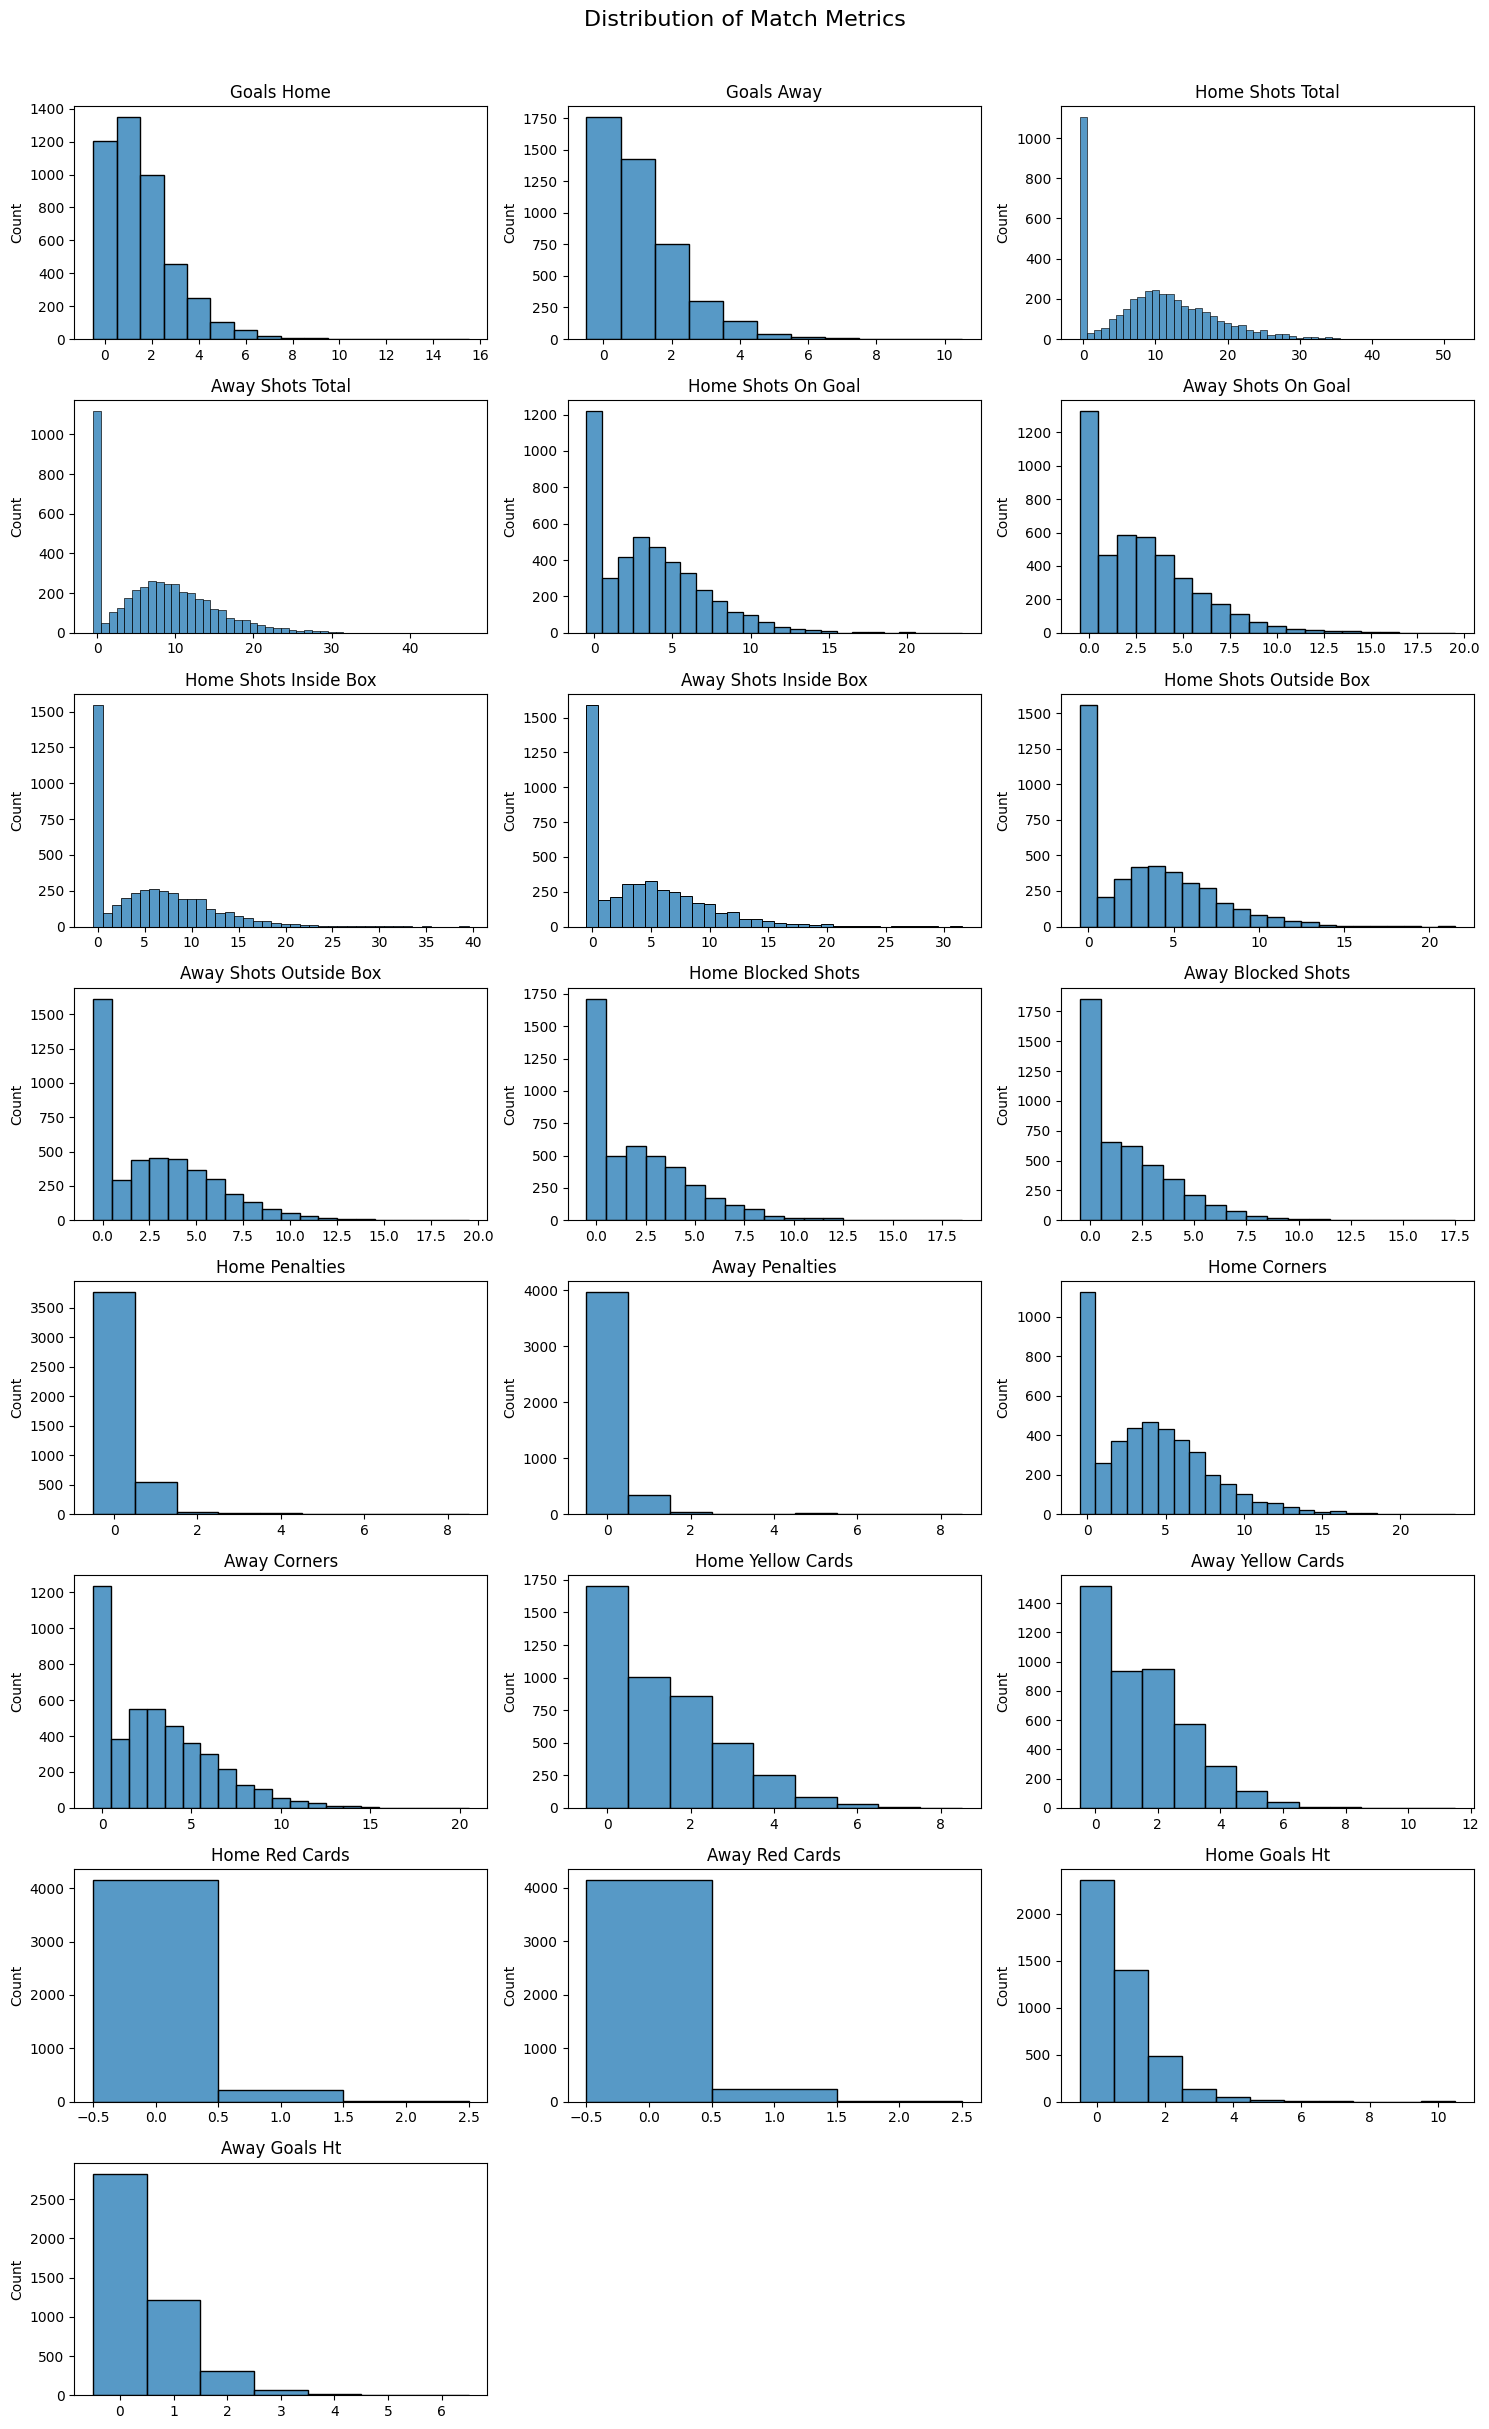

In [5]:
# Current-match variables used here only for data-quality exploration.
# Reuse the same current-match metrics for a like-for-like comparison.
metric_columns = [
    "goals_home", "goals_away",
    "home_shots_total", "away_shots_total",
    "home_shots_on_goal", "away_shots_on_goal",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box",
    "home_blocked_shots", "away_blocked_shots",
    "home_penalties", "away_penalties",
    "home_corners", "away_corners",
    "home_yellow_cards", "away_yellow_cards",
    "home_red_cards", "away_red_cards",
    "home_goals_ht", "away_goals_ht",
]

# Create one small histogram per metric and hide unused subplot positions.
fig, axes = plt.subplots(8, 3, figsize=(15, 24))
axes = axes.flatten()

for ax, metric in zip(axes, metric_columns):
    sns.histplot(data=df, x=metric, ax=ax, discrete=True)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")

for ax in axes[len(metric_columns):]:
    ax.set_visible(False)

fig.suptitle("Distribution of Match Metrics", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 2. Clean Missing Match Statistics

The cleaning strategy keeps every fixture row because its score and chronological position remain useful. Only the affected statistic cells are changed to `NaN`.

Deleting these matches would remove valid results from team histories and distort rolling form. Replacing them immediately with averages would also be unsafe because imputation must be learned from the training period only. The later PCA pipeline therefore performs median imputation after the chronological split.

In [6]:
# Broad provider-failure check: every major shot and corner field is zero.
zero_check_columns = [
    "home_shots_total", "away_shots_total",
    "home_shots_on_goal", "away_shots_on_goal",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box",
    "home_blocked_shots", "away_blocked_shots",
    "home_corners", "away_corners",
]

# create copy of dataframe
model_data = df.copy()
# A row is flagged only when every selected home and away statistic is zero.
all_metrics_zero = model_data[zero_check_columns].eq(0).all(axis=1)
model_data.loc[all_metrics_zero, zero_check_columns] = np.nan

print(f"Rows retained: {len(model_data):,}")
print(f"Rows with shot statistics changed to NaN: {all_metrics_zero.sum():,}")

Rows retained: 4,452
Rows with shot statistics changed to NaN: 1,000


In [7]:
# Identify all-zero shot blocks even when corners are present.
zero_check_columns = [
    "home_shots_total", "away_shots_total",
    "home_shots_on_goal", "away_shots_on_goal",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box",
    "home_blocked_shots", "away_blocked_shots",
]

# Genuine zero values in isolated columns are retained.
all_metrics_zero = model_data[zero_check_columns].eq(0).all(axis=1) #creates a boolean series checking whether each fixture is all zeros or not
model_data.loc[all_metrics_zero, zero_check_columns] = np.nan # for every fixture with all zero match stats, replaces zeros with "nan"

print(f"Rows retained: {len(model_data):,}")
print(f"Rows with shot statistics changed to NaN: {all_metrics_zero.sum():,}")

Rows retained: 4,452
Rows with shot statistics changed to NaN: 81


In [8]:
# Some fixtures contain totals but no inside/outside-box breakdown.
zero_check_columns = [
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box",
]

# Mark only the unavailable location detail as missing in those rows.
all_detailed_metrics_zero = model_data[zero_check_columns].eq(0).all(axis=1)
model_data.loc[all_detailed_metrics_zero, zero_check_columns] = np.nan

print(
    "Rows with detailed shot-location statistics changed to NaN: "
    f"{all_detailed_metrics_zero.sum():,}"
)

Rows with detailed shot-location statistics changed to NaN: 408


### Statistic Distributions Post Cleaning

New histogram plots show that data is no longer dominated by the impossible all-zero records. However genuine low count matches still remain.

Correlation matrix gives an impression of relation between current match statistics. Correlations such as those between "goals_home" and "home_shots_total" are expected. However these statistics are unusable in their current form as they cannot be known before the game has begun. 

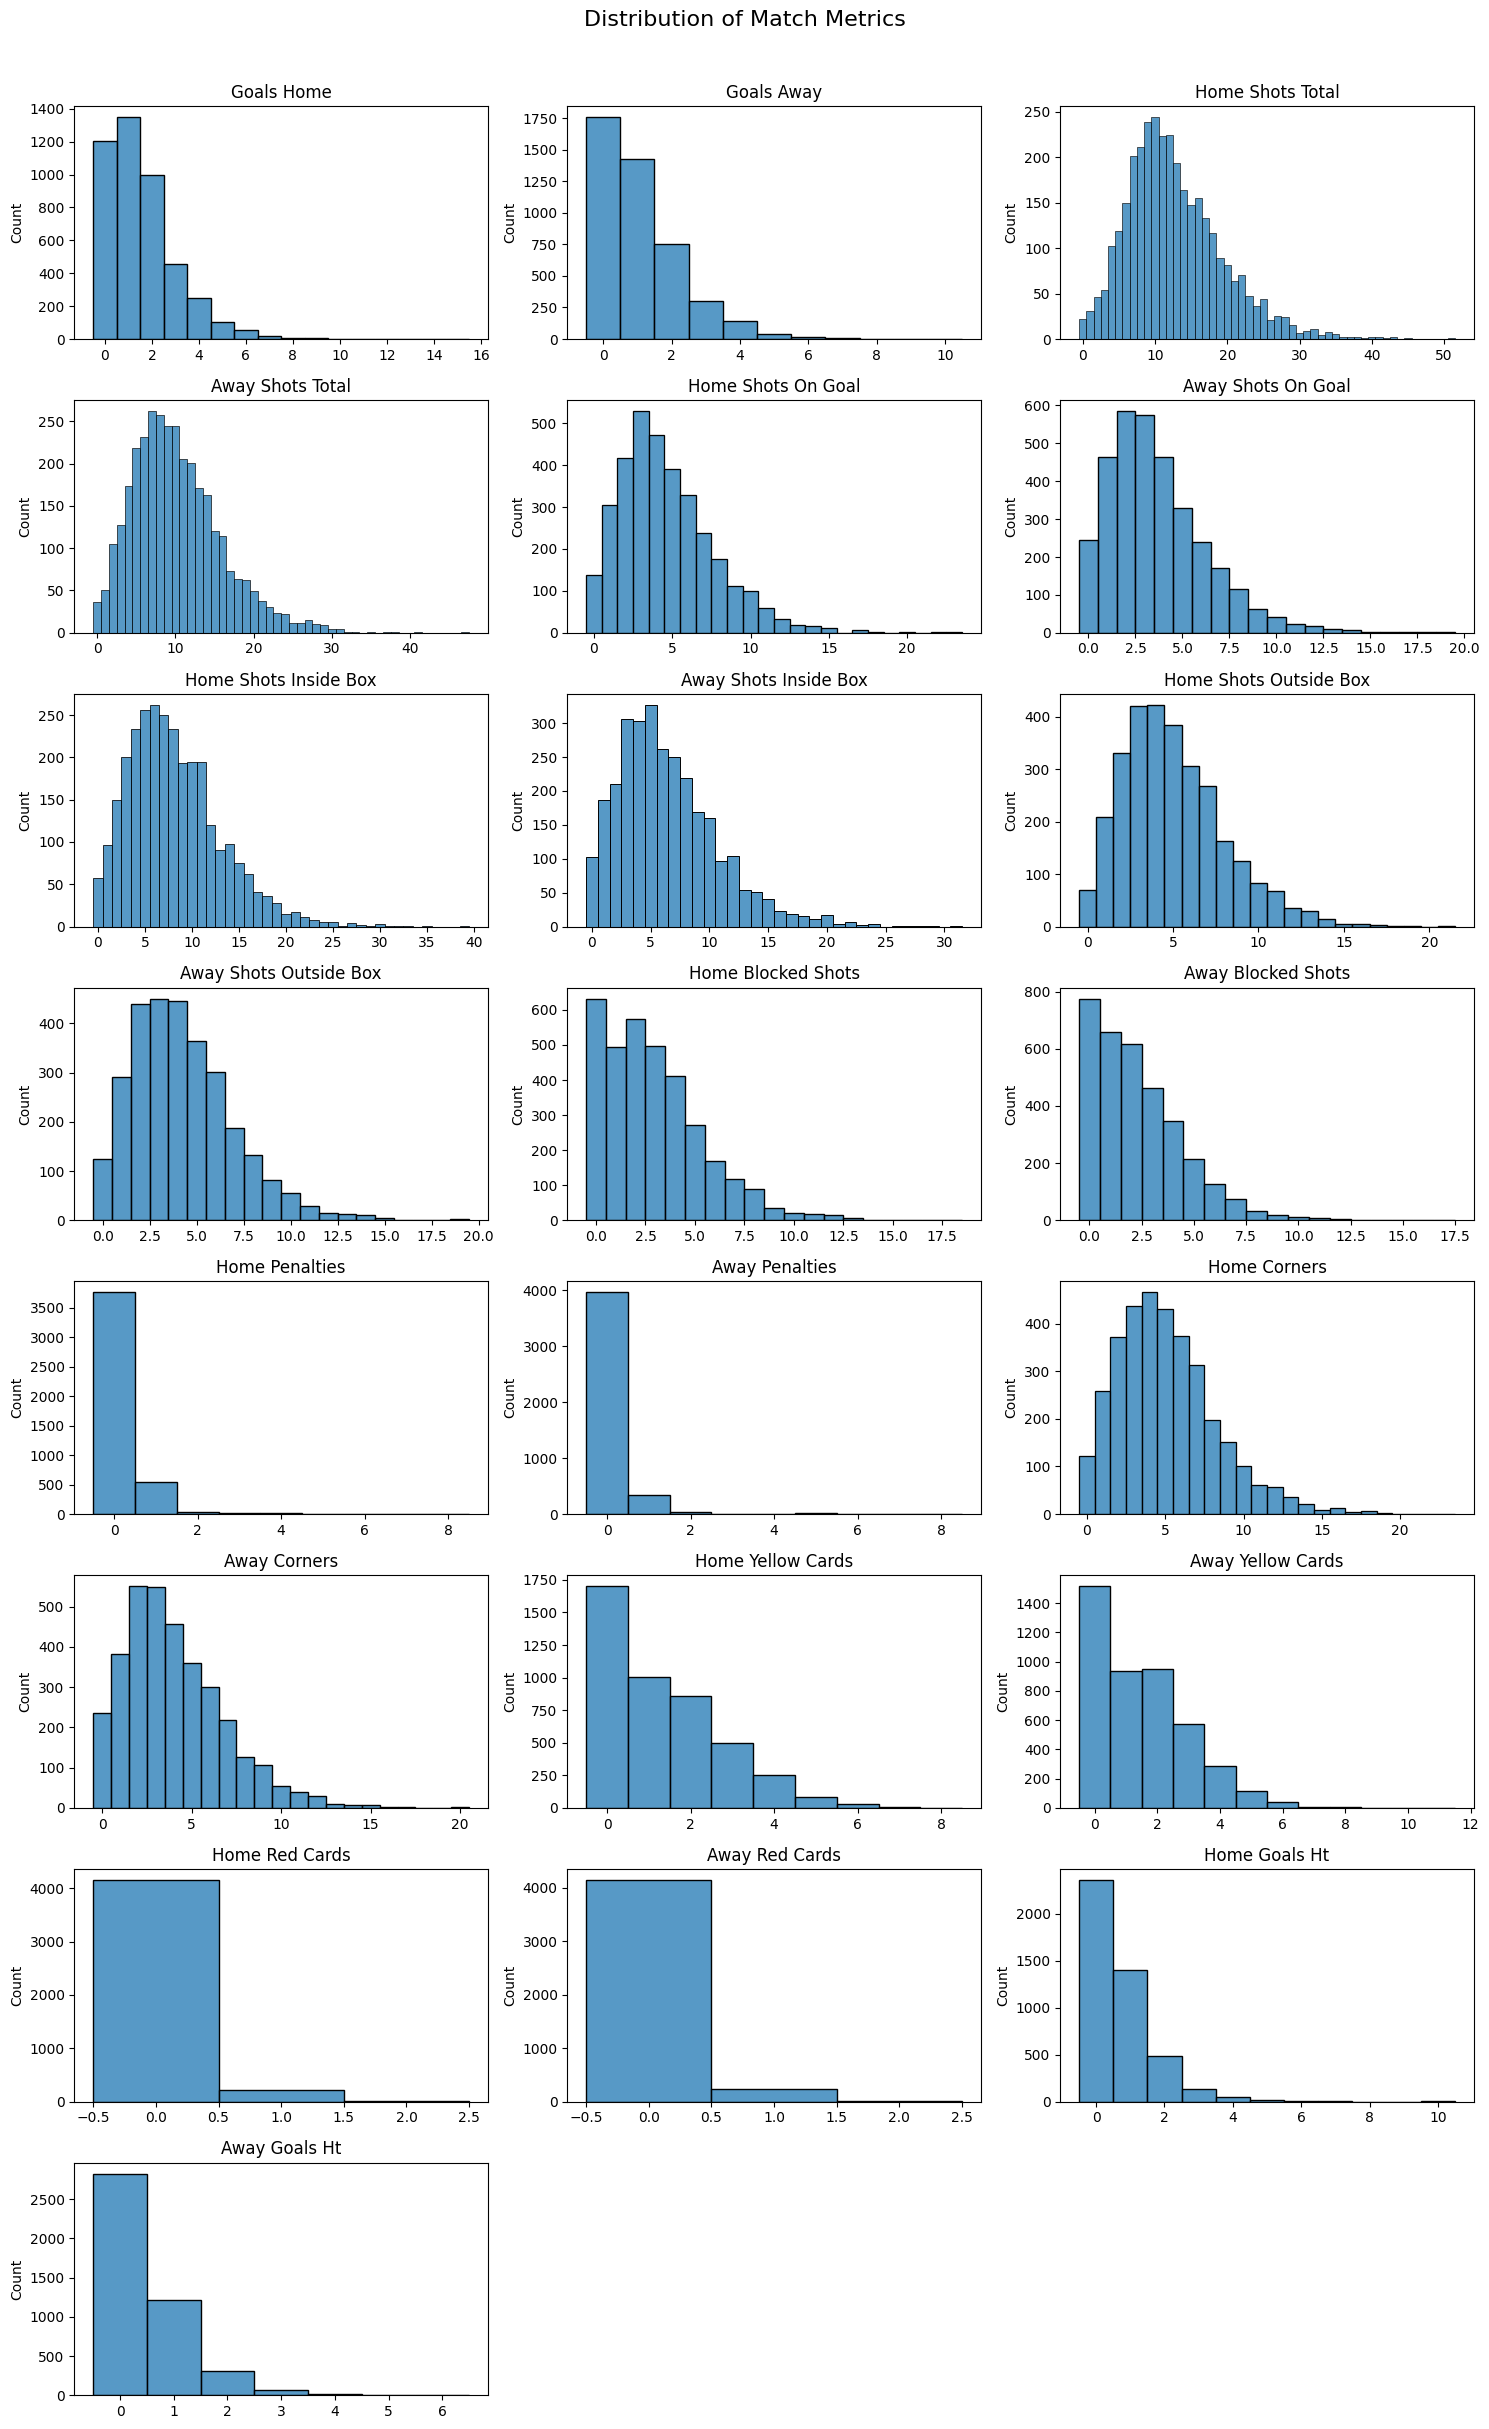

In [9]:
metric_columns = [
    "goals_home", "goals_away",
    "home_shots_total", "away_shots_total",
    "home_shots_on_goal", "away_shots_on_goal",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box",
    "home_blocked_shots", "away_blocked_shots",
    "home_penalties", "away_penalties",
    "home_corners", "away_corners",
    "home_yellow_cards", "away_yellow_cards",
    "home_red_cards", "away_red_cards",
    "home_goals_ht", "away_goals_ht",
]

fig, axes = plt.subplots(8, 3, figsize=(15, 24))
axes = axes.flatten()

for ax, metric in zip(axes, metric_columns):
    # pandas/seaborn automatically omit NaN values from each histogram.
    sns.histplot(data=model_data, x=metric, ax=ax, discrete=True)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")

for ax in axes[len(metric_columns):]:
    ax.set_visible(False)

fig.suptitle("Distribution of Match Metrics", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

<Axes: >

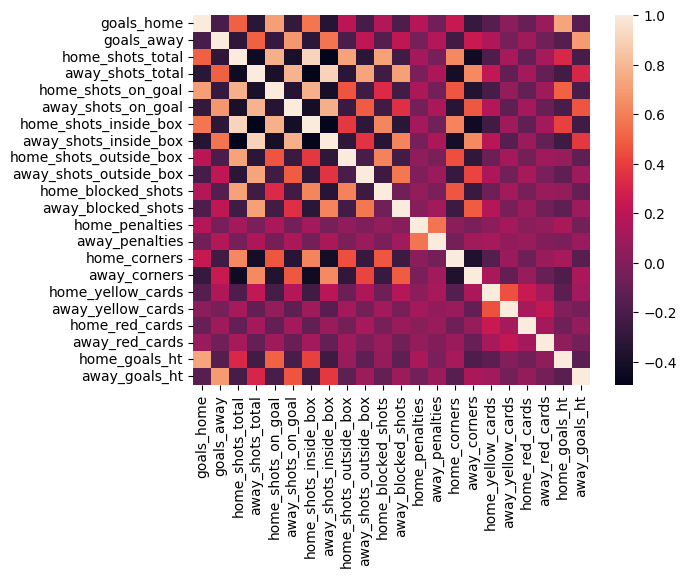

In [10]:
# Pearson correlation measures linear association on the interval [-1, 1].
correlation_matrix = model_data[metric_columns].corr()
correlation_matrix
# The heatmap makes clusters of strongly related match events easier to see.
sns.heatmap(correlation_matrix)

## 3. Creating Leakage-Safe Pre-Match Features

This notebook creates three categories of pre-match statistics that can be used to predict a future match:

1) **Elo Ratings**
These summarise teams relative strengths over time using match results. 
2) **Rolling Statistis**
These summarise the teams performances over the previous 5 fixtures
3) **GAP Ratings**
These maintain a seperate home and away defensive and attacking strenght score based on total shots taken and conceded each match. 

### 3.1 Elo Ratings

Each team begins with a score of 1500. These values changes as matches are played depending both on the results and the difference in strength of the teams that are playing. 

The implementation uses the **Kaggle* dataset "International Football Results from 1876 to 2026" by Mart Jürisoo. 

The implemented Elo model uses the standard expected-score equation, with a
small home-advantage adjustment for non-neutral fixtures:

$$
E_{\text{home}} =
\frac{1}{1 + 10^{\frac{R_{\text{away}} - (R_{\text{home}} + H)}{400}}}
$$

The post-match rating updates are then:

$$
R'_{\text{home}} =
R_{\text{home}} + K(A_{\text{home}} - E_{\text{home}})
$$

$$
R'_{\text{away}} =
R_{\text{away}} - K(A_{\text{home}} - E_{\text{home}})
$$

where:

$$
A_{\text{home}} =
\begin{cases}
1.0, & \text{home win} \\
0.5, & \text{draw} \\
0.0, & \text{home loss}
\end{cases}
$$

The model uses a base update factor of:

$$
K = 50
$$

A 10-point home advantage is added for non-neutral fixtures:

$$
H =
\begin{cases}
10, & \text{non-neutral fixture} \\
0, & \text{neutral fixture}
\end{cases}
$$

For FIFA World Cup matches, the update factor is multiplied by 1.5:

$$
K_{\text{World Cup}} = 50 \times 1.5 = 75
$$

This gives World Cup fixtures greater influence in the rating history, which is
appropriate because the final objective is to predict World Cup fixtures. The
implementation was inspired by the Kaggle notebook **"World Cup 2026 Power
Rankings Analysis"** by Sateasinpedas.

In [11]:
from bisect import bisect_left
from collections import defaultdict
import re
import unicodedata

In [12]:
ELO_K_BASE = 50.0
ELO_WORLD_CUP_MULTIPLIER = 1.5
ELO_HOME_ADVANTAGE = 10.0
ELO_STARTING_RATING = 1500.0

# Fix name differences across datasets.
elo_team_aliases = {
    "frenchguyana": "frenchguiana",
}

# Convert team names to comparable lookup keys across datasets: remove accents,
# punctuation and spacing, lowercase them, then apply known spelling aliases.
def normalize_elo_team_name(team_name):
    normalized = unicodedata.normalize("NFKD", str(team_name))
    normalized = normalized.encode("ascii", "ignore").decode("ascii")
    normalized = re.sub(r"[^a-z0-9]+", "", normalized.casefold())
    return elo_team_aliases.get(normalized, normalized)

# standard Elo expected score equation
def elo_expected_score(rating_a, rating_b):
    return 1.0 / (1.0 + 10.0 ** ((rating_b - rating_a) / 400.0))

# Build the rating history from the long international-results dataset.
results_path = data_path.parent / "1_results.csv" # create path to historical results file
elo_results = pd.read_csv(results_path, low_memory=False) # load csv into dataframe
elo_results["_elo_date"] = pd.to_datetime(
    elo_results["date"], errors="coerce"
).dt.normalize() # convert date column into pandas datetime format
elo_results["_elo_home_team"] = elo_results["home_team"].map(
    normalize_elo_team_name
) # creates cleaned home team name for Elo matching
elo_results["_elo_away_team"] = elo_results["away_team"].map(
    normalize_elo_team_name
) # creates cleaned home team name for Elo matching
elo_results["_elo_home_score"] = pd.to_numeric(
    elo_results["home_score"], errors="coerce"
) # convert home scores to numeric values
elo_results["_elo_away_score"] = pd.to_numeric(
    elo_results["away_score"], errors="coerce"
) # convert away scores to numeric values
elo_results["_elo_neutral"] = (
    elo_results["neutral"].astype(str).str.upper().eq("TRUE")
) # create boolean neutral-venue column

# Removes future scheduled fixtures which have missing scores and cannot update Elo.
elo_results = elo_results.dropna(subset=[
    "_elo_date",
    "_elo_home_score",
    "_elo_away_score",
]).sort_values("_elo_date", kind="mergesort")


elo_ratings = defaultdict(lambda: ELO_STARTING_RATING) # create dictionary of current Elo ratings.
elo_match_counts = defaultdict(int) # tracks number of matches each team has played in Elo system
elo_history = defaultdict(list) # stores each team's rating history over time

# All matches on a date use the ratings available at the start of that date.
# This avoids arbitrary ordering and leakage because 1_results.csv has dates
# but not kickoff times.
for match_date, date_matches in elo_results.groupby("_elo_date", sort=True):
    rating_deltas = defaultdict(float) # temporary dictionary for select date
    match_count_deltas = defaultdict(int) # temporary dictionary for select date

    for _, match in date_matches.iterrows(): # for each specific match
        home_team = match["_elo_home_team"]
        away_team = match["_elo_away_team"]
        home_rating = elo_ratings[home_team] # gets home team Elo rating
        away_rating = elo_ratings[away_team] # gets away team Elo rating
        home_advantage = (
            0.0 if match["_elo_neutral"] else ELO_HOME_ADVANTAGE
        ) # defines home advantage depending on whether match played at a neutral venue

        expected_home = elo_expected_score(
            home_rating + home_advantage, away_rating
        )   # calculates home team's Elo expected result score with home advantage value
            # close to 1   -> home team expected to win
            # around 0.5   -> evenly matched
            # close to 0   -> away team expected to win
        if match["_elo_home_score"] > match["_elo_away_score"]:
            actual_home = 1.0 # home win
        elif match["_elo_home_score"] < match["_elo_away_score"]:
            actual_home = 0.0 # away win
        else:
            actual_home = 0.5 # draw

        # check whether match is a world cup match
        is_world_cup = str(match["tournament"]).casefold() == "fifa world cup"
        k_factor = ELO_K_BASE * (
            ELO_WORLD_CUP_MULTIPLIER if is_world_cup else 1.0
        ) # set strenght of Elo update
        home_delta = k_factor * (actual_home - expected_home)
        rating_deltas[home_team] += home_delta # update home Elo score
        rating_deltas[away_team] -= home_delta # update away Elo score
        match_count_deltas[home_team] += 1 # update home matches played
        match_count_deltas[away_team] += 1 # update away matches played

    for team_name in rating_deltas: # loop through teams that had a rating change that day
        elo_ratings[team_name] += rating_deltas[team_name] # apply total rating change for date
        elo_match_counts[team_name] += match_count_deltas[team_name] # updates team's number of Elo matches
        elo_history[team_name].append((
            match_date,
            elo_ratings[team_name],
            elo_match_counts[team_name],
        )) # store teams rating and Elo matches for that date

# Create a seperate list of dates for each team
elo_history_dates = {
    team_name: [entry[0] for entry in entries]
    for team_name, entries in elo_history.items()
}

# returns a given teams Elo rating prior to a given date
def get_pre_match_elo(team_name, match_date):
    normalized_team = normalize_elo_team_name(team_name) # clean team name
    entries = elo_history.get(normalized_team, []) # get team's Elo history, if none creates empty list
    if not entries or pd.isna(match_date):
        return ELO_STARTING_RATING, 0 # if team has no history or match date is missing, return default Elo

    # Avoid leakage by finding the first position in which match date could be inserted
    history_position = bisect_left(
        elo_history_dates[normalized_team], match_date
    )
    if history_position == 0:
        return ELO_STARTING_RATING, 0 # if no history, return default rating

    _, rating, matches = entries[history_position - 1]
    return rating, matches # else return most recent rating and match count before given date

# convert dates into datetime format
elo_fixture_dates = pd.to_datetime(
    model_data["date"], errors="coerce", utc=True
).dt.tz_localize(None).dt.normalize()

# Retrieve each listed team's state before the fixture date.
home_elo_lookup = [
    get_pre_match_elo(team, match_date)
    for team, match_date in zip(model_data["home_team"], elo_fixture_dates)
] # lookup home team's pre-match Elo for every row
away_elo_lookup = [
    get_pre_match_elo(team, match_date)
    for team, match_date in zip(model_data["away_team"], elo_fixture_dates)
] # lookup away team's pre-match Elo for every row

# split (rating, match_count) tuples into arrays
home_elo = np.array([value[0] for value in home_elo_lookup], dtype=float) 
away_elo = np.array([value[0] for value in away_elo_lookup], dtype=float)
home_elo_matches = np.array([value[1] for value in home_elo_lookup], dtype=int)
away_elo_matches = np.array([value[1] for value in away_elo_lookup], dtype=int)
elo_home_advantage = np.where(
    model_data["matched_neutral"].eq(1), 0.0, ELO_HOME_ADVANTAGE
) # applies home advantage value where necessary
elo_expected_home = elo_expected_score(
    home_elo + elo_home_advantage, away_elo
) # calculate home team's Elo expected result between 0 and 1

# Store raw ratings, venue-adjusted differences, expectations and reliability.
elo_features = pd.DataFrame({
    "home_elo": home_elo,
    "away_elo": away_elo,
    "elo_difference": home_elo - away_elo,
    "elo_adjusted_difference": home_elo + elo_home_advantage - away_elo,
    "elo_expected_home_score": elo_expected_home,
    "elo_expected_away_score": 1.0 - elo_expected_home,
    "home_elo_matches": home_elo_matches,
    "away_elo_matches": away_elo_matches,
}, index=model_data.index)

# Make the cell safe to rerun by replacing any previously generated columns.
existing_elo_columns = [
    column for column in model_data.columns
    if column.startswith(("home_elo", "away_elo", "elo_"))
]
model_data = pd.concat(
    [model_data.drop(columns=existing_elo_columns), elo_features], axis=1
)

elo_display_columns = [
    "fixture_id",
    "date",
    "home_team",
    "away_team",
    *elo_features.columns,
]
model_data[elo_display_columns].head(10)



,fixture_id,date,home_team,away_team,home_elo,away_elo,elo_difference,elo_adjusted_difference,elo_expected_home_score,elo_expected_away_score,home_elo_matches,away_elo_matches
0,350517,2017-03-23 20:30:00+00:00,Colombia,Bolivia,1926.351412,1633.100651,293.250761,303.250761,0.851404,0.148596,531,436
1,350518,2017-03-23 23:00:00+00:00,Paraguay,Ecuador,1748.583414,1868.071335,-119.487920,-109.487920,0.347451,0.652549,694,490
2,350519,2017-03-23 23:00:00+00:00,Uruguay,Brazil,1931.278325,2109.271760,-177.993435,-167.993435,0.275469,0.724531,866,948
3,350520,2017-03-23 23:30:00+00:00,Argentina,Chile,2031.074059,2005.492197,25.581862,35.581862,0.551028,0.448972,956,729
4,350521,2017-03-23 23:30:00+00:00,Venezuela,Peru,1702.889121,1892.601683,-189.712562,-179.712562,0.262211,0.737789,368,606
5,350295,2017-03-24 17:00:00+00:00,Georgia,Serbia,1556.164657,1743.745547,-187.580890,-177.580890,0.264592,0.735408,211,246
6,350296,2017-03-24 17:00:00+00:00,Turkey,Finland,1822.688832,1585.978450,236.710381,246.710381,0.805366,0.194634,536,717
7,350297,2017-03-24 19:45:00+00:00,Austria,Moldova,1726.386462,1399.942454,326.444009,336.444009,0.873992,0.126008,760,203
8,350298,2017-03-24 19:45:00+00:00,Republic of Ireland,Wales,1854.560023,1769.483763,85.076260,95.076260,0.633510,0.366490,538,629
9,350299,2017-03-24 19:45:00+00:00,Italy,Albania,1921.620949,1670.827795,250.793153,260.793153,0.817760,0.182240,785,304


### 3.2 Rolling Statistics

Every fixture is reshaped to contain rolling statistics from recent games, including goals, points, shots, corners, cards, blocked shots, penalties and clean-sheet rates.

Leakage is prevented by grouping history by team and kickoff time. Then a timestamp group receives features before its rows are appended to history. 

In [13]:
# Change this value to compare different history windows.
ROLLING_WINDOW = 5
rolling_prefix = f"rolling_{ROLLING_WINDOW}"

# Build a dated copy of model_data.
rolling_source = model_data.copy()
rolling_source["_match_date"] = pd.to_datetime(
    rolling_source["date"], errors="coerce", utc=True
)

# Express each fixture from the home team's perspective.
home_history = pd.DataFrame({
    "fixture_id": rolling_source["fixture_id"],
    "match_date": rolling_source["_match_date"],
    "team_id": rolling_source["home_team_id"],
    "side": "home",

    "goals_for": rolling_source["goals_home"],
    "goals_against": rolling_source["goals_away"],
    "shots_on_target_for": rolling_source["home_shots_on_goal"],
    "shots_on_target_against": rolling_source["away_shots_on_goal"],

    "corners_for": rolling_source["home_corners"],
    "corners_against": rolling_source["away_corners"],
    "shots_inside_box_for": rolling_source["home_shots_inside_box"],
    "shots_inside_box_against": rolling_source["away_shots_inside_box"],
    "shots_outside_box_for": rolling_source["home_shots_outside_box"],
    "shots_outside_box_against": rolling_source["away_shots_outside_box"],
    "yellow_cards_for": rolling_source["home_yellow_cards"],
    "yellow_cards_against": rolling_source["away_yellow_cards"],
    "red_cards_for": rolling_source["home_red_cards"],
    "red_cards_against": rolling_source["away_red_cards"],
    "blocked_shots_for": rolling_source["home_blocked_shots"],
    "blocked_shots_against": rolling_source["away_blocked_shots"],
    "penalties_for": rolling_source["home_penalties"],
    "penalties_against": rolling_source["away_penalties"],
})

# Express each fixture from the away team's perspective.
away_history = pd.DataFrame({
    "fixture_id": rolling_source["fixture_id"],
    "match_date": rolling_source["_match_date"],
    "team_id": rolling_source["away_team_id"],
    "side": "away",

    "goals_for": rolling_source["goals_away"],
    "goals_against": rolling_source["goals_home"],
    "shots_on_target_for": rolling_source["away_shots_on_goal"],
    "shots_on_target_against": rolling_source["home_shots_on_goal"],

    "corners_for": rolling_source["away_corners"],
    "corners_against": rolling_source["home_corners"],
    "shots_inside_box_for": rolling_source["away_shots_inside_box"],
    "shots_inside_box_against": rolling_source["home_shots_inside_box"],
    "shots_outside_box_for": rolling_source["away_shots_outside_box"],
    "shots_outside_box_against": rolling_source["home_shots_outside_box"],
    "yellow_cards_for": rolling_source["away_yellow_cards"],
    "yellow_cards_against": rolling_source["home_yellow_cards"],
    "red_cards_for": rolling_source["away_red_cards"],
    "red_cards_against": rolling_source["home_red_cards"],
    "blocked_shots_for": rolling_source["away_blocked_shots"],
    "blocked_shots_against": rolling_source["home_blocked_shots"],
    "penalties_for": rolling_source["away_penalties"],
    "penalties_against": rolling_source["home_penalties"],
})

# Stack both perspectives into one chronological history per team.
team_history = pd.concat([home_history, away_history], ignore_index=True)

team_history["points"] = np.select(
    [
        team_history["goals_for"] > team_history["goals_against"],
        team_history["goals_for"] == team_history["goals_against"],
    ],
    [3, 1],
    default=0,
) # assigns football points to each team history

team_history["goal_difference"] = (
    team_history["goals_for"] - team_history["goals_against"]
) # calculates goal difference from that teams perspective
team_history["clean_sheet"] = (
    team_history["goals_against"].eq(0).astype(float)
) # creates a clean-sheet indicator


team_history = team_history.sort_values(
    ["team_id", "match_date", "fixture_id"],
    kind="mergesort",
).reset_index(drop=True) # sort every teams matches chronologically

# Map source statistics to generated rolling feature names.
rolling_inputs = {
    "goals_for": "goals_for",
    "goals_against": "goals_against",
    "points": "points",
    "goal_difference": "goal_difference",
    "shots_on_target_for": "shots_on_target_for",
    "shots_on_target_against": "shots_on_target_against",
    "clean_sheet": "clean_sheet_rate",

    "corners_for": "corners_for",
    "corners_against": "corners_against",
    "shots_inside_box_for": "shots_inside_box_for",
    "shots_inside_box_against": "shots_inside_box_against",
    "shots_outside_box_for": "shots_outside_box_for",
    "shots_outside_box_against": "shots_outside_box_against",
    "yellow_cards_for": "yellow_cards_for",
    "yellow_cards_against": "yellow_cards_against",
    "red_cards_for": "red_cards_for",
    "red_cards_against": "red_cards_against",
    "blocked_shots_for": "blocked_shots_for",
    "blocked_shots_against": "blocked_shots_against",
    "penalties_for": "penalties_for",
    "penalties_against": "penalties_against",
}

# create empty feature columns
for feature_name in rolling_inputs.values():
    team_history[f"{rolling_prefix}_{feature_name}"] = np.nan

# record number of previous matches and non-missing shots on target data
team_history[f"{rolling_prefix}_matches"] = 0
team_history[f"{rolling_prefix}_shots_on_target_matches"] = 0

# Only use matches played before the current kickoff time.
for _, team_matches in team_history.groupby("team_id", sort=False):
    previous_indices = [] # to store rows already played by the team

    # matches played at the same time are processed together
    for _, simultaneous_matches in team_matches.groupby(
        "match_date", sort=False, dropna=False
    ):
        # select the teams previous matches
        previous_matches = previous_indices[-ROLLING_WINDOW:]

        
        if previous_matches:
            previous_values = team_history.loc[previous_matches] # select historical match rows

            # calculate each rolling average
            for source_column, feature_name in rolling_inputs.items():
                team_history.loc[
                    simultaneous_matches.index,
                    f"{rolling_prefix}_{feature_name}",
                ] = previous_values[source_column].mean()

            # record window size (how many previous matches were available)
            team_history.loc[
                simultaneous_matches.index,
                f"{rolling_prefix}_matches",
            ] = len(previous_matches)

            # record shots-on-target data coverage
            team_history.loc[
                simultaneous_matches.index,
                f"{rolling_prefix}_shots_on_target_matches",
            ] = previous_values["shots_on_target_for"].notna().sum()

        # add the current match to history
        previous_indices.extend(simultaneous_matches.index.tolist())

# Collect rolling feature names
rolling_feature_columns = [
    f"{rolling_prefix}_{feature_name}"
    for feature_name in rolling_inputs.values()
] + [
    f"{rolling_prefix}_matches",
    f"{rolling_prefix}_shots_on_target_matches",
]

# Search for existing rolling columns.
existing_rolling_columns = [
    column
    for column in model_data.columns
    if column.startswith(("home_rolling_", "away_rolling_"))
]

# Remove previously generated home and away rolling columns
model_data = model_data.drop(
    columns=existing_rolling_columns,
    errors="ignore",
)
model_data["_original_order"] = np.arange(len(model_data))


# Merge the rolling values back onto each fixture.
for side in ("home", "away"): # process home and away teams seperately
    side_features = team_history.loc[
        team_history["side"].eq(side),
        ["fixture_id", *rolling_feature_columns],
    ].rename( # rename columns by fixture side (home/away)
        columns={
            column: f"{side}_{column}"
            for column in rolling_feature_columns
        }
    )
    # merge features into each fixture
    model_data = model_data.merge(
        side_features,
        on="fixture_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )

model_data = (
    model_data
    .sort_values("_original_order") #  restore original order
    .drop(columns="_original_order") # remove temporary helped
    .reset_index(drop=True) # replace possibly changed index with a clean sequential index
)

# Display the generated rolling features.
display_rolling_features = list(rolling_inputs.values())

display_columns = [
    "fixture_id",
    "home_team",
    "away_team",
] + [
    f"{side}_{rolling_prefix}_{feature}"
    for side in ("home", "away")
    for feature in display_rolling_features
]

model_data[display_columns].tail(10)


,fixture_id,home_team,away_team,home_rolling_5_goals_for,home_rolling_5_goals_against,home_rolling_5_points,home_rolling_5_goal_difference,home_rolling_5_shots_on_target_for,home_rolling_5_shots_on_target_against,home_rolling_5_clean_sheet_rate,...,away_rolling_5_shots_outside_box_for,away_rolling_5_shots_outside_box_against,away_rolling_5_yellow_cards_for,away_rolling_5_yellow_cards_against,away_rolling_5_red_cards_for,away_rolling_5_red_cards_against,away_rolling_5_blocked_shots_for,away_rolling_5_blocked_shots_against,away_rolling_5_penalties_for,away_rolling_5_penalties_against
4442,380471,Canada,Republic of Ireland,1.4,0.4,2.2,1.0,5.333333,2.666667,0.8,...,2.400000,5.80,3.250000,1.250000,0.25,0.750000,3.0,5.400000,0.333333,0.0
4443,379956,Belgium,Tunisia,3.2,0.8,2.2,2.4,7.400000,2.600000,0.4,...,5.333333,3.00,2.666667,3.000000,0.00,0.666667,2.0,0.666667,0.500000,0.5
4444,380472,Portugal,Chile,2.6,1.0,1.6,1.6,6.400000,3.000000,0.4,...,4.800000,4.00,1.800000,1.400000,0.20,0.000000,1.8,3.400000,0.000000,0.2
4445,379957,United States,Germany,2.4,2.2,1.8,0.2,4.000000,4.000000,0.0,...,4.000000,4.00,1.666667,2.333333,0.00,0.000000,4.4,2.800000,0.000000,0.0
4446,380397,England,New Zealand,2.0,0.4,2.0,1.6,5.800000,1.600000,0.6,...,3.800000,8.20,1.600000,0.800000,0.00,0.000000,2.8,7.000000,0.000000,0.0
4447,380473,Brazil,Egypt,2.6,1.2,2.0,1.4,6.250000,3.750000,0.2,...,3.000000,5.40,2.000000,1.000000,0.25,0.000000,1.8,5.000000,0.000000,0.0
4448,633560,Curaçao,Aruba,2.2,1.0,1.6,1.2,5.400000,5.400000,0.6,...,4.000000,6.75,1.800000,0.800000,0.00,0.400000,1.0,4.400000,0.200000,0.2
4449,379958,Croatia,Slovenia,1.8,1.8,1.8,0.0,3.250000,3.500000,0.0,...,2.800000,3.40,1.800000,1.000000,0.20,0.000000,4.6,3.400000,0.000000,0.0
4450,634481,Morocco,Norway,1.6,0.4,2.2,1.2,3.600000,3.400000,0.6,...,2.800000,3.60,0.750000,1.000000,0.00,0.000000,3.2,3.400000,0.000000,0.0
4451,634482,Ecuador,Guatemala,1.0,0.6,1.4,0.4,3.600000,2.200000,0.4,...,6.750000,4.00,1.250000,1.500000,0.00,0.000000,4.0,1.750000,0.000000,0.0


### 3.3 GAP Ratings

Each team has a home and way defense and attack rating which is updated after each game. Before a game a relevant attack and defence scores are avaeraged to predict each side's total shots. 

This idea was taken from Edward Wheatcroft and Ewelina Sienkiewicz's paper, "A Probabilistic Model for Predicting Shot
Success in Football". In this paper there is no given way of defining the effect of neutral fixtures, so for these cases we average the home and away components and update both equally.

In [15]:
from collections import defaultdict

# parameters
GAP_LAMBDA = 0.437
GAP_PHI_HOME = 0.496
GAP_PHI_AWAY = 0.566
GAP_INITIAL_RATING = 10.0
GAP_BURN_IN_MATCHES = 6 # break in time for GAP to work

# Every team maintains home and away attack and defence states.
gap_rating_keys = (
    "home_attack",
    "away_attack",
    "home_defence",
    "away_defence",
)

# creates the initial GAP state for a new team
def new_gap_state():
    return {
        **{key: GAP_INITIAL_RATING for key in gap_rating_keys},
        "matches": 0,
    }

# Sort a working copy chronologically while retaining original row indices.
gap_source = model_data.copy() 
gap_source["_gap_match_date"] = pd.to_datetime(
    gap_source["date"], errors="coerce", utc=True
)
gap_source["_gap_original_order"] = np.arange(len(gap_source))
gap_source = gap_source.sort_values(
    ["_gap_match_date", "fixture_id", "_gap_original_order"],
    kind="mergesort",
)

# Features saved before the current fixture updates either team's state.
gap_feature_columns = [
    "home_gap_attack",
    "home_gap_defence",
    "away_gap_attack",
    "away_gap_defence",
    "gap_predicted_home_shots",
    "gap_predicted_away_shots",
    "home_gap_matches",
    "away_gap_matches",
    "gap_ratings_ready",
]
gap_features = pd.DataFrame(index=model_data.index, columns=gap_feature_columns)
gap_states = {}


# Fixtures at the same kickoff time use the same pre-match state. Their
# updates are applied together so one cannot leak into another.
for _, kickoff_matches in gap_source.groupby(
    "_gap_match_date", sort=True, dropna=False
):
    rating_deltas = defaultdict(lambda: defaultdict(float)) # temporary update storage
    match_count_deltas = defaultdict(int) # temporary update storage

    for row_index, match in kickoff_matches.iterrows(): # process every fixture in the batch
        home_team_id = match["home_team_id"]
        away_team_id = match["away_team_id"]
        home_state = gap_states.setdefault(home_team_id, new_gap_state())
        away_state = gap_states.setdefault(away_team_id, new_gap_state())
        is_neutral = bool(match.get("matched_neutral", 0))

        if is_neutral: # for a neutral match average the venue
            # components and update both equally for international fixtures.
            home_attack = (
                home_state["home_attack"] + home_state["away_attack"]
            ) / 2
            home_defence = (
                home_state["home_defence"] + home_state["away_defence"]
            ) / 2
            away_attack = (
                away_state["home_attack"] + away_state["away_attack"]
            ) / 2
            away_defence = (
                away_state["home_defence"] + away_state["away_defence"]
            ) / 2
        else: # if not a neutral match
            home_attack = home_state["home_attack"]
            home_defence = home_state["home_defence"]
            away_attack = away_state["away_attack"]
            away_defence = away_state["away_defence"]

        # Combine one team's attack with its opponent's defence to predict shots
        predicted_home_shots = (home_attack + away_defence) / 2
        predicted_away_shots = (away_attack + home_defence) / 2

        # save the pre-match features
        gap_features.loc[row_index, [
            "home_gap_attack",
            "home_gap_defence",
            "away_gap_attack",
            "away_gap_defence",
            "gap_predicted_home_shots",
            "gap_predicted_away_shots",
            "home_gap_matches",
            "away_gap_matches",
            "gap_ratings_ready",
        ]] = [
            home_attack,
            home_defence,
            away_attack,
            away_defence,
            predicted_home_shots,
            predicted_away_shots,
            home_state["matches"],
            away_state["matches"],
            int(
                home_state["matches"] >= GAP_BURN_IN_MATCHES
                and away_state["matches"] >= GAP_BURN_IN_MATCHES
            ), # readiness indicator (both teams have played at least 6 matches)
        ]

        # Missing total shots leave the state unchanged but retain the row.
        home_shots = pd.to_numeric(match["home_shots_total"], errors="coerce")
        away_shots = pd.to_numeric(match["away_shots_total"], errors="coerce")
        if pd.isna(home_shots) or pd.isna(away_shots):
            continue

        # Positive errors strengthen attack or weaken the opponent's defence.
        home_error = home_shots - predicted_home_shots # positive if home attack performed better, away defense performed worse than expected
        away_error = away_shots - predicted_away_shots

        if is_neutral: # if match is neutral, GAP score updates
            neutral_weight = 0.5 
            for key in ("home_attack", "away_attack"):
                rating_deltas[home_team_id][key] += (
                    GAP_LAMBDA * neutral_weight * home_error
                )
                rating_deltas[away_team_id][key] += (
                    GAP_LAMBDA * neutral_weight * away_error
                )
            for key in ("home_defence", "away_defence"):
                rating_deltas[home_team_id][key] += (
                    GAP_LAMBDA * neutral_weight * away_error
                )
                rating_deltas[away_team_id][key] += (
                    GAP_LAMBDA * neutral_weight * home_error
                )
        else: # if match is not neutral, GAP score updates
            # Update the home team's four ratings.
            rating_deltas[home_team_id]["home_attack"] += (
                GAP_LAMBDA * GAP_PHI_HOME * home_error
            )
            rating_deltas[home_team_id]["away_attack"] += (
                GAP_LAMBDA * (1 - GAP_PHI_HOME) * home_error
            )
            rating_deltas[home_team_id]["home_defence"] += (
                GAP_LAMBDA * GAP_PHI_HOME * away_error
            )
            rating_deltas[home_team_id]["away_defence"] += (
                GAP_LAMBDA * (1 - GAP_PHI_HOME) * away_error
            )

            # Update the away team's four ratings.
            rating_deltas[away_team_id]["away_attack"] += (
                GAP_LAMBDA * GAP_PHI_AWAY * away_error
            )
            rating_deltas[away_team_id]["home_attack"] += (
                GAP_LAMBDA * (1 - GAP_PHI_AWAY) * away_error
            )
            rating_deltas[away_team_id]["away_defence"] += (
                GAP_LAMBDA * GAP_PHI_AWAY * home_error
            )
            rating_deltas[away_team_id]["home_defence"] += (
                GAP_LAMBDA * (1 - GAP_PHI_AWAY) * home_error
            )

        match_count_deltas[home_team_id] += 1
        match_count_deltas[away_team_id] += 1

    # Apply all same-kickoff updates only after their features are recorded.
    for team_id, deltas in rating_deltas.items():
        state = gap_states[team_id]
        for rating_key in gap_rating_keys:
            state[rating_key] = max(
                state[rating_key] + deltas[rating_key], 0.0
            )
        state["matches"] += match_count_deltas[team_id]

# Enforce stable numeric dtypes before joining the features to model_data.
gap_features = gap_features.astype({
    "home_gap_attack": "float64",
    "home_gap_defence": "float64",
    "away_gap_attack": "float64",
    "away_gap_defence": "float64",
    "gap_predicted_home_shots": "float64",
    "gap_predicted_away_shots": "float64",
    "home_gap_matches": "int64",
    "away_gap_matches": "int64",
    "gap_ratings_ready": "int8",
})

# Replace prior GAP columns if this cell is rerun.
existing_gap_columns = [
    column for column in model_data.columns
    if column.startswith(("home_gap_", "away_gap_", "gap_"))
]
model_data = pd.concat(
    [model_data.drop(columns=existing_gap_columns), gap_features], axis=1
)

gap_display_columns = [
    "fixture_id",
    "date",
    "home_team",
    "away_team",
    *gap_feature_columns,
]
model_data[gap_display_columns].head(100)

,fixture_id,date,home_team,away_team,home_gap_attack,home_gap_defence,away_gap_attack,away_gap_defence,gap_predicted_home_shots,gap_predicted_away_shots,home_gap_matches,away_gap_matches,gap_ratings_ready
0,350517,2017-03-23 20:30:00+00:00,Colombia,Bolivia,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0,0,0
1,350518,2017-03-23 23:00:00+00:00,Paraguay,Ecuador,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0,0,0
2,350519,2017-03-23 23:00:00+00:00,Uruguay,Brazil,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0,0,0
3,350520,2017-03-23 23:30:00+00:00,Argentina,Chile,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0,0,0
4,350521,2017-03-23 23:30:00+00:00,Venezuela,Peru,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,350363,2017-09-01 18:45:00+00:00,Romania,Armenia,9.674000,9.686416,10.903582,10.270221,9.972110,10.294999,2,2,0
96,350364,2017-09-01 18:45:00+00:00,Lithuania,Scotland,9.464226,10.682378,10.514800,9.629188,9.546707,10.598589,2,2,0
97,350365,2017-09-01 18:45:00+00:00,Malta,England,7.033525,12.217702,12.663548,8.047024,7.540275,12.440625,2,2,0
98,350366,2017-09-01 18:45:00+00:00,Slovakia,Slovenia,9.388011,9.175589,11.100084,9.558125,9.473068,10.137837,2,2,0


### Missing Data

In [16]:
# Count and percentage make missingness comparable across all columns.
nan_summary = pd.DataFrame({
    "nan_count": model_data.isna().sum(),
    "nan_percentage": model_data.isna().mean().mul(100).round(2),
# Highest-missing columns appear first for easier diagnosis.
}).sort_values(["nan_count", "nan_percentage"], ascending=False)

nan_summary.head(50)

,nan_count,nan_percentage
home_shots_inside_box,1504,33.78
away_shots_inside_box,1504,33.78
home_shots_outside_box,1504,33.78
away_shots_outside_box,1504,33.78
home_shots_total,1096,24.62
away_shots_total,1096,24.62
home_shots_on_goal,1096,24.62
away_shots_on_goal,1096,24.62
home_blocked_shots,1096,24.62
away_blocked_shots,1096,24.62


Missing historical features are retained for
modelling. They are handled after the chronological split by training-fitted
imputation, explicit missing-history indicators and reliability counts. This
avoids selecting only fixtures with unusually complete provider coverage.


# 4. Explore completed data

Histogram plots and correlation matrices to results and goals. 

Only considers the relevant features. In other words doesn't consider stats that we cannot know before the game. 


In [17]:
# Select numeric analysis columns while excluding identifiers.
# Numeric IDs would create meaningless distances and correlations.
identifier_columns = {
    "fixture_id",
    "api_football_id",
    "Competition_id",
    "home_team_id",
    "away_team_id",
    "home_coach_api_id",
    "away_coach_api_id",
}

# Keep genuine numeric measurements, flags, outcomes and engineered features.
model_numeric_columns = [
    column
    for column in model_data.select_dtypes(include=np.number).columns
    if column not in identifier_columns
]

print(f"Numeric model columns plotted: {len(model_numeric_columns)}")
model_numeric_columns

Numeric model columns plotted: 87


['goals_home',
 'goals_away',
 'home_shots_total',
 'away_shots_total',
 'home_shots_on_goal',
 'away_shots_on_goal',
 'home_shots_inside_box',
 'away_shots_inside_box',
 'home_shots_outside_box',
 'away_shots_outside_box',
 'home_blocked_shots',
 'away_blocked_shots',
 'home_penalties',
 'away_penalties',
 'home_corners',
 'away_corners',
 'home_yellow_cards',
 'away_yellow_cards',
 'home_red_cards',
 'away_red_cards',
 'home_goals_ht',
 'away_goals_ht',
 'matched_neutral',
 'competitive',
 'home_elo',
 'away_elo',
 'elo_difference',
 'elo_adjusted_difference',
 'elo_expected_home_score',
 'elo_expected_away_score',
 'home_elo_matches',
 'away_elo_matches',
 'home_rolling_5_goals_for',
 'home_rolling_5_goals_against',
 'home_rolling_5_points',
 'home_rolling_5_goal_difference',
 'home_rolling_5_shots_on_target_for',
 'home_rolling_5_shots_on_target_against',
 'home_rolling_5_clean_sheet_rate',
 'home_rolling_5_corners_for',
 'home_rolling_5_corners_against',
 'home_rolling_5_shots_ins

In [26]:
# ============================================================
# LEAKAGE-SAFE FEATURE SELECTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Only numeric information available before kickoff.
pre_match_exact_columns = {
    "matched_neutral",
    "competitive",
}

pre_match_prefixes = (
    "home_elo",
    "away_elo",
    "elo_",
    "home_rolling_",
    "away_rolling_",
    "home_gap_",
    "away_gap_",
    "gap_",
)

numeric_columns = model_data.select_dtypes(
    include=np.number
).columns

pre_match_feature_columns = [
    column
    for column in numeric_columns
    if (
        column in pre_match_exact_columns
        or column.startswith(pre_match_prefixes)
    )
]

# Ensure no post-match information has entered the predictor set.
post_match_columns = {
    "goals_home", "goals_away",
    "home_goals_ht", "away_goals_ht",
    "home_shots_total", "away_shots_total",
    "home_shots_on_goal", "away_shots_on_goal",
    "home_shots_inside_box", "away_shots_inside_box",
    "home_shots_outside_box", "away_shots_outside_box",
    "home_blocked_shots", "away_blocked_shots",
    "home_penalties", "away_penalties",
    "home_corners", "away_corners",
    "home_yellow_cards", "away_yellow_cards",
    "home_red_cards", "away_red_cards",
}

leaking_features = sorted(
    set(pre_match_feature_columns) & post_match_columns
)

if leaking_features:
    raise ValueError(
        f"Post-match columns entered the predictor set: "
        f"{leaking_features}"
    )

if not pre_match_feature_columns:
    raise ValueError(
        "No leakage-safe pre-match features were selected."
    )

print(
    f"Leakage-safe features selected: "
    f"{len(pre_match_feature_columns)}"
)

pre_match_feature_columns

Leakage-safe features selected: 65


['matched_neutral',
 'competitive',
 'home_elo',
 'away_elo',
 'elo_difference',
 'elo_adjusted_difference',
 'elo_expected_home_score',
 'elo_expected_away_score',
 'home_elo_matches',
 'away_elo_matches',
 'home_rolling_5_goals_for',
 'home_rolling_5_goals_against',
 'home_rolling_5_points',
 'home_rolling_5_goal_difference',
 'home_rolling_5_shots_on_target_for',
 'home_rolling_5_shots_on_target_against',
 'home_rolling_5_clean_sheet_rate',
 'home_rolling_5_corners_for',
 'home_rolling_5_corners_against',
 'home_rolling_5_shots_inside_box_for',
 'home_rolling_5_shots_inside_box_against',
 'home_rolling_5_shots_outside_box_for',
 'home_rolling_5_shots_outside_box_against',
 'home_rolling_5_yellow_cards_for',
 'home_rolling_5_yellow_cards_against',
 'home_rolling_5_red_cards_for',
 'home_rolling_5_red_cards_against',
 'home_rolling_5_blocked_shots_for',
 'home_rolling_5_blocked_shots_against',
 'home_rolling_5_penalties_for',
 'home_rolling_5_penalties_against',
 'home_rolling_5_match

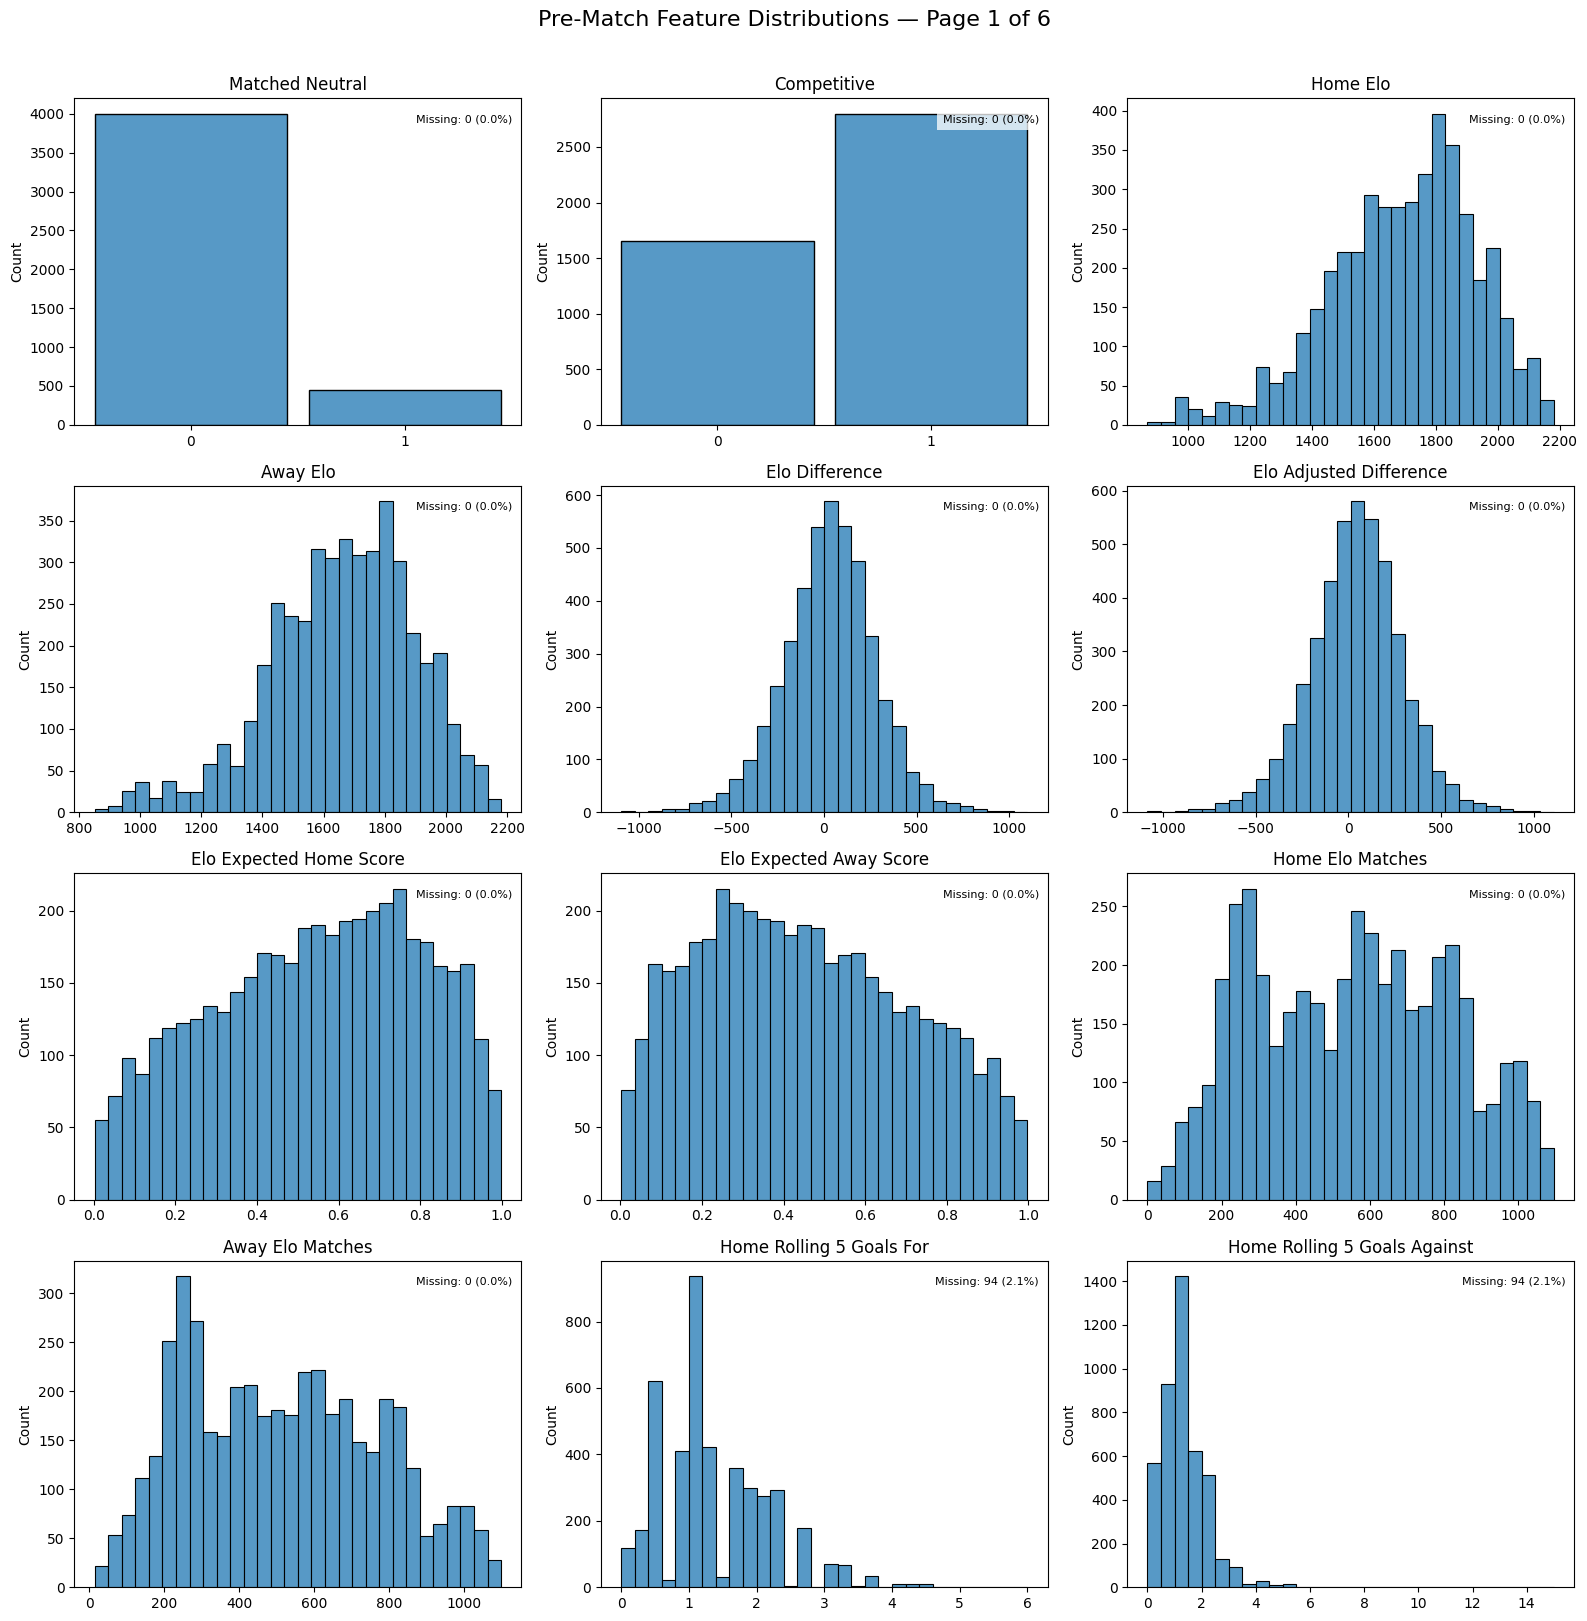

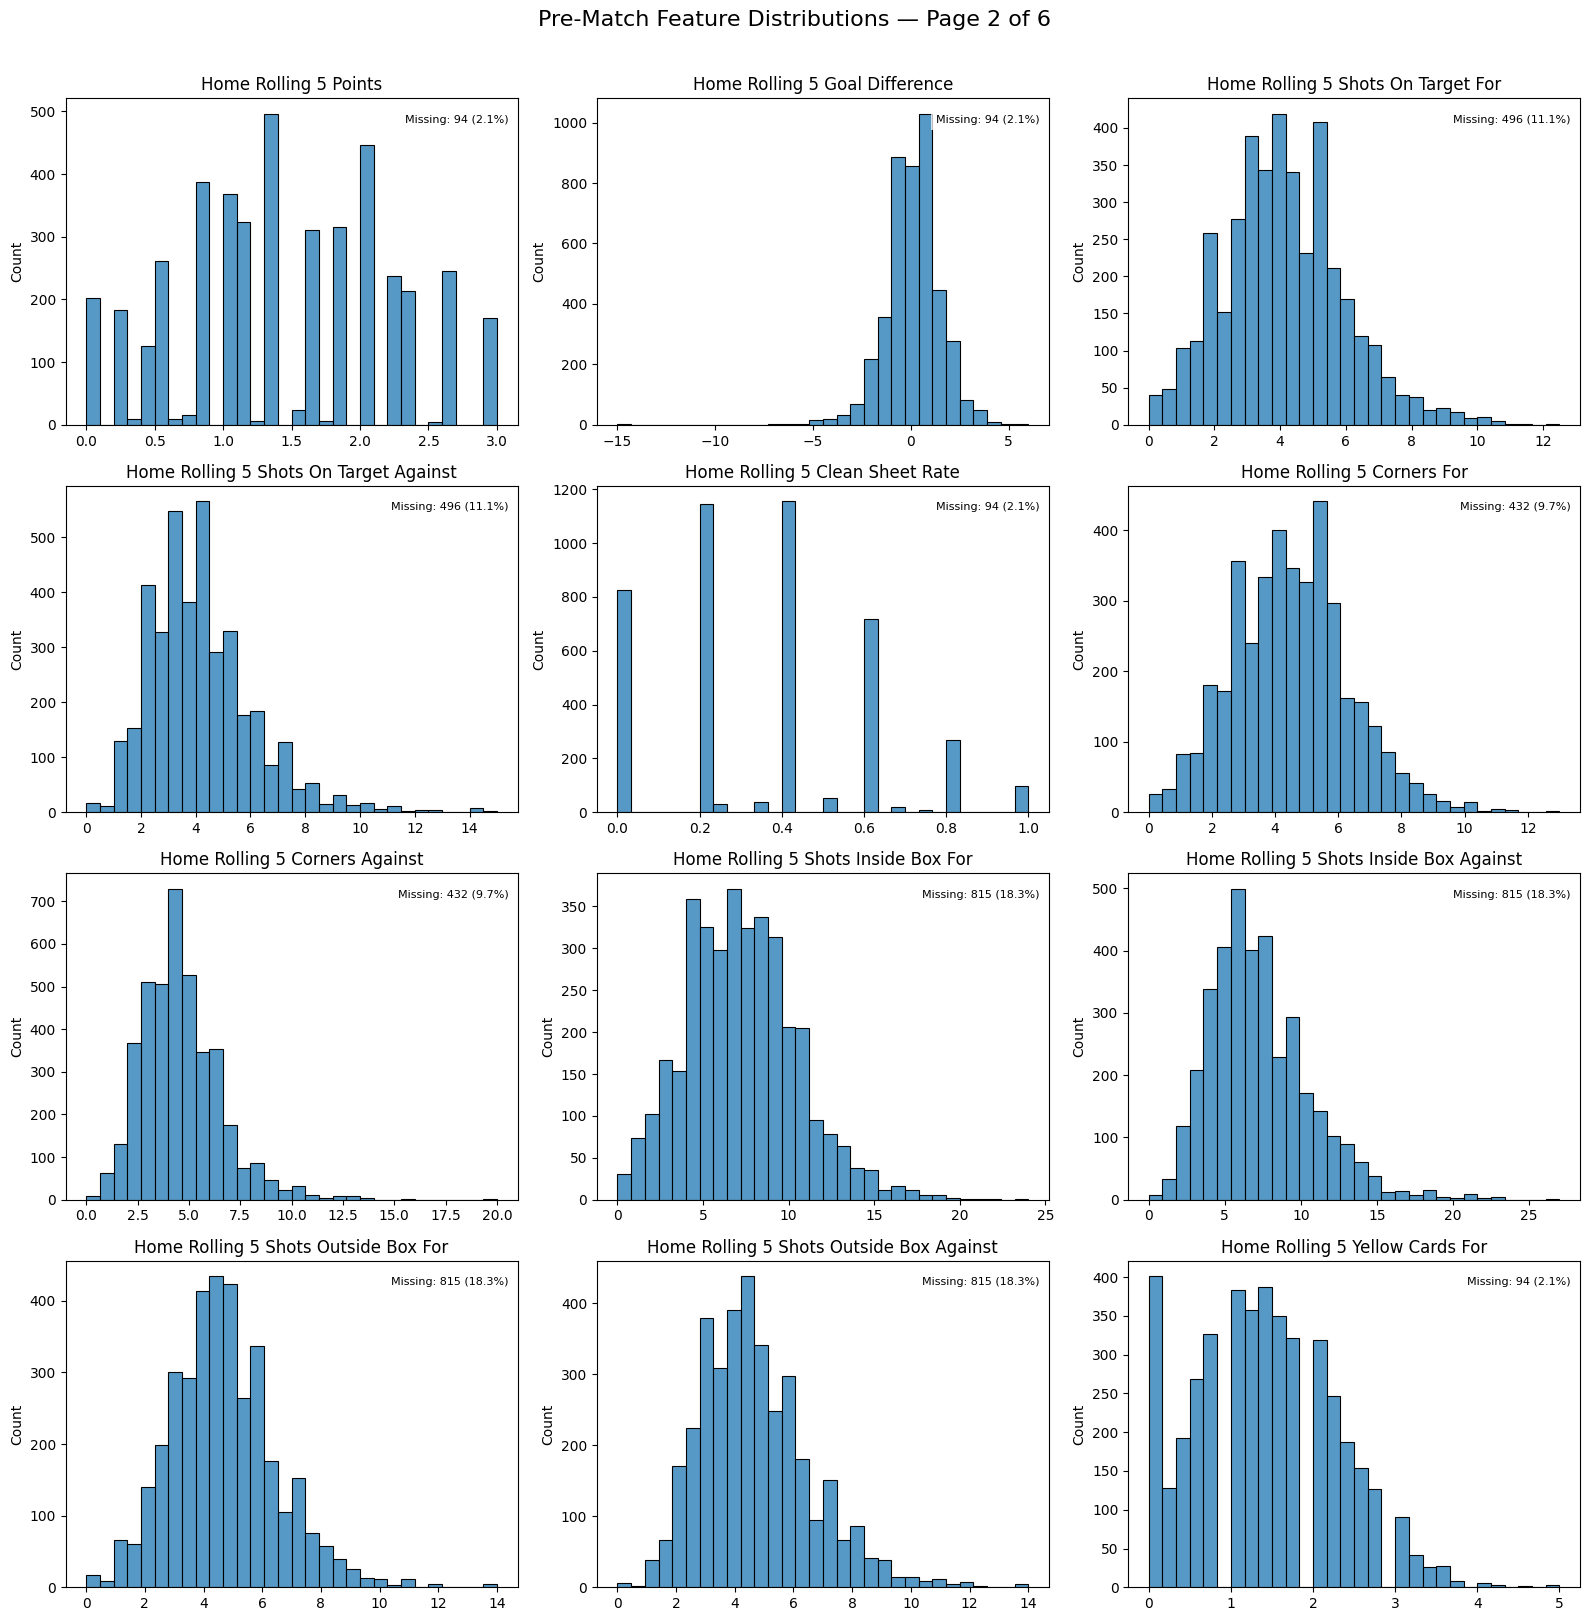

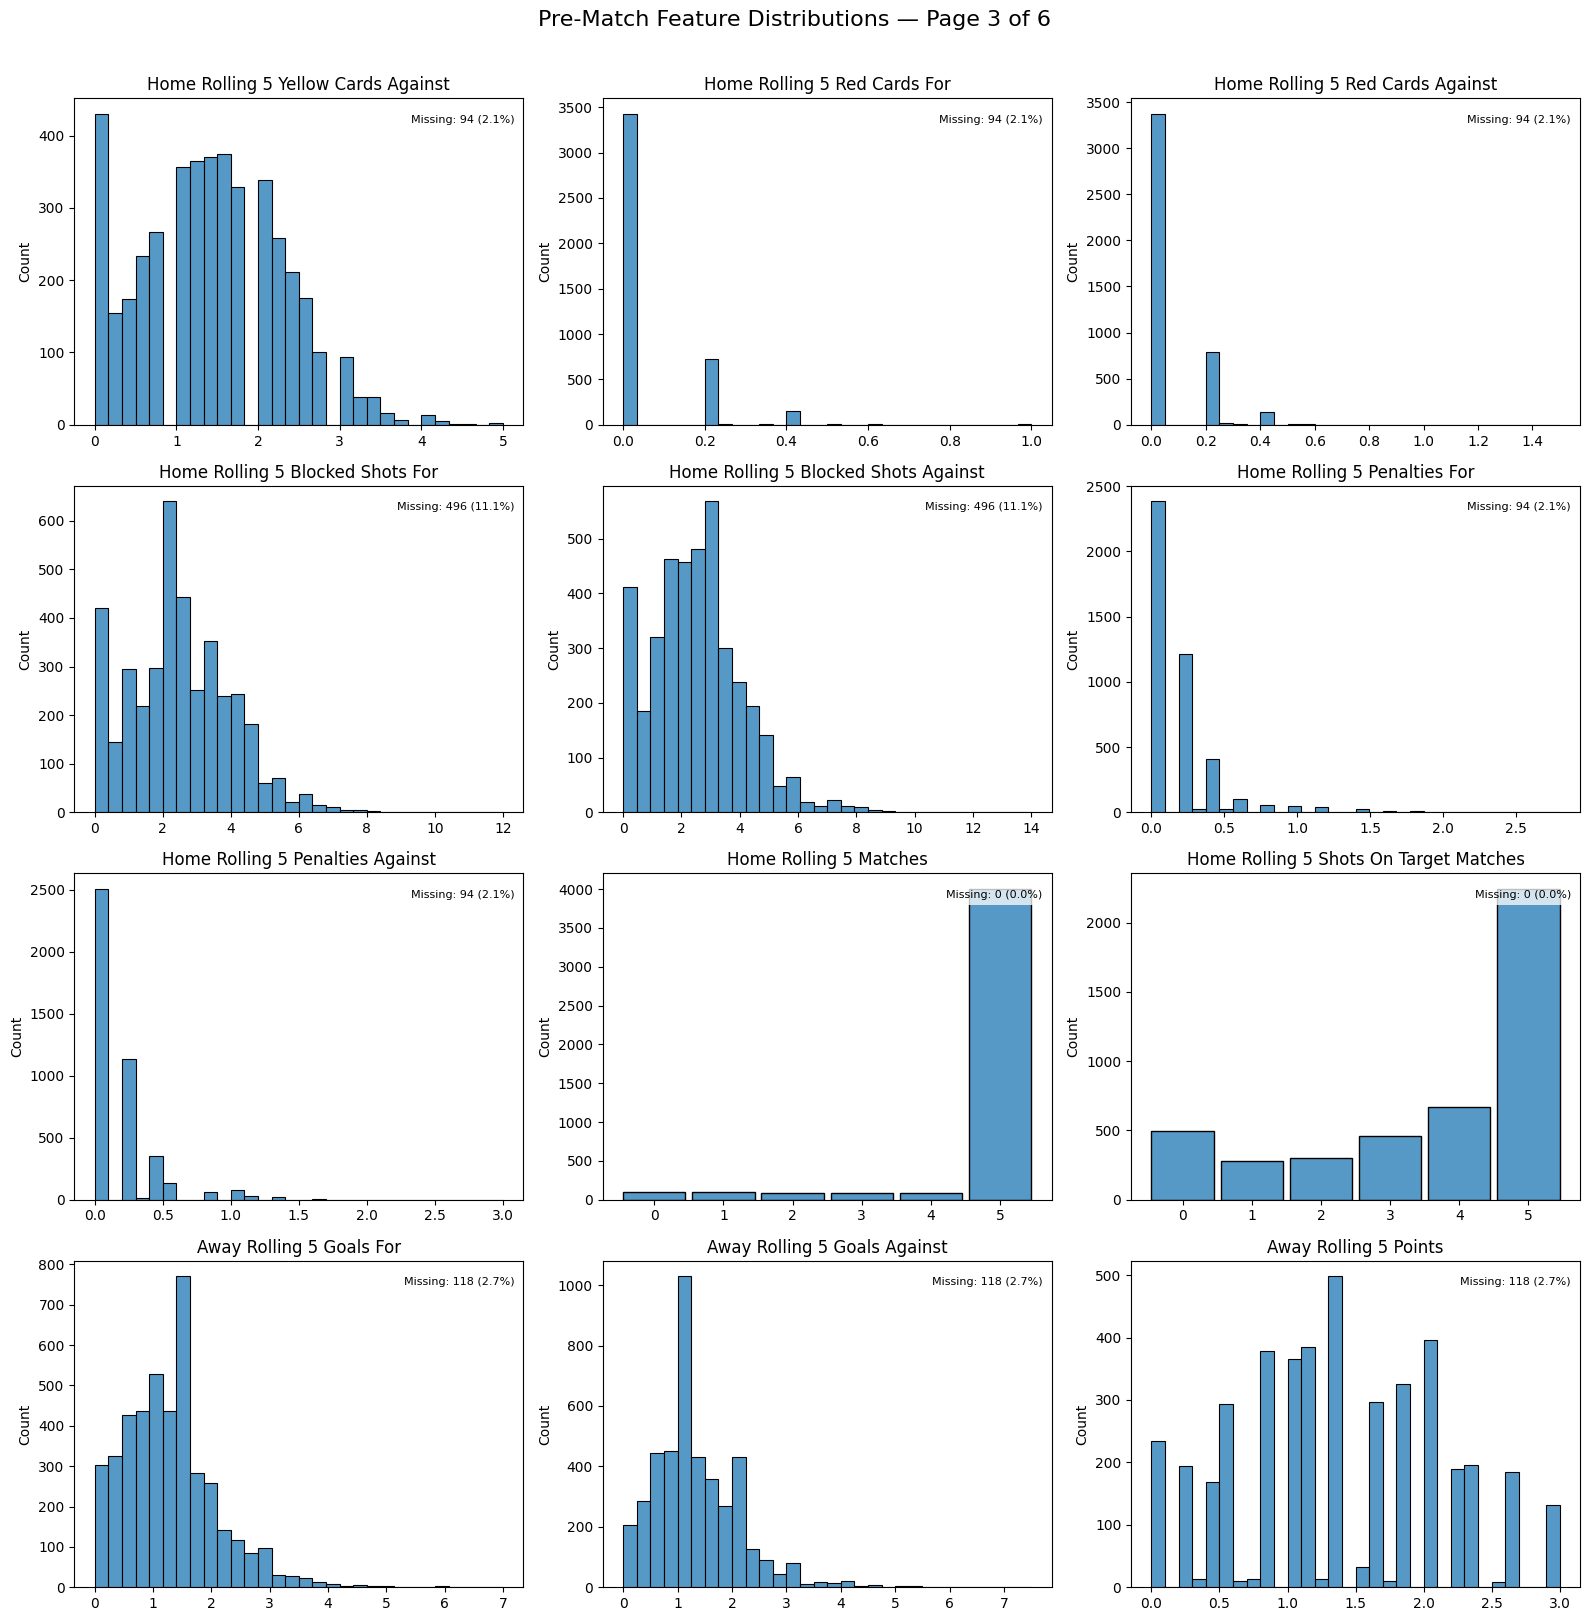

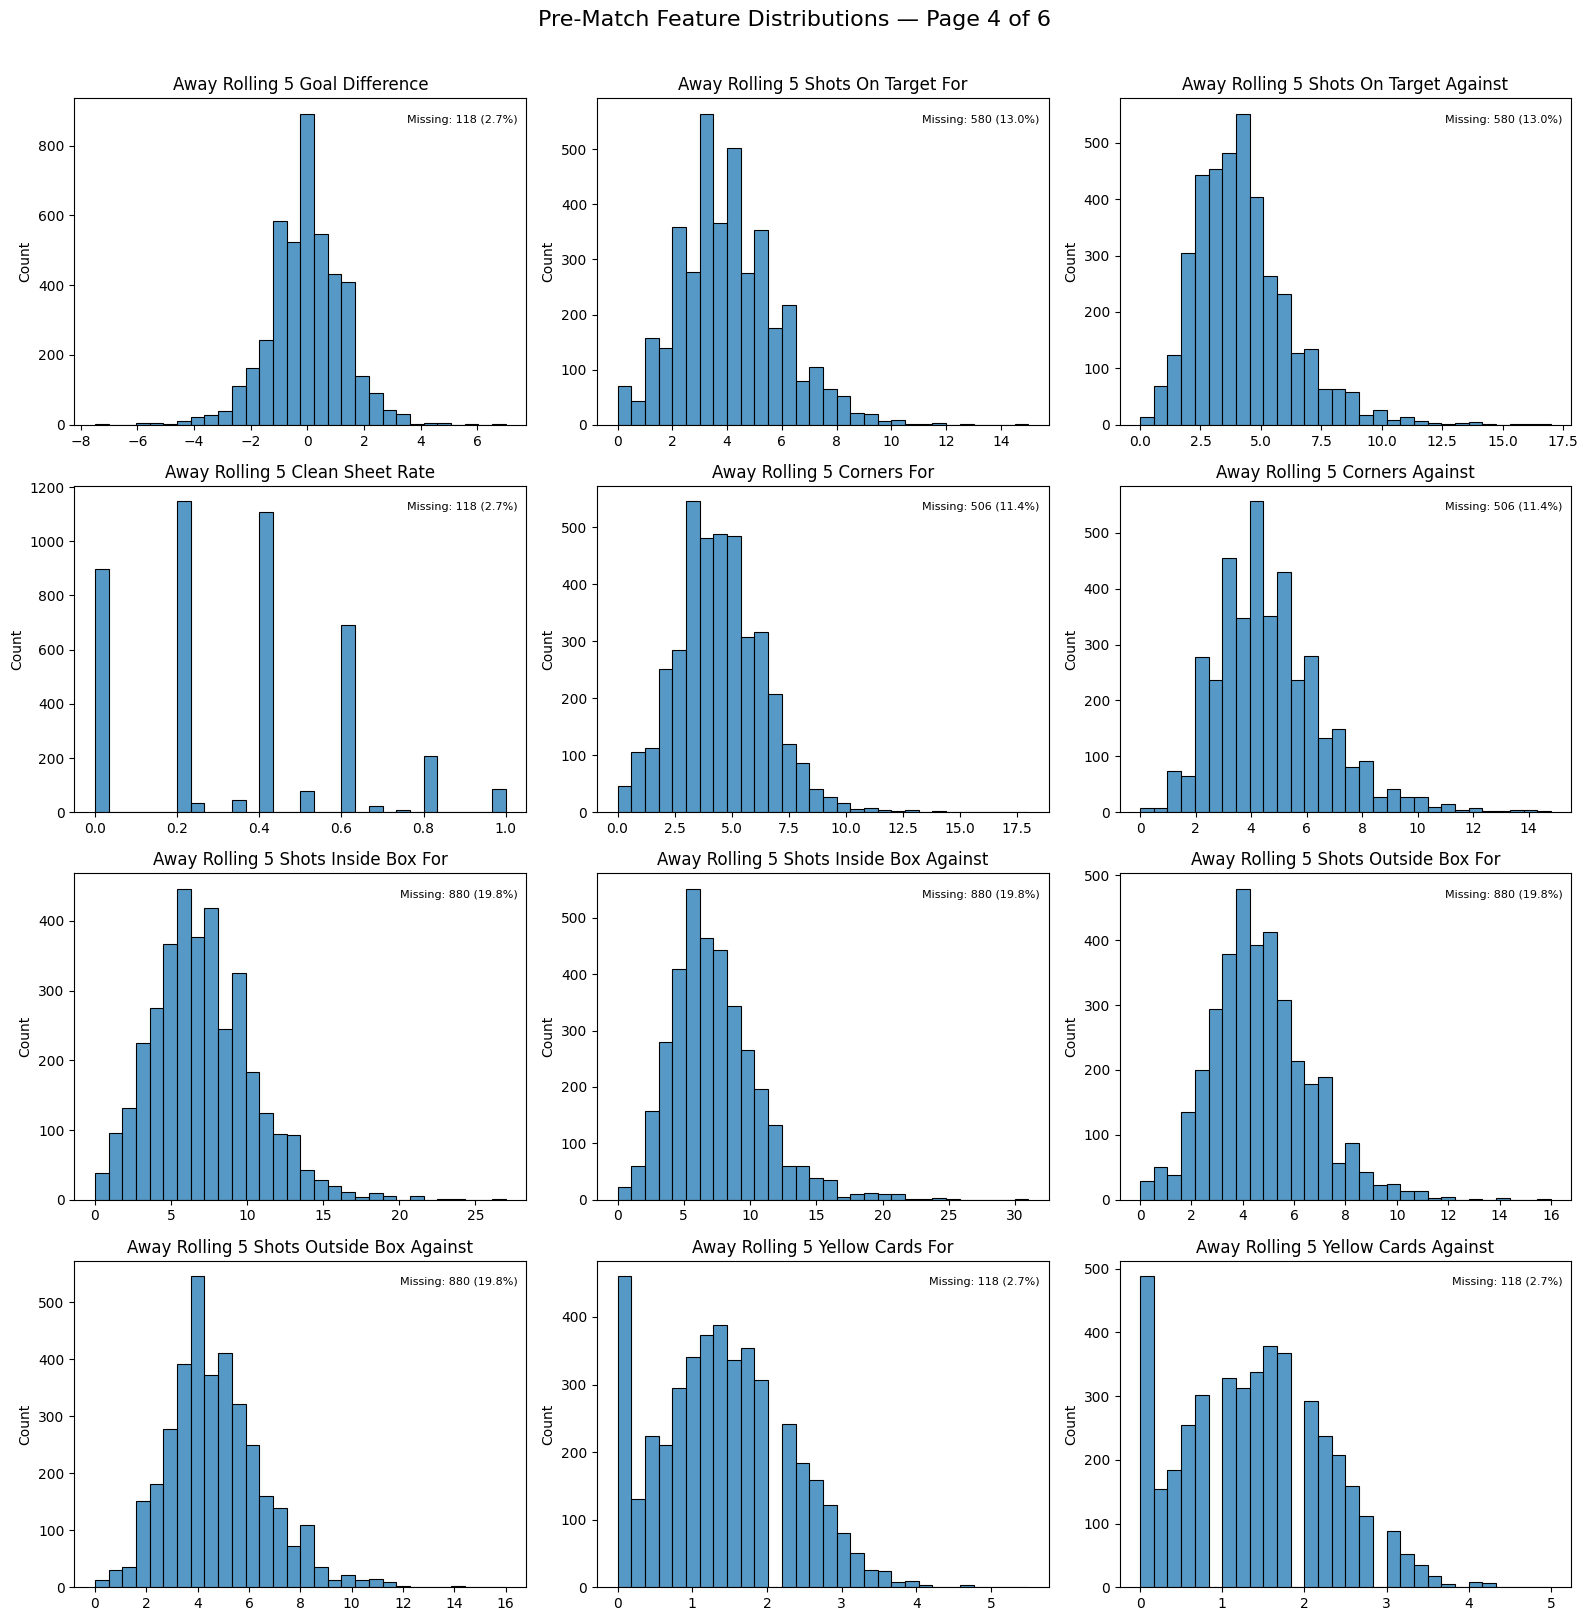

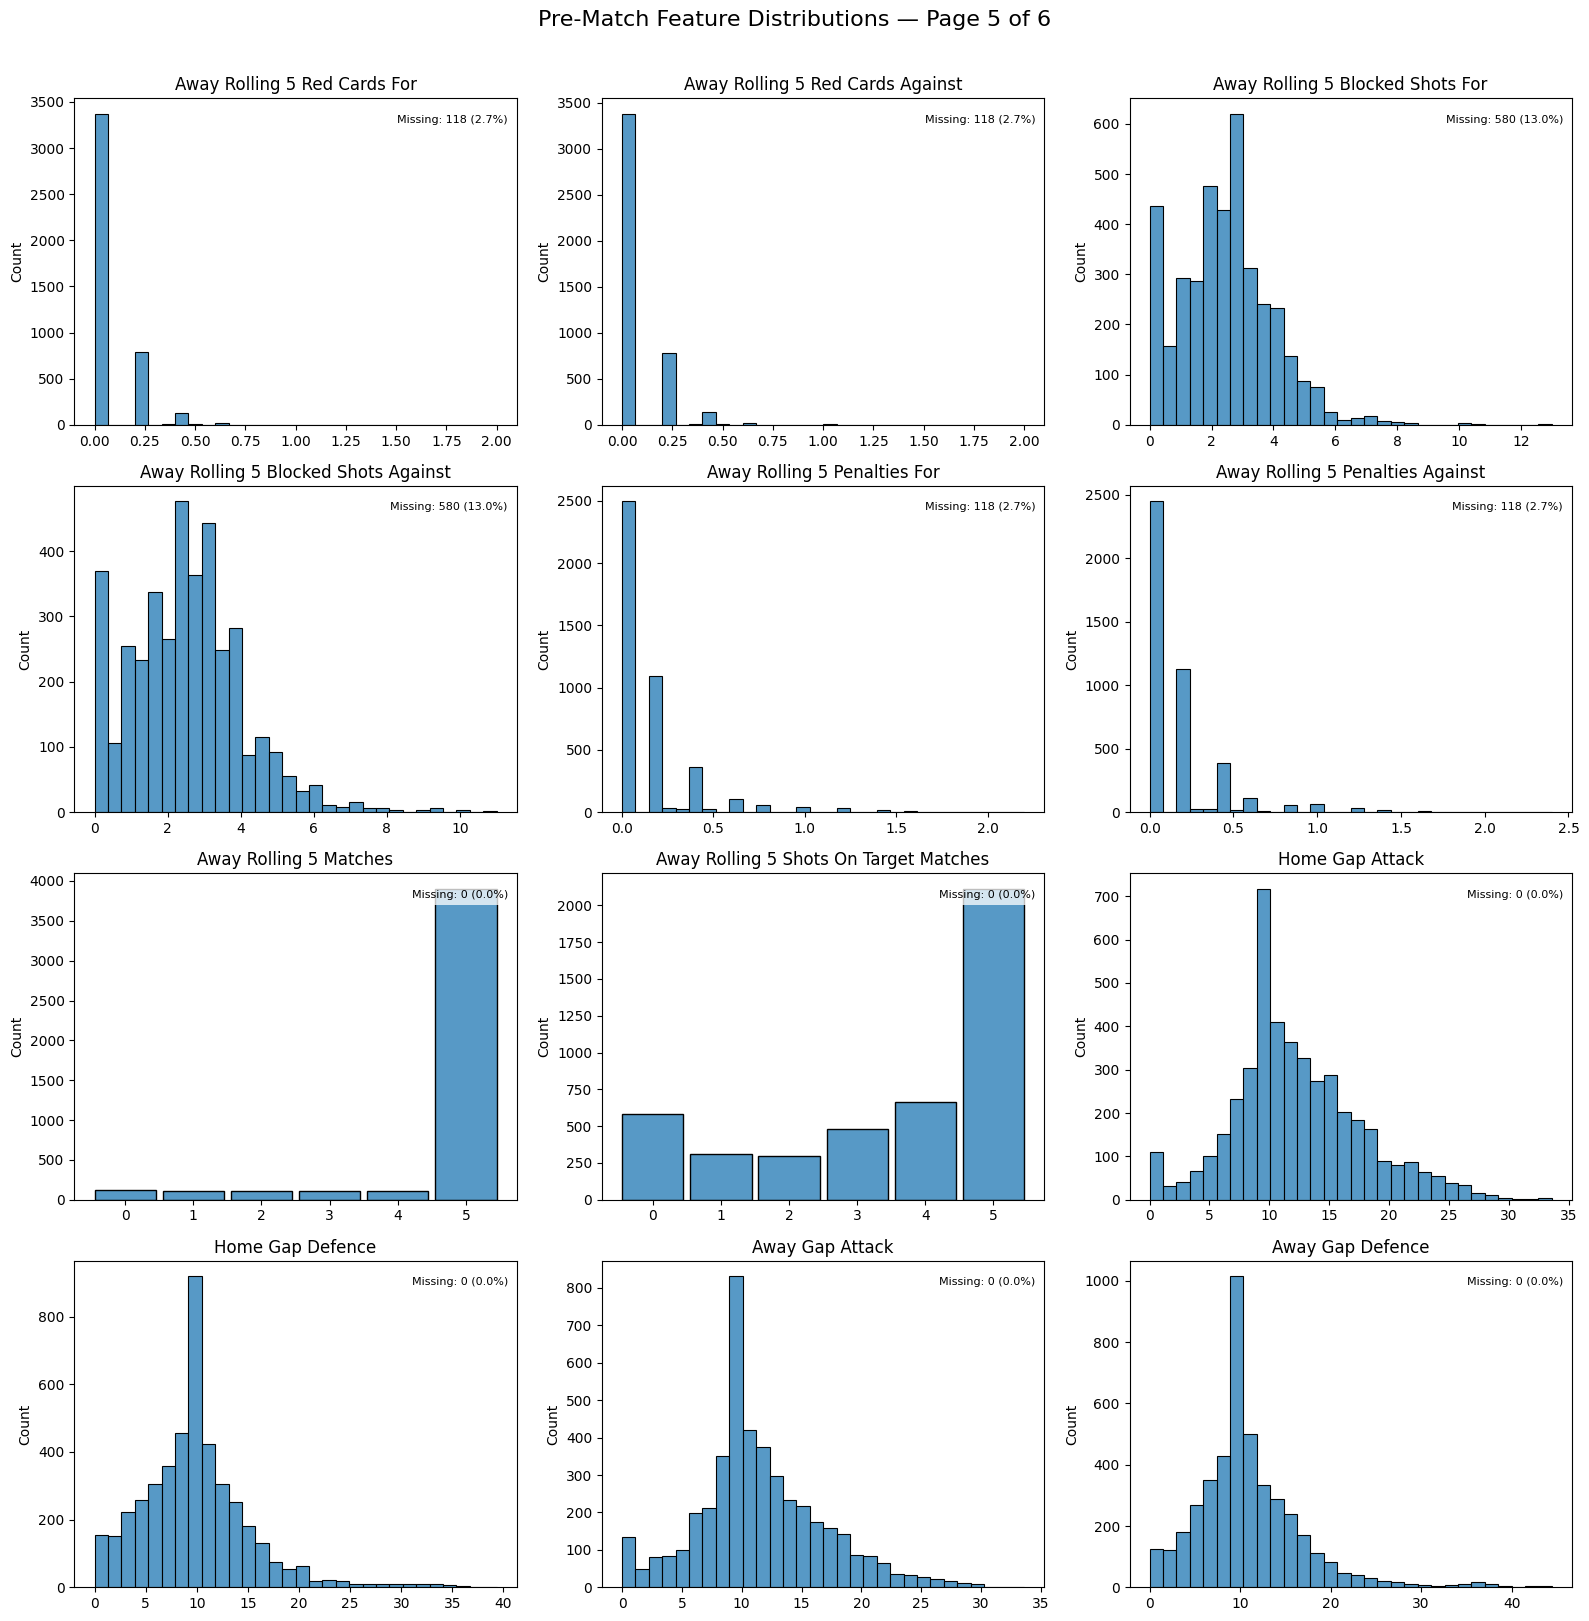

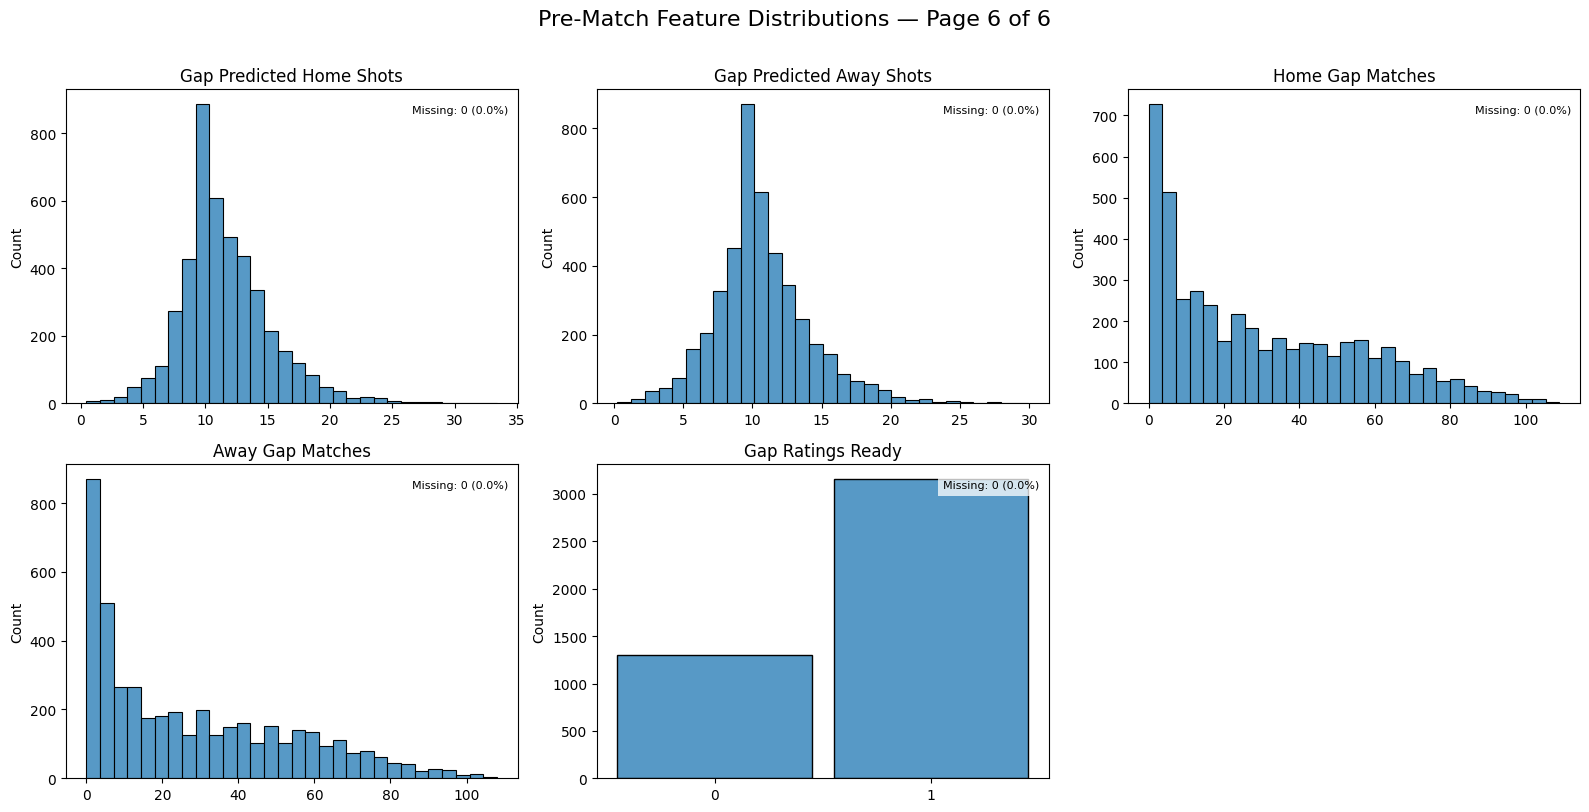

In [27]:
# ============================================================
# LEAKAGE-SAFE HISTOGRAMS
# ============================================================

PLOTS_PER_PAGE = 12
PLOT_COLUMNS = 3
CONTINUOUS_BINS = 30
MAX_DISCRETE_VALUES = 60

total_pages = int(np.ceil(
    len(pre_match_feature_columns) / PLOTS_PER_PAGE
))

for page_start in range(
    0,
    len(pre_match_feature_columns),
    PLOTS_PER_PAGE,
):
    page_columns = pre_match_feature_columns[
        page_start:page_start + PLOTS_PER_PAGE
    ]

    plot_rows = int(np.ceil(
        len(page_columns) / PLOT_COLUMNS
    ))

    fig, axes = plt.subplots(
        plot_rows,
        PLOT_COLUMNS,
        figsize=(16, 4 * plot_rows),
    )

    axes = np.atleast_1d(axes).flatten()

    for axis, column in zip(axes, page_columns):
        non_missing = model_data[column].dropna()

        integer_valued = (
            not non_missing.empty
            and np.allclose(
                non_missing.to_numpy(dtype=float),
                np.round(
                    non_missing.to_numpy(dtype=float)
                ),
            )
        )

        is_discrete = (
            integer_valued
            and non_missing.nunique()
            <= MAX_DISCRETE_VALUES
        )

        if non_missing.empty:
            axis.text(
                0.5,
                0.5,
                "No observed values",
                transform=axis.transAxes,
                ha="center",
                va="center",
            )

        elif is_discrete:
            sns.histplot(
                x=non_missing,
                ax=axis,
                discrete=True,
                shrink=0.9,
            )

            minimum = int(non_missing.min())
            maximum = int(non_missing.max())

            if maximum - minimum <= 30:
                axis.set_xticks(
                    np.arange(minimum, maximum + 1)
                )

        else:
            sns.histplot(
                x=non_missing,
                ax=axis,
                bins=CONTINUOUS_BINS,
            )

        missing_count = model_data[column].isna().sum()
        missing_percentage = (
            100 * missing_count / len(model_data)
        )

        axis.set_title(
            column.replace("_", " ").title()
        )
        axis.set_xlabel("")
        axis.set_ylabel("Count")

        axis.text(
            0.98,
            0.95,
            (
                f"Missing: {missing_count:,} "
                f"({missing_percentage:.1f}%)"
            ),
            transform=axis.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox={
                "facecolor": "white",
                "alpha": 0.75,
                "edgecolor": "none",
            },
        )

    for axis in axes[len(page_columns):]:
        axis.set_visible(False)

    page_number = (
        page_start // PLOTS_PER_PAGE + 1
    )

    fig.suptitle(
        (
            "Pre-Match Feature Distributions — "
            f"Page {page_number} of {total_pages}"
        ),
        fontsize=16,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

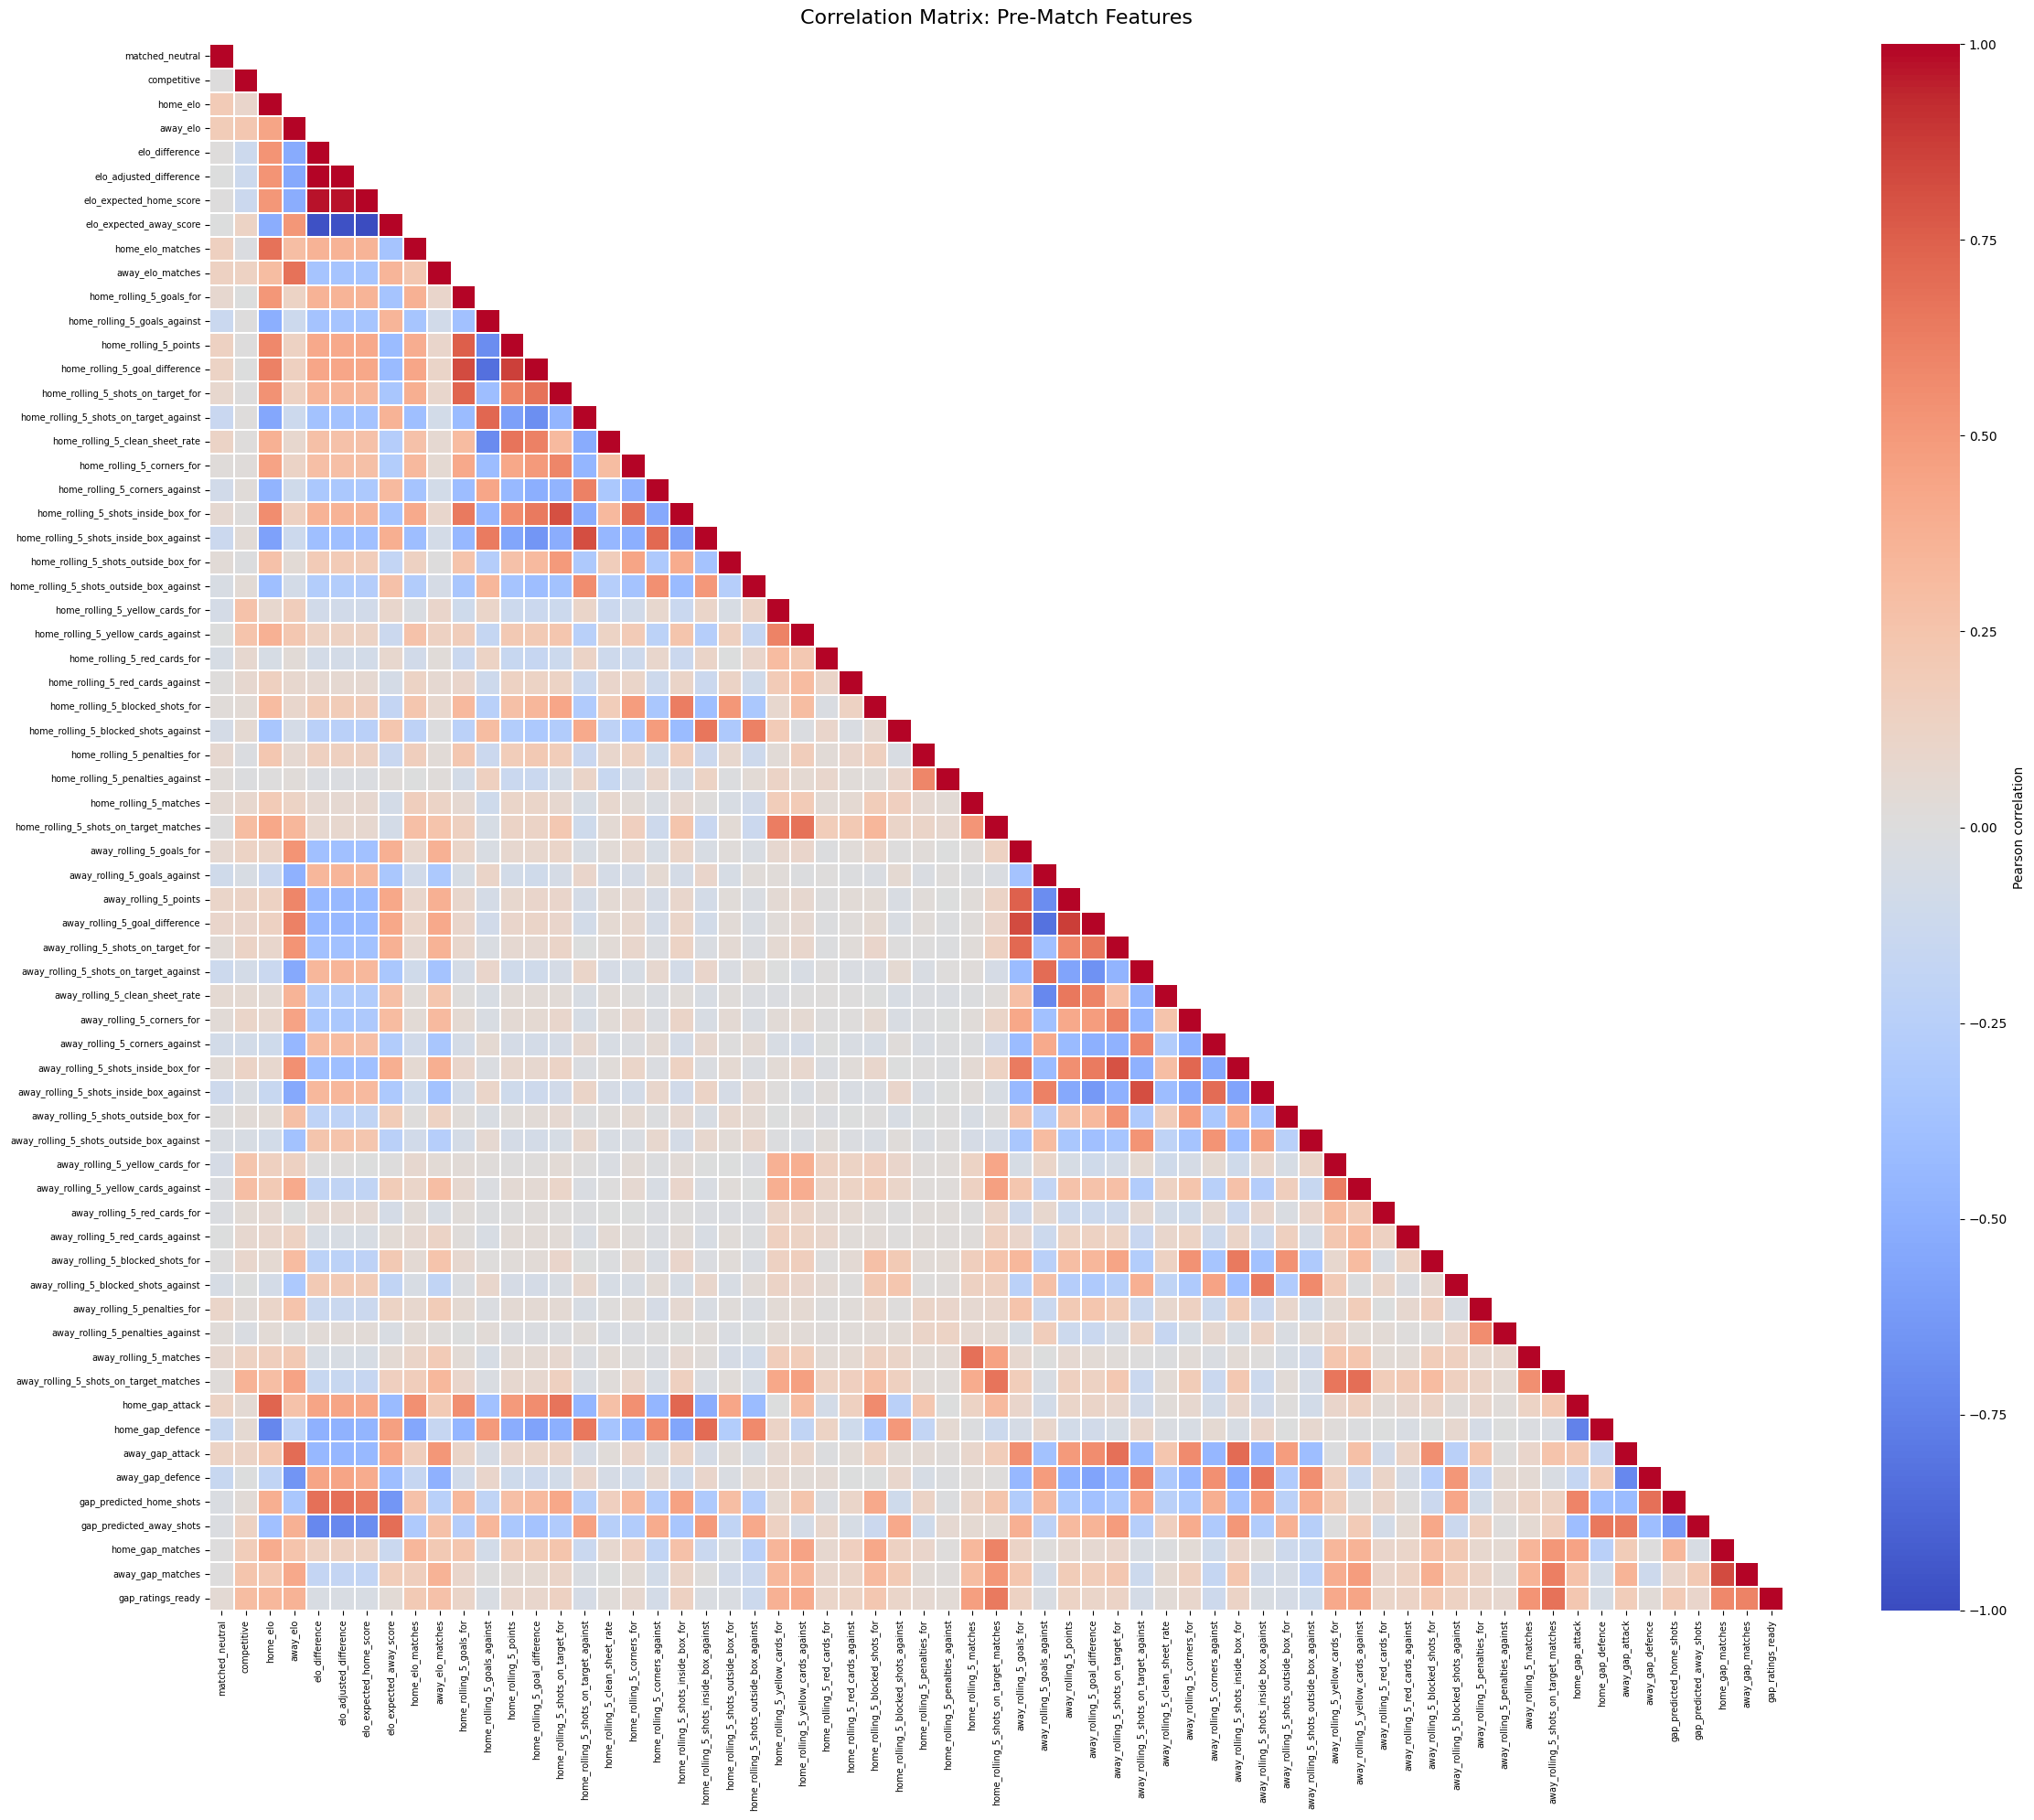

,matched_neutral,competitive,home_elo,away_elo,elo_difference,elo_adjusted_difference,elo_expected_home_score,elo_expected_away_score,home_elo_matches,away_elo_matches,...,away_rolling_5_shots_on_target_matches,home_gap_attack,home_gap_defence,away_gap_attack,away_gap_defence,gap_predicted_home_shots,gap_predicted_away_shots,home_gap_matches,away_gap_matches,gap_ratings_ready
matched_neutral,1.000000,0.000458,0.199716,0.187887,0.010882,-0.001261,0.005829,-0.005829,0.150016,0.144954,...,0.019175,0.131942,-0.154476,0.126506,-0.151777,-0.025640,-0.022520,0.001546,0.002804,0.047375
competitive,0.000458,1.000000,0.099610,0.226742,-0.120574,-0.120587,-0.131291,0.131291,-0.015710,0.135057,...,0.363772,0.047703,0.058315,0.120460,-0.001190,0.034237,0.137666,0.185359,0.245514,0.299895
home_elo,0.199716,0.099610,1.000000,0.441703,0.527182,0.524788,0.512266,-0.512266,0.679048,0.303065,...,0.292998,0.728806,-0.721997,0.226507,-0.190790,0.383189,-0.385335,0.401403,0.227750,0.329068
away_elo,0.187887,0.226742,0.441703,1.000000,-0.529506,-0.531819,-0.514400,0.514400,0.292388,0.679533,...,0.450239,0.263077,-0.207710,0.695621,-0.653937,-0.335838,0.373236,0.250738,0.414269,0.365836
elo_difference,0.010882,-0.120574,0.527182,-0.529506,1.000000,0.999926,0.971588,-0.971588,0.365133,-0.357063,...,-0.149404,0.439944,-0.485947,-0.444689,0.438980,0.680414,-0.717865,0.142056,-0.177030,-0.035356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gap_predicted_home_shots,-0.025640,0.034237,0.383189,-0.335838,0.680414,0.680765,0.642094,-0.642094,0.272002,-0.245787,...,0.136436,0.601507,-0.392432,-0.414991,0.686210,1.000000,-0.622625,0.336102,0.099753,0.196724
gap_predicted_away_shots,-0.022520,0.137666,-0.385335,0.373236,-0.717865,-0.717633,-0.690793,0.690793,-0.299386,0.268808,...,0.168294,-0.404846,0.652221,0.644391,-0.399631,-0.622625,1.000000,-0.040767,0.211847,0.100689
home_gap_matches,0.001546,0.185359,0.401403,0.250738,0.142056,0.142045,0.136017,-0.136017,0.342353,0.211948,...,0.510829,0.452067,-0.242095,0.191133,0.003091,0.336102,-0.040767,1.000000,0.826315,0.581461
away_gap_matches,0.002804,0.245514,0.227750,0.414269,-0.177030,-0.177074,-0.183540,0.183540,0.169589,0.364575,...,0.623640,0.263787,-0.076834,0.353408,-0.117103,0.099753,0.211847,0.826315,1.000000,0.605810


In [28]:
# ============================================================
# CORRELATION BETWEEN PRE-MATCH FEATURES
# ============================================================

feature_correlation_matrix = model_data[
    pre_match_feature_columns
].corr()

upper_triangle_mask = np.triu(
    np.ones_like(
        feature_correlation_matrix,
        dtype=bool,
    ),
    k=1,
)

plt.figure(figsize=(24, 20))

sns.heatmap(
    feature_correlation_matrix,
    mask=upper_triangle_mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2,
    cbar_kws={
        "label": "Pearson correlation"
    },
)

plt.title(
    "Correlation Matrix: Pre-Match Features",
    fontsize=16,
    pad=16,
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

feature_correlation_matrix

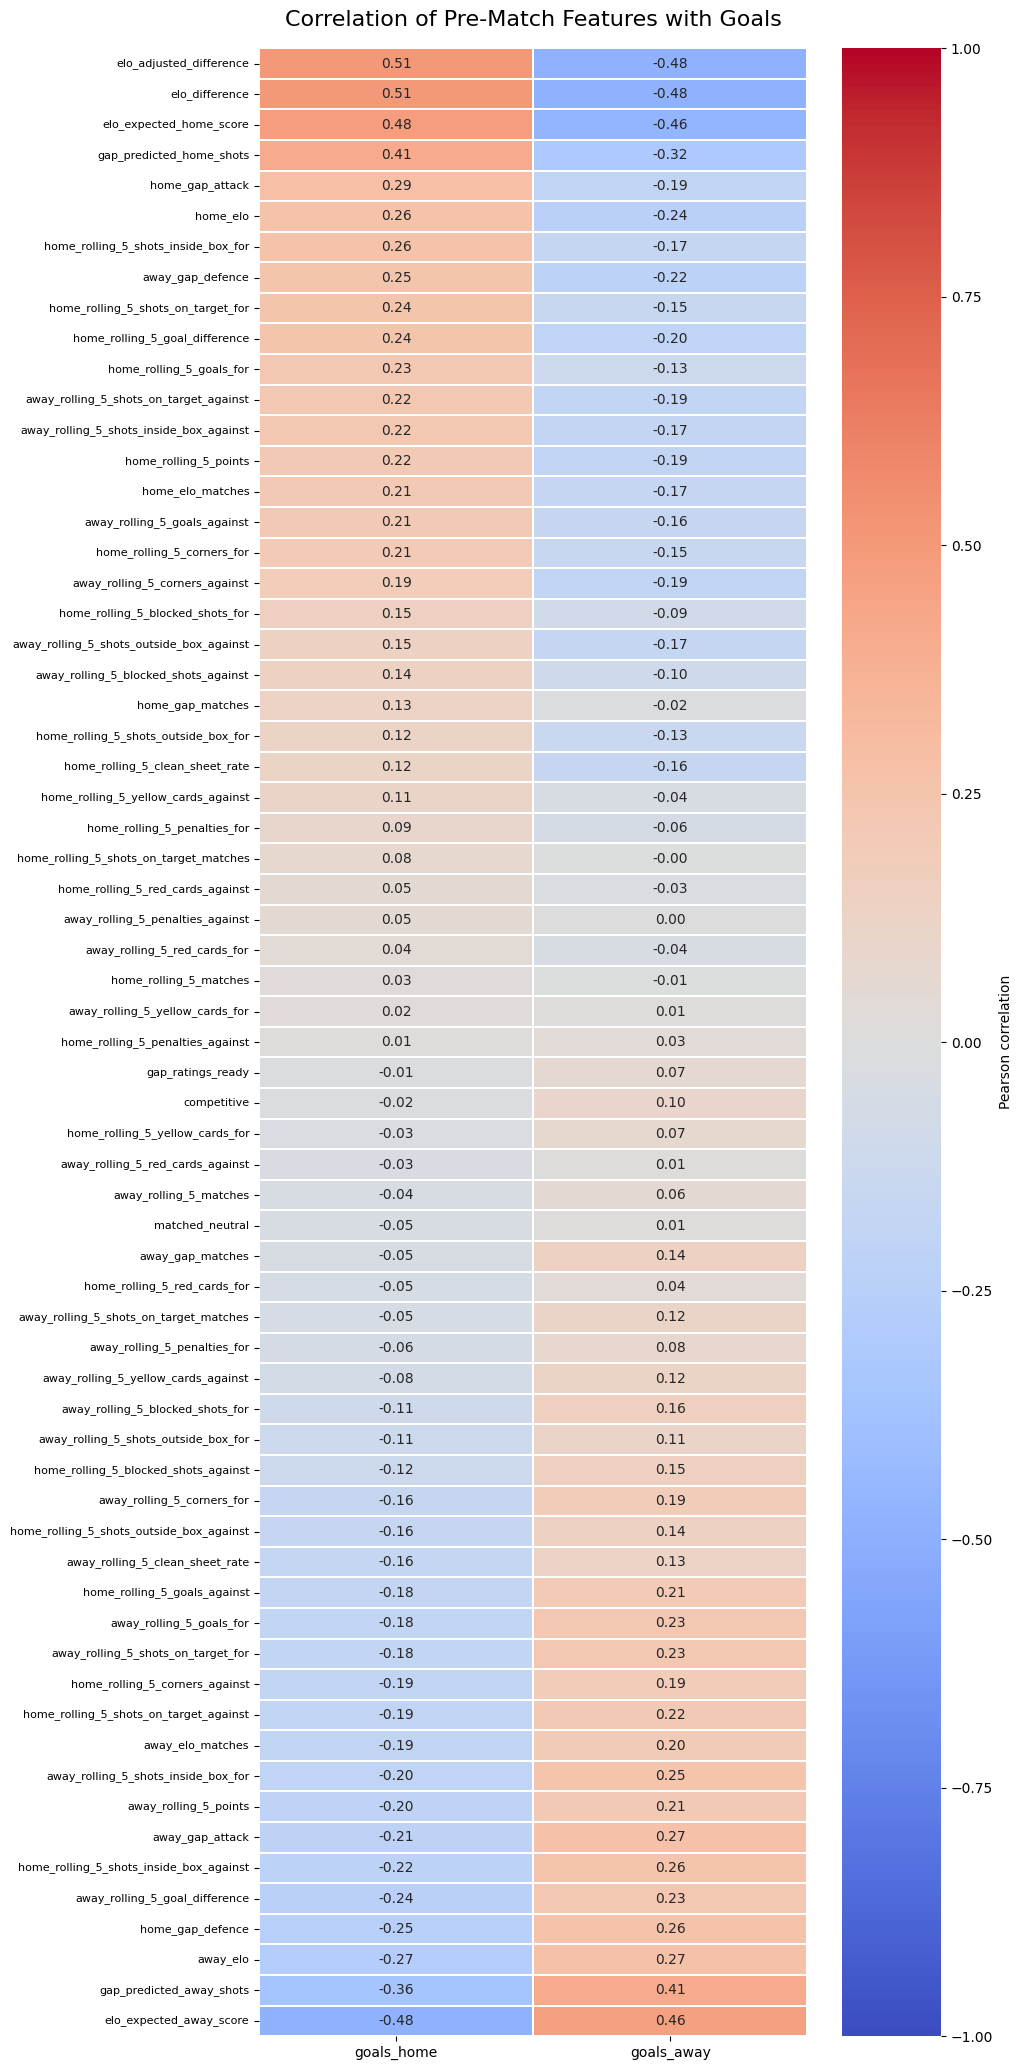

,goals_home,goals_away
elo_adjusted_difference,0.506247,-0.476832
elo_difference,0.505660,-0.476657
elo_expected_home_score,0.480047,-0.464782
gap_predicted_home_shots,0.413418,-0.320307
home_gap_attack,0.288390,-0.193171
...,...,...
away_rolling_5_goal_difference,-0.238442,0.232878
home_gap_defence,-0.253185,0.259738
away_elo,-0.271062,0.268119
gap_predicted_away_shots,-0.359273,0.408055


In [29]:
# ============================================================
# PRE-MATCH FEATURES AGAINST FINAL GOALS
# Outcomes are targets here, never predictors.
# ============================================================

goal_outcomes = [
    "goals_home",
    "goals_away",
]

goal_correlation_matrix = (
    model_data[
        pre_match_feature_columns + goal_outcomes
    ]
    .corr()
    .loc[
        pre_match_feature_columns,
        goal_outcomes,
    ]
    .sort_values(
        "goals_home",
        ascending=False,
    )
)

plt.figure(figsize=(
    10,
    max(10, len(pre_match_feature_columns) * 0.32),
))

sns.heatmap(
    goal_correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.2,
    cbar_kws={
        "label": "Pearson correlation"
    },
)

plt.title(
    "Correlation of Pre-Match Features with Goals",
    fontsize=16,
    pad=16,
)

plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

goal_correlation_matrix

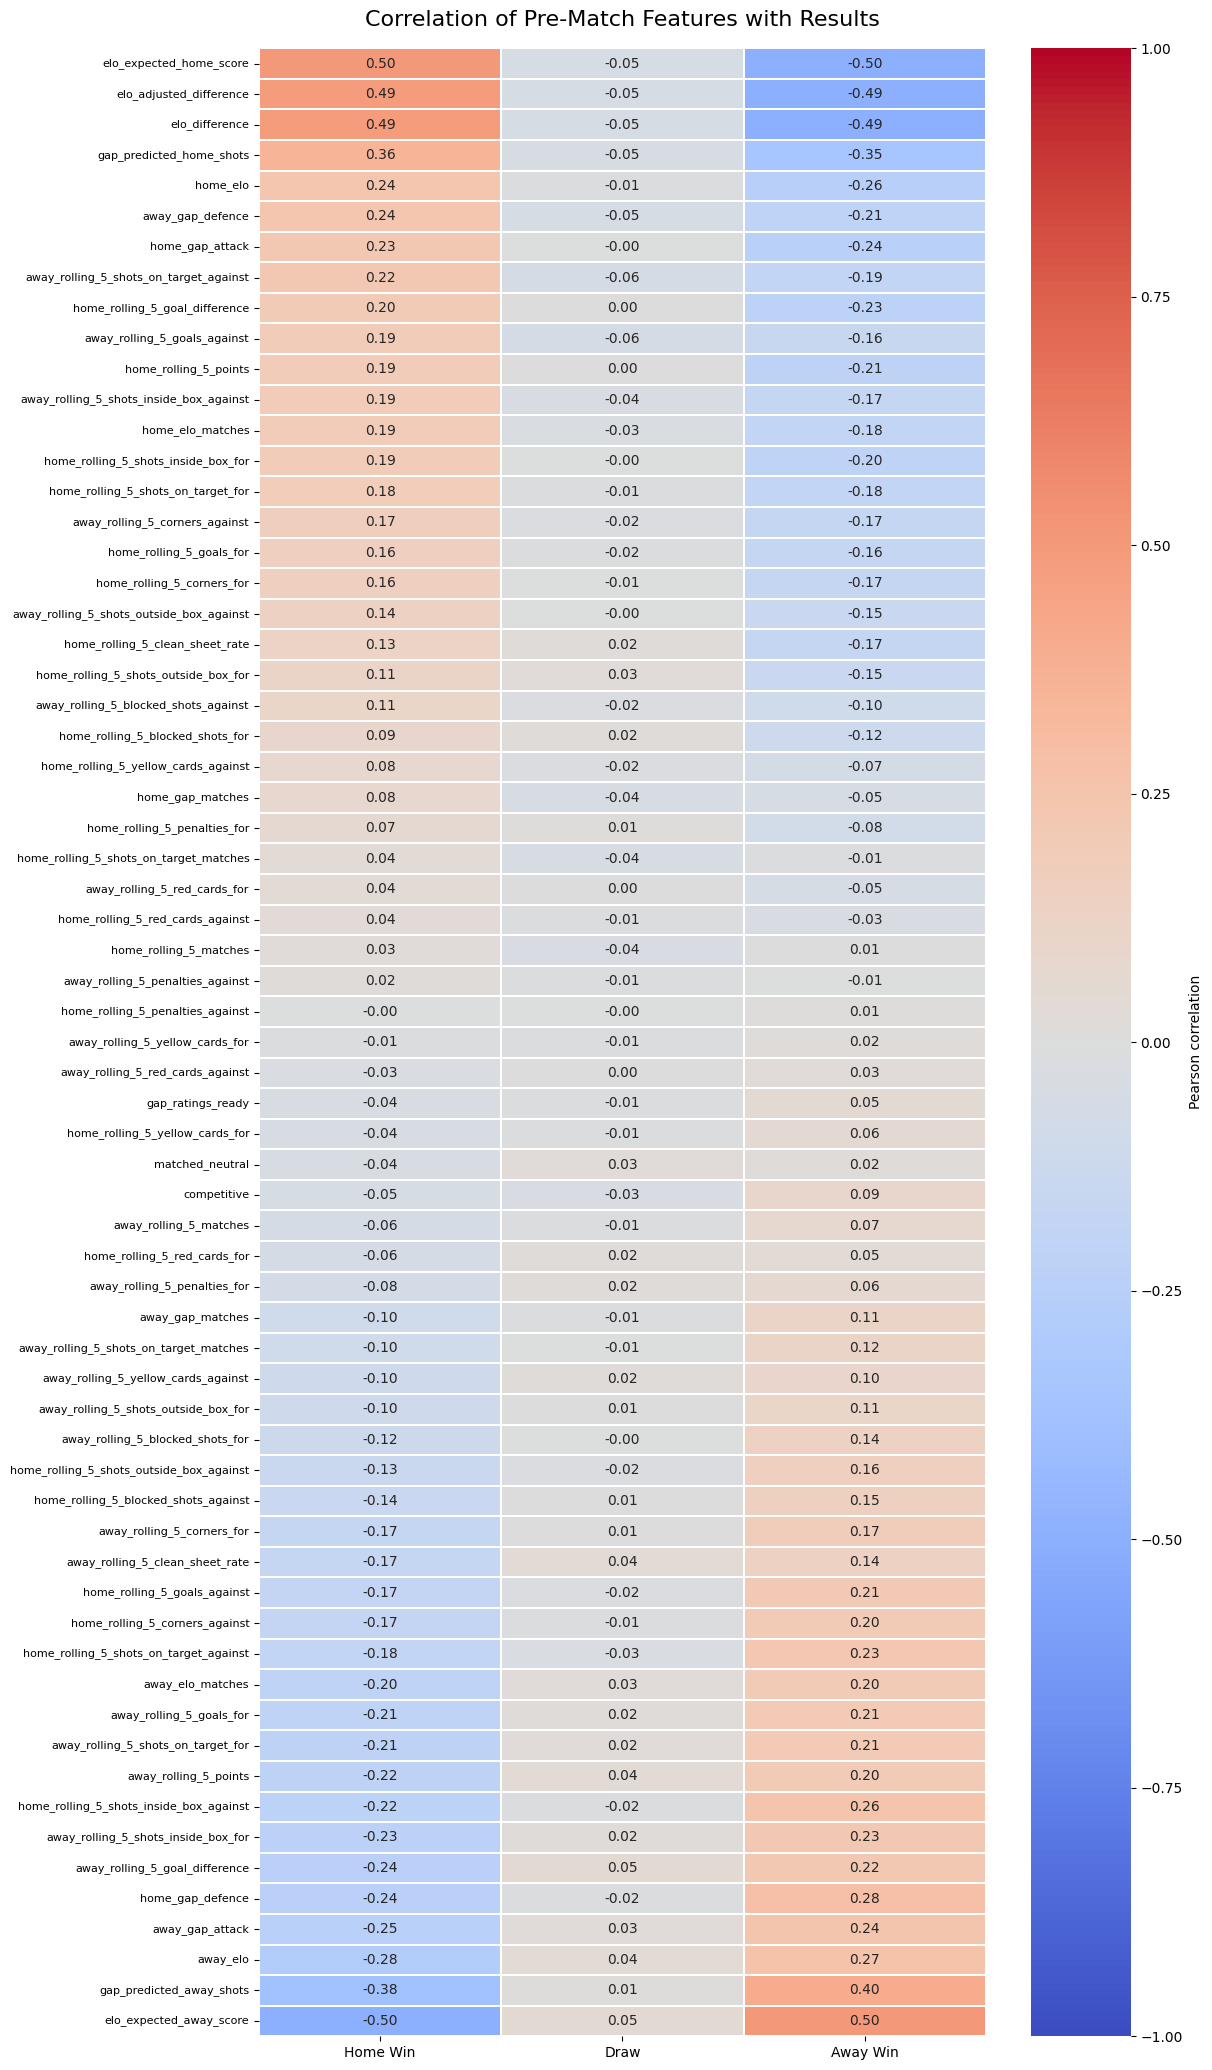

,Home Win,Draw,Away Win
elo_expected_home_score,0.503800,-0.053684,-0.503177
elo_adjusted_difference,0.491475,-0.049310,-0.493743
elo_difference,0.490927,-0.048957,-0.493472
gap_predicted_home_shots,0.357416,-0.046472,-0.349093
home_elo,0.240682,-0.009121,-0.255913
...,...,...,...
home_gap_defence,-0.241769,-0.015439,0.280184
away_gap_attack,-0.245956,0.028654,0.243354
away_elo,-0.278043,0.042584,0.265526
gap_predicted_away_shots,-0.376129,0.010043,0.403887


In [30]:
# ============================================================
# PRE-MATCH FEATURES AGAINST MATCH RESULTS
# ============================================================

result_outcomes = pd.DataFrame(
    index=model_data.index,
    data={
        "Home Win": (
            model_data["goals_home"]
            > model_data["goals_away"]
        ).astype(int),

        "Draw": (
            model_data["goals_home"]
            == model_data["goals_away"]
        ).astype(int),

        "Away Win": (
            model_data["goals_home"]
            < model_data["goals_away"]
        ).astype(int),
    },
)

result_correlation_data = pd.concat(
    [
        model_data[pre_match_feature_columns],
        result_outcomes,
    ],
    axis=1,
)

result_correlation_matrix = (
    result_correlation_data
    .corr()
    .loc[
        pre_match_feature_columns,
        result_outcomes.columns,
    ]
    .sort_values(
        "Home Win",
        ascending=False,
    )
)

plt.figure(figsize=(
    12,
    max(10, len(pre_match_feature_columns) * 0.32),
))

sns.heatmap(
    result_correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.2,
    cbar_kws={
        "label": "Pearson correlation"
    },
)

plt.title(
    "Correlation of Pre-Match Features with Results",
    fontsize=16,
    pad=16,
)

plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

result_correlation_matrix

# 5. Prepare Modelling Data

In [31]:
# Remove rolling features for home/away shots inside/outside box
# as these statistics are particularly sparse

analysis_data = model_data.drop(
    columns=[
        column
        for column in model_data.columns
        if (
            "rolling_" in column
            and (
                "shots_inside_box" in column
                or "shots_outside_box" in column
            )
        )
    ],
    errors="ignore",
).copy()

home_shot_history_columns = [
    "home_rolling_5_shots_on_target_for",
    "home_rolling_5_shots_on_target_against",
]
away_shot_history_columns = [
    "away_rolling_5_shots_on_target_for",
    "away_rolling_5_shots_on_target_against",
]

analysis_data["home_missing_shots_on_target_history"] = (
    analysis_data[home_shot_history_columns].isna().any(axis=1).astype("int8")
)
analysis_data["away_missing_shots_on_target_history"] = (
    analysis_data[away_shot_history_columns].isna().any(axis=1).astype("int8")
)

rows_before_filtering = len(analysis_data)
valid_modelling_rows = (
    analysis_data[["goals_home", "goals_away"]].notna().all(axis=1)
    & pd.to_datetime(analysis_data["date"], errors="coerce", utc=True).notna()
)
analysis_data = analysis_data.loc[valid_modelling_rows].copy()
rows_after_filtering = len(analysis_data)

rolling_columns = [
    column for column in analysis_data.columns if "rolling_5_" in column
]
rolling_missingness = (
    analysis_data[rolling_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_values")
    .to_frame()
)

PREVIOUS_NOTEBOOK_ROWS = 3629
print(f"Rows before filtering: {rows_before_filtering:,}")
print(f"Rows after filtering: {rows_after_filtering:,}")
print(
    "Rows retained compared with the previous notebook: "
    f"{rows_after_filtering - PREVIOUS_NOTEBOOK_ROWS:+,}"
)
rolling_missingness.loc[lambda frame: frame["missing_values"] > 0]


Rows before filtering: 4,452
Rows after filtering: 4,452
Rows retained compared with the previous notebook: +823


,missing_values
away_rolling_5_blocked_shots_against,580
away_rolling_5_blocked_shots_for,580
away_rolling_5_shots_on_target_against,580
away_rolling_5_shots_on_target_for,580
away_rolling_5_corners_against,506
away_rolling_5_corners_for,506
home_rolling_5_shots_on_target_for,496
home_rolling_5_shots_on_target_against,496
home_rolling_5_blocked_shots_for,496
home_rolling_5_blocked_shots_against,496


## 5.1 Chronological Train, Validation and Test Split

The oldest approximately 70% of fixtures form training data, the next 15%
validation data, and the newest 15% test data. Fixtures sharing a kickoff
timestamp remain in one partition. All preprocessing is fitted on `train_df`
and applied unchanged to later periods.


In [32]:
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

split_data = analysis_data.copy()
split_data["_split_date"] = pd.to_datetime(
    split_data["date"], errors="coerce", utc=True
)
split_data = split_data.sort_values(
    ["_split_date", "fixture_id"], kind="mergesort"
).reset_index(drop=True)

number_of_matches = len(split_data)
provisional_train_end = round(number_of_matches * TRAIN_RATIO)
provisional_validation_end = round(
    number_of_matches * (TRAIN_RATIO + VALIDATION_RATIO)
)


def move_boundary_after_timestamp(data, boundary):
    """Keep every fixture at a shared timestamp in one partition."""
    boundary = min(max(int(boundary), 1), len(data) - 1)
    boundary_timestamp = data.loc[boundary - 1, "_split_date"]
    while (
        boundary < len(data)
        and data.loc[boundary, "_split_date"] == boundary_timestamp
    ):
        boundary += 1
    return boundary


train_end = move_boundary_after_timestamp(
    split_data, provisional_train_end
)
validation_end = move_boundary_after_timestamp(
    split_data, provisional_validation_end
)

train_df = (
    split_data.iloc[:train_end]
    .drop(columns="_split_date")
    .reset_index(drop=True)
)
validation_df = (
    split_data.iloc[train_end:validation_end]
    .drop(columns="_split_date")
    .reset_index(drop=True)
)
test_df = (
    split_data.iloc[validation_end:]
    .drop(columns="_split_date")
    .reset_index(drop=True)
)

assert len(train_df) + len(validation_df) + len(test_df) == len(analysis_data)
assert set(train_df["fixture_id"]).isdisjoint(validation_df["fixture_id"])
assert set(train_df["fixture_id"]).isdisjoint(test_df["fixture_id"])
assert set(validation_df["fixture_id"]).isdisjoint(test_df["fixture_id"])

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "percentage": [
        len(train_df) / number_of_matches * 100,
        len(validation_df) / number_of_matches * 100,
        len(test_df) / number_of_matches * 100,
    ],
    "start_date": [
        pd.to_datetime(train_df["date"], utc=True).min(),
        pd.to_datetime(validation_df["date"], utc=True).min(),
        pd.to_datetime(test_df["date"], utc=True).min(),
    ],
    "end_date": [
        pd.to_datetime(train_df["date"], utc=True).max(),
        pd.to_datetime(validation_df["date"], utc=True).max(),
        pd.to_datetime(test_df["date"], utc=True).max(),
    ],
})
split_summary["percentage"] = split_summary["percentage"].round(2)
split_summary


,split,rows,percentage,start_date,end_date
0,Train,3116,69.99,2017-03-23 20:30:00+00:00,2024-01-15 14:30:00+00:00
1,Validation,677,15.21,2024-01-15 17:00:00+00:00,2025-03-20 19:45:00+00:00
2,Test,659,14.80,2025-03-20 23:00:00+00:00,2026-06-07 20:00:00+00:00


# 6. Leakage-Safe Baselines

Baselines are useful for understanding how much value the engineered models add.

Goal Baselines predict the number of goals scored by each team. They use only training-period averages and Elo expectations.

Results baselines predict the final result of the match. They use only training class distributions or its most common class.

In [33]:
# Import metrics for evaluating goal predictions and result classifications.
from sklearn.metrics import (
    accuracy_score, # proportion of correct results predicted
    balanced_accuracy_score, #average recall across home wins, draws, away wins
    classification_report, # precision, recall and F1 by class 
    confusion_matrix, # counts actual vs predicted classes
    mean_absolute_error, # average absolute goal error
    mean_poisson_deviance, # evaluates predicted goal rates
    mean_squared_error, # used to calculate RMSE 
)

RESULT_CLASS_ORDER = ["Home Win", "Draw", "Away Win"]
# Map each result class to its corresponding predicted-probability column.
RESULT_PROBABILITY_COLUMNS = {
    "Home Win": "probability_home_win",
    "Draw": "probability_draw",
    "Away Win": "probability_away_win",
}


# Convert final home and away scores into Home Win, Draw or Away Win targets.
def create_result_target(data):
    return pd.Series(
        np.select(
            [
                data["goals_home"] > data["goals_away"],
                data["goals_home"] == data["goals_away"],
            ],
            ["Home Win", "Draw"],
            default="Away Win",
        ),
        index=data.index,
        name="result",
    )

# Convert two-column expected-goal predictions into result classes.
def results_from_expected_goals(predicted):
    # Standardise predictions as an array with home and away goal columns.
    predicted = np.asarray(predicted)

    # Classify the result by comparing home and away expected goals.
    return np.select(
        [
            predicted[:, 0] > predicted[:, 1],
            np.isclose(
                predicted[:, 0],
                predicted[:, 1],
            ),
        ],
        ["Home Win", "Draw"],
        default="Away Win",
    )


# Calculate multiclass log loss from predicted result probabilities.
def result_probability_log_loss(actual_results, probability_frame):
    probabilities = probability_frame[
        [RESULT_PROBABILITY_COLUMNS[label] for label in RESULT_CLASS_ORDER]
    ].to_numpy()
    class_positions = {
        class_name: position
        for position, class_name in enumerate(RESULT_CLASS_ORDER)
    }
    actual_positions = np.array([
        class_positions[class_name] for class_name in actual_results
    ])
    actual_probabilities = probabilities[
        np.arange(len(probabilities)), actual_positions
    ]
    return -np.log(np.clip(actual_probabilities, 1e-15, 1.0)).mean()

# Calculate the squared error between predicted probabilities and actual classes.
def multiclass_brier_score(actual_results, probability_frame):
    probabilities = probability_frame[
        [RESULT_PROBABILITY_COLUMNS[label] for label in RESULT_CLASS_ORDER]
    ].to_numpy()
    one_hot_actual = np.column_stack([
        np.asarray(actual_results) == label for label in RESULT_CLASS_ORDER
    ]).astype(float)
    return np.mean(np.sum((probabilities - one_hot_actual) ** 2, axis=1))

# Measure the proportion of actual draws correctly predicted as draws.
def draw_recall(actual_results, predicted_results):
    actual_results = np.asarray(actual_results)
    predicted_results = np.asarray(predicted_results)
    draw_rows = actual_results == "Draw"
    if not draw_rows.any():
        return np.nan
    return (predicted_results[draw_rows] == "Draw").mean()

# Evaluate expected home and away goals using error and derived-result metrics.
def evaluate_goal_predictions(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.clip(np.asarray(predicted, dtype=float), 0, None)
    positive_predictions = np.clip(predicted, 0.01, None)
    mae_by_team = mean_absolute_error(
        actual, predicted, multioutput="raw_values"
    )
    rmse_by_team = np.sqrt(mean_squared_error(
        actual, predicted, multioutput="raw_values"
    ))
    actual_results = results_from_expected_goals(actual)
    predicted_results = results_from_expected_goals(predicted)
    rounded_predictions = np.rint(predicted).astype(int)
    poisson_deviance = np.mean([
        mean_poisson_deviance(actual[:, side], positive_predictions[:, side])
        for side in range(2)
    ])
    return {
        "mae_home": mae_by_team[0],
        "mae_away": mae_by_team[1],
        "mae_overall": mae_by_team.mean(),
        "rmse_home": rmse_by_team[0],
        "rmse_away": rmse_by_team[1],
        "rmse_overall": rmse_by_team.mean(),
        "mean_poisson_deviance": poisson_deviance,
        "result_accuracy": accuracy_score(
            actual_results, predicted_results
        ),
        "result_balanced_accuracy": balanced_accuracy_score(
            actual_results, predicted_results
        ),
        "draw_recall": draw_recall(actual_results, predicted_results),
        "rounded_score_accuracy": (
            rounded_predictions == actual.astype(int)
        ).all(axis=1).mean(),
    }

# Evaluate predicted home-win, draw and away-win probabilities.
def evaluate_result_probabilities(actual_results, probability_frame):
    probability_columns = [
        RESULT_PROBABILITY_COLUMNS[label] for label in RESULT_CLASS_ORDER
    ]
    probabilities = probability_frame[probability_columns]
    predicted_results = probabilities.rename(columns={
        value: key for key, value in RESULT_PROBABILITY_COLUMNS.items()
    }).idxmax(axis=1)
    metrics = {
        "log_loss": result_probability_log_loss(
            actual_results, probability_frame
        ),
        "brier_score": multiclass_brier_score(
            actual_results, probability_frame
        ),
        "accuracy": accuracy_score(actual_results, predicted_results),
        "balanced_accuracy": balanced_accuracy_score(
            actual_results, predicted_results
        ),
        "draw_recall": draw_recall(actual_results, predicted_results),
    }
    if {
        "probability_home_or_draw",
        "probability_away_or_draw",
        "probability_home_or_away",
    }.issubset(probability_frame.columns):
        actual_array = np.asarray(actual_results)
        metrics.update({
            "brier_home_or_draw": np.mean((
                probability_frame["probability_home_or_draw"].to_numpy()
                - (actual_array != "Away Win").astype(float)
            ) ** 2),
            "brier_away_or_draw": np.mean((
                probability_frame["probability_away_or_draw"].to_numpy()
                - (actual_array != "Home Win").astype(float)
            ) ** 2),
            "brier_home_or_away": np.mean((
                probability_frame["probability_home_or_away"].to_numpy()
                - (actual_array != "Draw").astype(float)
            ) ** 2),
        })
    return metrics

# Extract home and away goal targets for each chronological data split.
y_train = train_df[["goals_home", "goals_away"]].copy()
y_validation = validation_df[["goals_home", "goals_away"]].copy()
y_test = test_df[["goals_home", "goals_away"]].copy()
y_train_result = create_result_target(train_df)
y_validation_result = create_result_target(validation_df)
y_test_result = create_result_target(test_df)

# Count home wins, draws and away wins in each chronological split.
result_class_distribution = pd.concat([
    y_train_result.value_counts().rename("Train"),
    y_validation_result.value_counts().rename("Validation"),
    y_test_result.value_counts().rename("Test"),
], axis=1).reindex(RESULT_CLASS_ORDER)
result_class_distribution



,Train,Validation,Test
result,,,
Home Win,1453,311,327
Draw,736,183,147
Away Win,927,183,185


The following produces four simple baseline models:
1) Mean-goals baseline: Predicts the same expected score for every match, ignores teams venue and competition. Just does average home goals vs average away goals. 
2) Elo-only expected goals baseline: Adjusts mean-goals baseline by using each teams pre-match Elo rating.
3) Training class-frequency probability baseline: Predict the same probabilities of W/L/D for every match, based on training data.
4) Most-common-result baseline: Finds most frequent training result and predicts it for every fixture.

In [36]:
# Store one evaluation-summary dictionary for each baseline and split.
baseline_rows = []

# Store goal-prediction arrays for later inspection or comparison.
baseline_goal_predictions = {}

# Store result-probability DataFrames for later evaluation.
baseline_result_probabilities = {}

# Learn average home and away scoring levels using training matches only.
train_mean_home_goals = y_train["goals_home"].mean()
train_mean_away_goals = y_train["goals_away"].mean()

# Calculate the average training Elo expectation used to calibrate Elo goal predictions.
train_mean_elo_expectation = train_df["elo_expected_home_score"].mean()

# Convert pre-match Elo expectations into calibrated home and away expected goals.
def elo_expected_goal_predictions(split_frame):
    elo_home = (
        train_mean_home_goals
        * split_frame["elo_expected_home_score"].to_numpy()
        / train_mean_elo_expectation
    )
    elo_away = (
        train_mean_away_goals
        * (1.0 - split_frame["elo_expected_home_score"].to_numpy())
        / (1.0 - train_mean_elo_expectation)
    )
    return np.column_stack([
        np.clip(elo_home, 0.01, None),
        np.clip(elo_away, 0.01, None),
    ])

# Save training-set Elo goal predictions for later comparison.
baseline_goal_predictions[(
    "Elo-only expected goals", "Train"
)] = elo_expected_goal_predictions(train_df)

# Evaluate each baseline on validation and test data without refitting it.
for split_name, split_frame, split_targets, split_results in [
    ("Validation", validation_df, y_validation, y_validation_result),
    ("Test", test_df, y_test, y_test_result),
]:
    # Predict the same training-average home and away goals for every fixture.
    mean_predictions = np.tile(
        [train_mean_home_goals, train_mean_away_goals],
        (len(split_frame), 1),
    )
    # Adjust the training scoring averages using each fixture's pre-match Elo expectation.
    elo_predictions = elo_expected_goal_predictions(split_frame)

    # Evaluate the fixed mean-goals and Elo-adjusted goal baselines.
    for model_name, predictions in [
        ("Mean goals", mean_predictions),
        ("Elo-only expected goals", elo_predictions),
    ]:
        baseline_goal_predictions[(model_name, split_name)] = predictions
        goal_metrics = evaluate_goal_predictions(split_targets, predictions)
        baseline_rows.append({
            "model": model_name,
            "split": split_name,
            **goal_metrics,
            "log_loss": np.nan,
            "brier_score": np.nan,
            "accuracy": goal_metrics["result_accuracy"],
            "balanced_accuracy": goal_metrics[
                "result_balanced_accuracy"
            ],
        })

# Estimate home-win, draw and away-win probabilities from training results only.
train_class_frequencies = (
    y_train_result.value_counts(normalize=True)
    .reindex(RESULT_CLASS_ORDER)
    .fillna(0.0)
)

# Select the most frequent training result for the constant-class baseline.
most_common_result = train_class_frequencies.idxmax()

# Apply the training-derived result baselines unchanged to each future split.
for split_name, split_results in [
    ("Validation", y_validation_result),
    ("Test", y_test_result),
]:
    # Assign the training class distribution to every fixture in the split.
    frequency_frame = pd.DataFrame(
        np.tile(train_class_frequencies.to_numpy(), (len(split_results), 1)),
        columns=[
            RESULT_PROBABILITY_COLUMNS[label]
            for label in RESULT_CLASS_ORDER
        ],
        index=split_results.index,
    )
    # Store the class-frequency probability predictions for later inspection.
    baseline_result_probabilities[split_name] = frequency_frame
    frequency_metrics = evaluate_result_probabilities(
        split_results, frequency_frame
    )
    baseline_rows.append({
        "model": "Class-frequency probabilities",
        "split": split_name,
        "mae_home": np.nan,
        "mae_away": np.nan,
        "mae_overall": np.nan,
        "rmse_overall": np.nan,
        **frequency_metrics,
    })

    # Predict the most common training result for every fixture.
    most_common_predictions = np.repeat(
        most_common_result, len(split_results)
    )
    baseline_rows.append({
        "model": "Most-common result",
        "split": split_name,
        "mae_home": np.nan,
        "mae_away": np.nan,
        "mae_overall": np.nan,
        "rmse_overall": np.nan,
        "log_loss": np.nan,
        "brier_score": np.nan,
        "accuracy": accuracy_score(
            split_results, most_common_predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            split_results, most_common_predictions
        ),
        "draw_recall": draw_recall(
            split_results, most_common_predictions
        ),
    })

# Combine all baseline evaluation dictionaries into one comparison table.
baseline_results = pd.DataFrame(baseline_rows)
baseline_results[[
    "model", "split", "mae_home", "mae_away", "mae_overall",
    "rmse_overall", "log_loss", "brier_score", "accuracy",
    "balanced_accuracy", "draw_recall",
]]

,model,split,mae_home,mae_away,mae_overall,rmse_overall,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall
0,Mean goals,Validation,1.134556,0.843454,0.989005,1.275099,NaN,NaN,0.459380,0.333333,0.0
1,Elo-only expected goals,Validation,0.993230,0.805596,0.899413,1.159589,NaN,NaN,0.562777,0.495323,0.0
2,Mean goals,Test,1.240011,0.983294,1.111652,1.500324,NaN,NaN,0.496206,0.333333,0.0
3,Elo-only expected goals,Test,1.027978,0.893900,0.960939,1.305751,NaN,NaN,0.641882,0.531344,0.0
4,Class-frequency probabilities,Validation,NaN,NaN,NaN,NaN,1.068259,0.644786,0.459380,0.333333,0.0
5,Most-common result,Validation,NaN,NaN,NaN,NaN,NaN,NaN,0.459380,0.333333,0.0
6,Class-frequency probabilities,Test,NaN,NaN,NaN,NaN,1.040807,0.626561,0.496206,0.333333,0.0
7,Most-common result,Test,NaN,NaN,NaN,NaN,NaN,NaN,0.496206,0.333333,0.0


# 7. Transformations and PCA



In [37]:
from sklearn.decomposition import PCA # combines correlated features into fewer components
from sklearn.impute import SimpleImputer # replaces missing feature values
from sklearn.preprocessing import StandardScaler # standardises features to mean 0 and sd 1

PCA_VARIANCE_THRESHOLD = 0.95 # retain enough components to explain 95% of original variation

# teams pre-match Elo rating_deltas
elo_pca_columns = ["home_elo", "away_elo"] 

# rolling historical statistics
rolling_pca_suffixes = [
    "goals_for",
    "goals_against",
    "points",
    "shots_on_target_for",
    "shots_on_target_against",
    "clean_sheet_rate",
    "corners_for",
    "corners_against",
    "yellow_cards_for",
    "yellow_cards_against",
    "red_cards_for",
    "red_cards_against",
    "blocked_shots_for",
    "blocked_shots_against",
    "penalties_for",
    "penalties_against",
]

# Generate home and away rolling columns
rolling_pca_columns = [
    f"{side}_rolling_5_{suffix}"
    for side in ("home", "away")
    for suffix in rolling_pca_suffixes
]

# Teams pre-match GAP scores
gap_pca_columns = [
    "home_gap_attack",
    "home_gap_defence",
    "away_gap_attack",
    "away_gap_defence",
]

# Combine all PCA features
pca_feature_columns = [
    *elo_pca_columns,
    *rolling_pca_columns,
    *gap_pca_columns,
]

# Columns that give the amount of history supporting the calculate features
# Provides context about feature reliability
reliability_context_columns = [
    "home_elo_matches",
    "away_elo_matches",
    "home_gap_matches",
    "away_gap_matches",
    "home_rolling_5_matches",
    "away_rolling_5_matches",
    "home_rolling_5_shots_on_target_matches",
    "away_rolling_5_shots_on_target_matches",
]

# Indicator on whether historical shots-on-target features were originally missing
missingness_context_columns = [
    "home_missing_shots_on_target_history",
    "away_missing_shots_on_target_history",
]

# context features outside of PCA
pca_context_columns = [
    "matched_neutral",
    "competitive",
    "gap_ratings_ready",
    *reliability_context_columns,
    *missingness_context_columns,
]
# full pre-transformation predictor set
raw_feature_columns = [*pca_feature_columns, *pca_context_columns]

# For sparse count features with right-skewed distributions
sqrt_transform_columns = [
    f"{side}_rolling_5_{suffix}"
    for side in ("home", "away")
    for suffix in (
        "red_cards_for",
        "red_cards_against",
        "penalties_for",
        "penalties_against",
        "blocked_shots_for",
        "blocked_shots_against",
    )
]

log1p_transform_columns = reliability_context_columns.copy()

required_model_columns = [
    *raw_feature_columns, "goals_home", "goals_away"
]
missing_model_columns = [
    column for column in required_model_columns
    if column not in train_df.columns
]
if missing_model_columns:
    raise KeyError(f"Missing modelling columns: {missing_model_columns}")

assert not any(
    column.endswith("_matches") for column in pca_feature_columns
)
print(
    "Continuous substantive features supplied to PCA: "
    f"{len(pca_feature_columns)}"
)
print(f"Interpretable context features outside PCA: {len(pca_context_columns)}")




Continuous substantive features supplied to PCA: 38
Interpretable context features outside PCA: 13


In [38]:
# Define transformation function
def apply_deterministic_transforms(data):
    transformed = data[raw_feature_columns].astype(float).copy()
    transformed[log1p_transform_columns] = np.log1p(
        transformed[log1p_transform_columns].clip(lower=0) # replaces any negative values with zero 
    ) # applies log transformation 
    transformed[sqrt_transform_columns] = np.sqrt(
        transformed[sqrt_transform_columns].clip(lower=0) # replace negative values with zero
    ) # applies square root transformation
    return transformed

# retain copy to compare feature skew before and after transformation
train_features_before_transform = (
    train_df[raw_feature_columns].astype(float).copy()
)

# Transformations applied to the training, validation and test data
train_features_transformed = apply_deterministic_transforms(train_df)
validation_features_transformed = apply_deterministic_transforms(
    validation_df
)
test_features_transformed = apply_deterministic_transforms(test_df)

transformed_columns = [
    *log1p_transform_columns,
    *sqrt_transform_columns,
]
# create transformation labels
training_skew_comparison = pd.DataFrame({
    "feature": transformed_columns,
    "transform": [
        *["log1p"] * len(log1p_transform_columns),
        *["sqrt"] * len(sqrt_transform_columns),
    ],
    # training skew before transformation
    "skew_before": [
        train_features_before_transform[column].skew()
        for column in transformed_columns
    ],
    # training skew after transformation
    "skew_after": [
        train_features_transformed[column].skew()
        for column in transformed_columns
    ],
})
# absolute skew reduction
training_skew_comparison["absolute_skew_reduction"] = (
    training_skew_comparison["skew_before"].abs()
    - training_skew_comparison["skew_after"].abs()
)

# fit and transform training data
raw_imputer = SimpleImputer(
    strategy="median", # imputer replaces missing values with each columns training median
    keep_empty_features=True,
)
# convert back into dataframe
X_train_raw = pd.DataFrame(
    raw_imputer.fit_transform(train_features_transformed),
    columns=raw_feature_columns,
    index=train_df.index,
)
X_validation_raw = pd.DataFrame(
    raw_imputer.transform(validation_features_transformed),
    columns=raw_feature_columns,
    index=validation_df.index,
)
X_test_raw = pd.DataFrame(
    raw_imputer.transform(test_features_transformed),
    columns=raw_feature_columns,
    index=test_df.index,
)

training_skew_comparison.sort_values(
    "absolute_skew_reduction", ascending=False
)


,feature,transform,skew_before,skew_after,absolute_skew_reduction
15,away_rolling_5_red_cards_against,sqrt,3.917811,1.675080,2.242731
10,home_rolling_5_penalties_for,sqrt,3.073586,0.886028,2.187558
14,away_rolling_5_red_cards_for,sqrt,3.704398,1.611684,2.092714
16,away_rolling_5_penalties_for,sqrt,2.962922,0.937254,2.025669
17,away_rolling_5_penalties_against,sqrt,2.767014,0.894214,1.872800
11,home_rolling_5_penalties_against,sqrt,2.778684,0.939627,1.839057
9,home_rolling_5_red_cards_against,sqrt,2.900496,1.588564,1.311932
8,home_rolling_5_red_cards_for,sqrt,2.706659,1.644298,1.062361
3,away_gap_matches,log1p,0.725131,-0.661148,0.063982
19,away_rolling_5_blocked_shots_against,sqrt,0.793577,-0.736357,0.057220


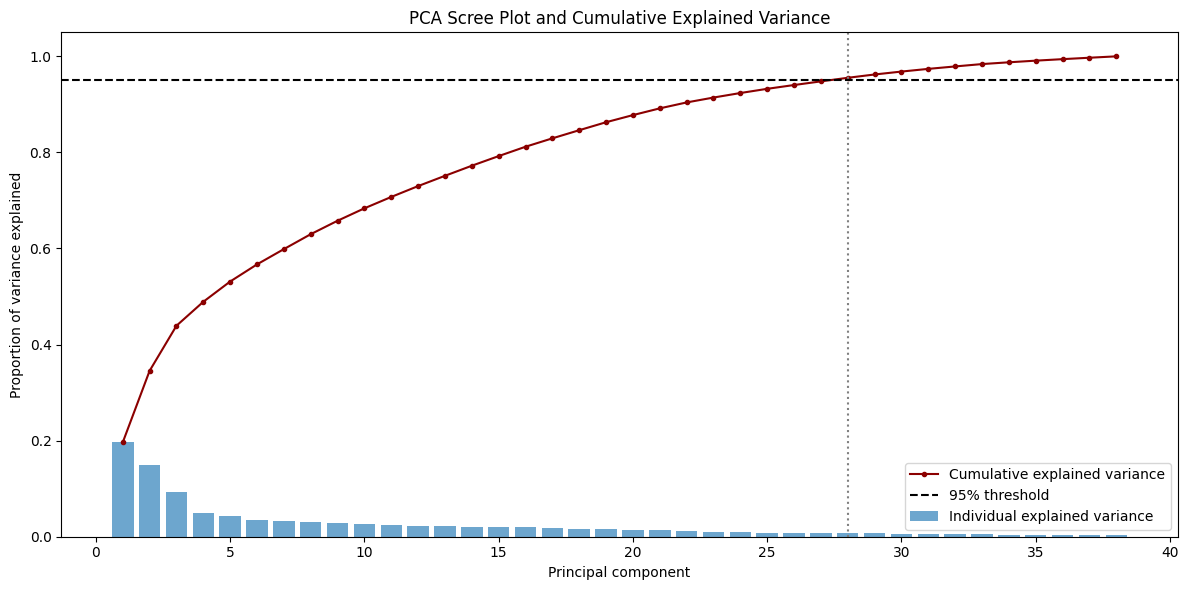

Components required for 95% variance: 28 of 38


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.196458,0.196458
1,2,0.148945,0.345403
2,3,0.093799,0.439202
3,4,0.049919,0.489120
4,5,0.042158,0.531278
5,6,0.035666,0.566945
6,7,0.031758,0.598703
7,8,0.031066,0.629769
8,9,0.028022,0.657792
9,10,0.025869,0.683660


In [39]:
# Create a scaler so every feature contributes to PCA on a comparable scale.
pca_scaler = StandardScaler() # each feature has mean 0 and sd 1
train_pca_scaled = pca_scaler.fit_transform(
    X_train_raw[pca_feature_columns] # fit and transform
)
validation_pca_scaled = pca_scaler.transform(
    X_validation_raw[pca_feature_columns] # transform only
)
test_pca_scaled = pca_scaler.transform(
    X_test_raw[pca_feature_columns] # transform only
)

# Create an unrestricted PCA to inspect the variance explained by every component.
pca_diagnostic = PCA()

# fit PCA on training data
pca_diagnostic.fit(train_pca_scaled)

# Extract the proportion of training variance explained by each component.
explained_variance_ratio = pca_diagnostic.explained_variance_ratio_

# Calculate the total variance explained as components are added.
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Find the smallest number of components reaching the variance threshold.
components_for_threshold = int(
    np.searchsorted(
        cumulative_explained_variance, PCA_VARIANCE_THRESHOLD
    ) + 1
)
pca_variance_summary = pd.DataFrame({
    "component": np.arange(1, len(explained_variance_ratio) + 1),
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_explained_variance": cumulative_explained_variance,
})

fig, axis = plt.subplots(figsize=(12, 6))
axis.bar(
    pca_variance_summary["component"],
    pca_variance_summary["explained_variance_ratio"],
    alpha=0.65,
    label="Individual explained variance",
)
axis.plot(
    pca_variance_summary["component"],
    pca_variance_summary["cumulative_explained_variance"],
    color="darkred",
    marker="o",
    markersize=3,
    label="Cumulative explained variance",
)
axis.axhline(
    PCA_VARIANCE_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"{PCA_VARIANCE_THRESHOLD:.0%} threshold",
)
axis.axvline(components_for_threshold, color="grey", linestyle=":")
axis.set_xlabel("Principal component")
axis.set_ylabel("Proportion of variance explained")
axis.set_ylim(0, 1.05)
axis.set_title("PCA Scree Plot and Cumulative Explained Variance")
axis.legend()
plt.tight_layout()
plt.show()

print(
    f"Components required for {PCA_VARIANCE_THRESHOLD:.0%} variance: "
    f"{components_for_threshold} of {len(pca_feature_columns)}"
)
pca_variance_summary


In [40]:
# Create PCA that retains enough components to explain the target variance.
pca_model = PCA(
    n_components=PCA_VARIANCE_THRESHOLD,
    svd_solver="full",
)
# Learn PCA directions from scaled training data and project training rows onto them.
train_pca_values = pca_model.fit_transform(train_pca_scaled)

# Project validation data onto the training-fitted PCA directions.
validation_pca_values = pca_model.transform(validation_pca_scaled)

# Project test data onto the same training-fitted PCA directions.
test_pca_values = pca_model.transform(test_pca_scaled)

# Generate component names
principal_component_columns = [
    f"PC{component_number}"
    for component_number in range(1, pca_model.n_components_ + 1)
]

# convert components into dataframes
train_pca_df = pd.DataFrame(
    train_pca_values,
    columns=principal_component_columns,
    index=train_df.index,
)
validation_pca_df = pd.DataFrame(
    validation_pca_values,
    columns=principal_component_columns,
    index=validation_df.index,
)
test_pca_df = pd.DataFrame(
    test_pca_values,
    columns=principal_component_columns,
    index=test_df.index,
)

# combine compressed PCA components with context features
X_train_pca = pd.concat([
    train_pca_df,
    X_train_raw[pca_context_columns],
], axis=1)
X_validation_pca = pd.concat([
    validation_pca_df,
    X_validation_raw[pca_context_columns],
], axis=1)
X_test_pca = pd.concat([
    test_pca_df,
    X_test_raw[pca_context_columns],
], axis=1)

# Define possible PCA component counts for validation-based model selection.
candidate_component_options = [
    3, 5, 8, 10, 12, 14, 17, 24, pca_model.n_components_
]
# Keep valid component counts, remove duplicates and sort them.
component_options = sorted({
    option for option in candidate_component_options
    if option <= pca_model.n_components_
})

pca_dataset_summary = pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "rows": [len(X_train_pca), len(X_validation_pca), len(X_test_pca)],
    "principal_components": [pca_model.n_components_] * 3,
    "context_features": [len(pca_context_columns)] * 3,
    "total_model_features": [
        X_train_pca.shape[1],
        X_validation_pca.shape[1],
        X_test_pca.shape[1],
    ],
})

print(f"Retained variance: {pca_model.explained_variance_ratio_.sum():.2%}")
print(f"Validation component grid: {component_options}")
pca_dataset_summary


Retained variance: 95.53%
Validation component grid: [3, 5, 8, 10, 12, 14, 17, 24, 28]


,dataset,rows,principal_components,context_features,total_model_features
0,Train,3116,28,13,41
1,Validation,677,28,13,41
2,Test,659,28,13,41


# 8. Random Forest Goals Predictor

This tunes a random forest to predict home goals and away goals for any given fixture. 

Given that PCA isn't required for random forests we compare:

- PCA features versus raw features.
- Different PCA component counts.
- Different tree depths.
- Different minimum leaf sizes.

Best model is selected on validation performance.

In [41]:
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
RANDOM_FOREST_ESTIMATORS = 200 # number of trees in each candidate forest

# Define candidate tree-complexity settings for validation.
forest_parameter_options = [
    {"max_depth": 6, "min_samples_leaf": 5},
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 10},
    {"max_depth": None, "min_samples_leaf": 10},
    {"max_depth": None, "min_samples_leaf": 20},
]

# Store train, validation and test features for the PCA and raw representations.
feature_representations = {
    "PCA": {
        "train": X_train_pca,
        "validation": X_validation_pca,
        "test": X_test_pca,
    },
    "Raw": {
        "train": X_train_raw,
        "validation": X_validation_raw,
        "test": X_test_raw,
    },
}

# Returns the feature columns used for a selected representation and PCA size.
def columns_for_representation(representation, component_count=None):
    if representation == "PCA":
        return (
            principal_component_columns[:component_count]
            + pca_context_columns
        )
    return raw_feature_columns

# Store validation metrics for every tested random-forest configuration.
random_forest_goal_validation_rows = []

# Store the current best model and its configuration.
best_goal_candidate = None

# Initialise the best metric tuple so the first valid candidate will replace it.
best_goal_rank = (np.inf, np.inf, np.inf)

# Compare compressed PCA features with the full raw feature set.
for representation in ("PCA", "Raw"):
    # Test multiple component counts for PCA
    representation_component_options = (
        component_options if representation == "PCA" else [None]
    )
    for component_count in representation_component_options:
        # Select the requested PCA components and context features, or all raw features.
        selected_columns = columns_for_representation(
            representation, component_count
        )
        X_representation = feature_representations[representation]  # Retrieve train, validation and test data for the current representation.

        # Fit one candidate forest for each tree-complexity setting.
        for parameters in forest_parameter_options:
            
            # Construct a candidate multi-output random forest.
            model = RandomForestRegressor(
                n_estimators=RANDOM_FOREST_ESTIMATORS,
                max_depth=parameters["max_depth"],
                min_samples_leaf=parameters["min_samples_leaf"],
                max_features="sqrt",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            # Fit the candidate using training features and home/away goal targets.
            model.fit(
                X_representation["train"][selected_columns], 
                y_train,
            )
            # Generate home and away expected-goal predictions for validation fixtures.
            validation_predictions = model.predict(
                X_representation["validation"][selected_columns]
            )
            # Evaluate goal errors and result accuracy on the validation period.
            metrics = evaluate_goal_predictions(
                y_validation, validation_predictions
            )
            # Record the candidate configuration and its validation metrics.
            row = {
                "model": "Random Forest",
                "representation": representation,
                "components_or_raw": (
                    component_count
                    if representation == "PCA"
                    else "Raw"
                ),
                "max_depth": parameters["max_depth"],
                "min_samples_leaf": parameters["min_samples_leaf"],
                **metrics,
            }
            random_forest_goal_validation_rows.append(row)

            # Rank candidates by Poisson deviance, using MAE and RMSE as tie-breakers.
            candidate_rank = (
                metrics["mean_poisson_deviance"],
                metrics["mae_overall"],
                metrics["rmse_overall"],
            )

            # Retain the model when it improves the ordered validation criteria.
            if candidate_rank < best_goal_rank:
                best_goal_rank = candidate_rank
                best_goal_candidate = {
                    "model": model,
                    "representation": representation,
                    "component_count": component_count,
                    "columns": selected_columns,
                    "parameters": parameters,
                }

# Convert all candidate results into a ranked validation table.
random_forest_goal_validation_results = (
    pd.DataFrame(random_forest_goal_validation_rows)
    .sort_values([
        "mean_poisson_deviance", "mae_overall", "rmse_overall"
    ])
    .reset_index(drop=True)
)
random_forest_goal_validation_results



,model,representation,components_or_raw,max_depth,min_samples_leaf,mae_home,mae_away,mae_overall,rmse_home,rmse_away,rmse_overall,mean_poisson_deviance,result_accuracy,result_balanced_accuracy,draw_recall,rounded_score_accuracy
0,Random Forest,Raw,Raw,15.0,5,0.976111,0.821628,0.898870,1.271736,1.059402,1.165569,1.173616,0.545052,0.464469,0.0,0.115214
1,Random Forest,Raw,Raw,15.0,10,0.976221,0.820383,0.898302,1.278196,1.056440,1.167318,1.173845,0.536189,0.454290,0.0,0.112260
2,Random Forest,Raw,Raw,NaN,10,0.981481,0.817873,0.899677,1.282853,1.054135,1.168494,1.174772,0.540620,0.459005,0.0,0.115214
3,Random Forest,Raw,Raw,10.0,5,0.982569,0.822353,0.902461,1.276263,1.058544,1.167404,1.176790,0.536189,0.452041,0.0,0.115214
4,Random Forest,Raw,Raw,NaN,20,0.974934,0.823157,0.899046,1.277216,1.060854,1.169035,1.179447,0.539143,0.457183,0.0,0.112260
5,Random Forest,Raw,Raw,6.0,5,0.991030,0.818787,0.904909,1.286950,1.063835,1.175393,1.192684,0.524372,0.435220,0.0,0.116691
6,Random Forest,PCA,24,NaN,10,1.005570,0.822654,0.914112,1.303107,1.060069,1.181588,1.201457,0.536189,0.449792,0.0,0.106352
7,Random Forest,PCA,24,15.0,5,1.004187,0.824649,0.914418,1.304280,1.058964,1.181622,1.201510,0.533235,0.446898,0.0,0.103397
8,Random Forest,PCA,24,15.0,10,1.005650,0.822639,0.914145,1.304298,1.059643,1.181971,1.201964,0.539143,0.451935,0.0,0.110783
9,Random Forest,PCA,24,10.0,5,1.007990,0.825067,0.916528,1.304256,1.063787,1.184022,1.206323,0.528804,0.441434,0.0,0.106352


In [42]:
# Retrieve the training-fitted random forest selected by validation performance.
best_random_forest_goal_model = best_goal_candidate["model"]

# Retrieve whether the selected model uses PCA or raw features.
best_goal_representation = best_goal_candidate["representation"]

# Retrieve the exact feature columns used by the selected model.
best_goal_columns = best_goal_candidate["columns"]

# Retrieve train, validation and test features for the selected representation.
best_goal_feature_sets = feature_representations[best_goal_representation]

# Store the home and away goal predictions for each split.
random_forest_goal_predictions = {}

# Store one evaluation-summary row for each split.
random_forest_goal_split_rows = []

# Generate and evaluate predictions separately for train, validation and test.
for split_name, split_key, targets in [
    ("Train", "train", y_train),
    ("Validation", "validation", y_validation),
    ("Test", "test", y_test),
]:
    # Predict home and away goals using the selected feature columns.
    predictions = np.clip(
        best_random_forest_goal_model.predict(
            best_goal_feature_sets[split_key][best_goal_columns]
        ),
        0,
        None,
    )

    # Save the predictions so they can be reused without rerunning the model.
    random_forest_goal_predictions[split_name] = predictions

    # Record the selected configuration and evaluation metrics for this split.
    random_forest_goal_split_rows.append({
        "model": "Random Forest",
        "split": split_name,
        "components_or_raw": (
            best_goal_candidate["component_count"]
            if best_goal_representation == "PCA"
            else "Raw"
        ),
        "max_depth": best_goal_candidate["parameters"]["max_depth"],
        "min_samples_leaf": best_goal_candidate[
            "parameters"
        ]["min_samples_leaf"],
        **evaluate_goal_predictions(targets, predictions),
    })

# Combine split-level metric dictionaries into a comparison table.
random_forest_goal_split_metrics = pd.DataFrame(
    random_forest_goal_split_rows
)

random_forest_test_predictions = test_df[[
    "fixture_id", "date", "home_team", "away_team",
    "goals_home", "goals_away",
]].copy()
random_forest_test_predictions["expected_home_goals"] = (
    random_forest_goal_predictions["Test"][:, 0]
)
random_forest_test_predictions["expected_away_goals"] = (
    random_forest_goal_predictions["Test"][:, 1]
)

print(f"Selected representation: {best_goal_representation}")
random_forest_goal_split_metrics


Selected representation: Raw


,model,split,components_or_raw,max_depth,min_samples_leaf,mae_home,mae_away,mae_overall,rmse_home,rmse_away,rmse_overall,mean_poisson_deviance,result_accuracy,result_balanced_accuracy,draw_recall,rounded_score_accuracy
0,Random Forest,Train,Raw,15,5,0.710984,0.627146,0.669065,0.961367,0.804567,0.882967,0.741714,0.678755,0.580880,0.0,0.182927
1,Random Forest,Validation,Raw,15,5,0.976111,0.821628,0.898870,1.271736,1.059402,1.165569,1.173616,0.545052,0.464469,0.0,0.115214
2,Random Forest,Test,Raw,15,5,1.066513,0.883022,0.974767,1.398245,1.184295,1.291270,1.225896,0.637329,0.519679,0.0,0.098634


In [43]:
# Import permutation importance, which measures how much model performance
# worsens when one feature is randomly shuffled.
from sklearn.inspection import permutation_importance


# Calculate feature importance using the validation dataset.
goal_permutation_result = permutation_importance(

    # Use the already fitted random-forest model selected during validation.
    best_random_forest_goal_model,

    # Supply the validation version of the selected feature representation
    # and retain the exact columns used to train the selected model.
    best_goal_feature_sets["validation"][
        best_goal_columns
    ],

    # Actual home and away goal totals for the validation fixtures.
    y_validation,

    # Evaluate the model using negative mean absolute error.
    # Scikit-learn expects larger scores to be better, so MAE is negated.
    scoring="neg_mean_absolute_error",

    # Shuffle each feature five times to reduce dependence on one random shuffle.
    n_repeats=5,

    # Make the random shuffling reproducible.
    random_state=RANDOM_STATE,

    # Use all available CPU cores.
    n_jobs=-1,
)


# Convert the permutation-importance results into a labelled DataFrame.
random_forest_goal_permutation_importance = (

    pd.DataFrame({

        # Name of each feature supplied to the selected model.
        "feature": best_goal_columns,

        # Average reduction in validation score after shuffling the feature.
        # Larger positive values indicate more important features.
        "permutation_importance_mean":
            goal_permutation_result.importances_mean,

        # Standard deviation across the five shuffles.
        # Larger values indicate less stable importance estimates.
        "permutation_importance_std":
            goal_permutation_result.importances_std,
    })

    # Rank features from most important to least important.
    .sort_values(
        "permutation_importance_mean",
        ascending=False,
    )

    # Replace the old row index with a clean sequential index.
    .reset_index(drop=True)
)


# Display the 25 features with the highest mean permutation importance.
random_forest_goal_permutation_importance.head(25)

,feature,permutation_importance_mean,permutation_importance_std
0,home_elo,0.038580,0.006212
1,away_elo,0.038421,0.007262
2,home_gap_attack,0.014251,0.003586
3,home_elo_matches,0.010664,0.002414
4,away_gap_attack,0.009176,0.002415
5,home_gap_defence,0.006572,0.002530
6,away_gap_defence,0.004789,0.001158
7,home_gap_matches,0.004566,0.001463
8,home_rolling_5_goals_for,0.001704,0.000274
9,away_rolling_5_shots_on_target_against,0.001580,0.000855


# 9. Converting Expected Goals into Score Probabilities

The model predicts an expected number of goals for each team rather than one exact score. A Poisson distribution converts this expected value into probabilities for each possible number of goals.

The probability of a team scoring exactly $k$ goals is:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}
$$

where:

- $X$ is the number of goals scored;
- $k$ is a possible goal total, such as 0, 1, 2, or 3;
- $\lambda$ is the expected number of goals predicted by the model;
- $e$ is Euler's number;
- $k!$ is the factorial of $k$.

For example, if the model predicts 1.5 expected goals for the home team, then $\lambda=1.5$.

$$
P(X=0)=e^{-1.5}\approx 0.223
$$

$$
P(X=1)=e^{-1.5}(1.5)\approx 0.335
$$

$$
P(X=2)=\frac{e^{-1.5}(1.5)^2}{2!}\approx 0.251
$$

Therefore, the home team has approximately:

- a 22.3% probability of scoring no goals;
- a 33.5% probability of scoring exactly one goal;
- a 25.1% probability of scoring exactly two goals.

The same calculation is performed for the away team. The two probability distributions are multiplied together to estimate every exact scoreline. For example:

$$
P(2\text{-}1)
=
P(\text{home scores 2})
\times
P(\text{away scores 1})
$$

The exact-score probabilities are then combined to calculate the probabilities of a home win, draw, away win, and over or under 2.5 total goals.

In [44]:
from scipy.stats import poisson

MAX_SCORELINE_GOALS = 10 # Model scorelines from 0–0 through 10–10.

# Convert expected home and away goals into a joint exact-score matrix.
def scoreline_probability_matrix(
    lambda_home, lambda_away, max_goals=MAX_SCORELINE_GOALS
):
    home_goal_values = np.arange(max_goals + 1)
    away_goal_values = np.arange(max_goals + 1)

    # Calculate the probability of the home team scoring each goal total.
    home_probabilities = poisson.pmf(
        home_goal_values, max(float(lambda_home), 0.01)
    )
    # Calculate the probability of the away team scoring each goal total.
    away_probabilities = poisson.pmf(
        away_goal_values, max(float(lambda_away), 0.01)
    )
    # Multiply every home-goal probability by every away-goal probability.
    matrix = np.outer(home_probabilities, away_probabilities)
    return matrix / matrix.sum() # Renormalize the truncated matrix so all represented scorelines sum to one.

# Aggregate exact-score probabilities into result and total-goal markets.
def result_probabilities_from_score_matrix(matrix):
    home_win_probability = np.tril(matrix, k=-1).sum()
    draw_probability = np.trace(matrix)
    away_win_probability = np.triu(matrix, k=1).sum()
    # Create a matrix containing the total goals for every exact scoreline.
    total_goal_values = np.add.outer(
        np.arange(matrix.shape[0]), np.arange(matrix.shape[1])
    )
    under_2_5_probability = matrix[total_goal_values <= 2].sum()
    over_2_5_probability = matrix[total_goal_values >= 3].sum()
    return {
        "probability_home_win": home_win_probability,
        "probability_draw": draw_probability,
        "probability_away_win": away_win_probability,
        "probability_home_or_draw": (
            home_win_probability + draw_probability
        ),
        "probability_away_or_draw": (
            away_win_probability + draw_probability
        ),
        "probability_home_or_away": (
            home_win_probability + away_win_probability
        ),
        "probability_under_2_5_goals": under_2_5_probability,
        "probability_over_2_5_goals": over_2_5_probability,
    }

# Convert multiple home/away expected-goal predictions into probability rows.
def scoreline_probabilities_from_goal_predictions(
    predictions, index=None, keep_matrices=True
):
    probability_rows = []
    matrices = []
    for lambda_home, lambda_away in np.asarray(predictions):
        # Build an exact-score matrix using non-negative expected-goal values.
        matrix = scoreline_probability_matrix(
            np.clip(lambda_home, 0.01, None),
            np.clip(lambda_away, 0.01, None),
        )
        probabilities = result_probabilities_from_score_matrix(matrix)
        # Locate the exact scoreline with the highest individual probability.
        modal_home, modal_away = np.unravel_index(
            np.argmax(matrix), matrix.shape
        )
        probabilities.update({
            "modal_home_goals": modal_home,
            "modal_away_goals": modal_away,
            "modal_score_probability": matrix[modal_home, modal_away],
        })
        probability_rows.append(probabilities)
        if keep_matrices:
            matrices.append(matrix)

    # Convert fixture probability dictionaries into an indexed DataFrame.
    probability_frame = pd.DataFrame(probability_rows, index=index)
    assert np.allclose(
        probability_frame[[
            "probability_home_win",
            "probability_draw",
            "probability_away_win",
        ]].sum(axis=1),
        1.0,
    )
    if keep_matrices:
        assert all(np.isclose(matrix.sum(), 1.0) for matrix in matrices)
    assert np.allclose(
        probability_frame[[
            "probability_under_2_5_goals",
            "probability_over_2_5_goals",
        ]].sum(axis=1),
        1.0,
    )
    return probability_frame, matrices


# Explicit orientation tests: row > column is a home win.
home_orientation_matrix = np.zeros((2, 2))
home_orientation_matrix[1, 0] = 1.0
away_orientation_matrix = np.zeros((2, 2))
away_orientation_matrix[0, 1] = 1.0
assert (
    result_probabilities_from_score_matrix(
        home_orientation_matrix
    )["probability_home_win"] == 1.0
)
assert (
    result_probabilities_from_score_matrix(
        away_orientation_matrix
    )["probability_away_win"] == 1.0
)

random_forest_scoreline_probabilities = {}
random_forest_scoreline_matrices = {}
random_forest_probability_metric_rows = []
for split_name, targets, results in [
    ("Train", y_train, y_train_result),
    ("Validation", y_validation, y_validation_result),
    ("Test", y_test, y_test_result),
]:
    probability_frame, matrices = (
        scoreline_probabilities_from_goal_predictions(
            random_forest_goal_predictions[split_name],
            index=results.index,
        )
    )
    random_forest_scoreline_probabilities[split_name] = probability_frame
    random_forest_scoreline_matrices[split_name] = matrices
    random_forest_probability_metric_rows.append({
        "model": "Random Forest goals + Poisson",
        "split": split_name,
        **evaluate_result_probabilities(results, probability_frame),
    })

random_forest_probability_metrics = pd.DataFrame(
    random_forest_probability_metric_rows
)

elo_scoreline_probabilities = {}
elo_scoreline_matrices = {}
elo_probability_metric_rows = []
for split_name, targets, results in [
    ("Train", y_train, y_train_result),
    ("Validation", y_validation, y_validation_result),
    ("Test", y_test, y_test_result),
]:
    predictions = baseline_goal_predictions[(
        "Elo-only expected goals", split_name
    )]
    probability_frame, matrices = (
        scoreline_probabilities_from_goal_predictions(
            predictions, index=results.index
        )
    )
    elo_scoreline_probabilities[split_name] = probability_frame
    elo_scoreline_matrices[split_name] = matrices
    elo_probability_metric_rows.append({
        "model": "Elo-only goals + Poisson",
        "split": split_name,
        **evaluate_result_probabilities(results, probability_frame),
    })

elo_probability_metrics = pd.DataFrame(elo_probability_metric_rows)
display(elo_probability_metrics)
random_forest_probability_metrics


,model,split,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall,brier_home_or_draw,brier_away_or_draw,brier_home_or_away
0,Elo-only goals + Poisson,Train,0.880932,0.518197,0.599166,0.511489,0.0,0.154726,0.187824,0.175646
1,Elo-only goals + Poisson,Validation,0.945459,0.563428,0.562777,0.495323,0.0,0.165637,0.200199,0.197592
2,Elo-only goals + Poisson,Test,0.806455,0.469296,0.641882,0.531344,0.0,0.135195,0.167904,0.166197


,model,split,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall,brier_home_or_draw,brier_away_or_draw,brier_home_or_away
0,Random Forest goals + Poisson,Train,0.737007,0.420051,0.681964,0.585502,0.014946,0.116251,0.141101,0.162699
1,Random Forest goals + Poisson,Validation,0.955632,0.570112,0.545052,0.464469,0.000000,0.167985,0.204739,0.197388
2,Random Forest goals + Poisson,Test,0.832086,0.483199,0.637329,0.519679,0.000000,0.139820,0.176876,0.166503


## 10. Histogram Gradient-Boosted Poisson Goal Models

This section uses scikit-learn's histogram gradient boosting, a tree-based method similar to LightGBM that requires no additional installation.

Separate models predict expected home and away goals using the engineered pre-match features. Poisson loss is used because goals are non-negative count values.

The models build trees sequentially, with each tree correcting errors made by the previous trees. Different learning rates, tree sizes, leaf sizes and numbers of iterations are tested.

Models are fitted on the training period and selected using the chronological validation period. The best model minimizes Poisson deviance, with MAE and RMSE used as tie-breakers.

The resulting expected goals are later converted into exact-score and match-result probabilities using Poisson distributions.

In [45]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Define candidate boosting configurations for validation-based selection.
boosted_parameter_options = [
    {
        "learning_rate": 0.03,
        "max_iter": 300,
        "max_leaf_nodes": 7,
        "min_samples_leaf": 20,
        "l2_regularization": 5.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 500,
        "max_leaf_nodes": 7,
        "min_samples_leaf": 20,
        "l2_regularization": 5.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 5.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 30,
        "l2_regularization": 10.0,
    },
]

# Store validation metrics for every tested parameter configuration.
boosted_validation_rows = []
# Store the best fitted home and away models.
best_boosted_candidate = None
# Initialise the best metric tuple so the first candidate replaces it.
best_boosted_rank = (np.inf, np.inf, np.inf)

# Fit and evaluate one home/away model pair for each configuration.
for parameters in boosted_parameter_options:
    # Create a Poisson boosting model for home goals.
    home_model = HistGradientBoostingRegressor(
        loss="poisson",
        early_stopping=False,
        random_state=RANDOM_STATE,
        **parameters,
    )
    # Create a separate Poisson boosting model for away goals.
    away_model = HistGradientBoostingRegressor(
        loss="poisson",
        early_stopping=False,
        random_state=RANDOM_STATE + 1,
        **parameters,
    )
    # Fit the home model using training features and actual home goals.
    home_model.fit(X_train_raw, y_train["goals_home"])
    # Fit the away model using the same training features and away-goal targets.
    away_model.fit(X_train_raw, y_train["goals_away"])
    # Combine home and away validation predictions into a two-column array.
    validation_predictions = np.column_stack([
        home_model.predict(X_validation_raw),
        away_model.predict(X_validation_raw),
    ])
    # Enforce strictly positive expected goals for Poisson evaluation.
    validation_predictions = np.clip(validation_predictions, 0.01, None)
    # Evaluate validation goal errors and derived result predictions.
    metrics = evaluate_goal_predictions(
        y_validation, validation_predictions
    )
    # Record the candidate parameters and validation metrics.
    boosted_validation_rows.append({
        "model": "Histogram Gradient Boosting",
        **parameters,
        **metrics,
    })
    # Rank by Poisson deviance, then MAE and RMSE as tie-breakers.
    candidate_rank = (
        metrics["mean_poisson_deviance"],
        metrics["mae_overall"],
        metrics["rmse_overall"],
    )
    # Retain the fitted model pair if it improves validation performance.
    if candidate_rank < best_boosted_rank:
        best_boosted_rank = candidate_rank
        best_boosted_candidate = {
            "home_model": home_model,
            "away_model": away_model,
            "parameters": parameters,
        }

# Convert candidate results into a table ranked by validation performance.
boosted_validation_results = (
    pd.DataFrame(boosted_validation_rows)
    .sort_values([
        "mean_poisson_deviance", "mae_overall", "rmse_overall"
    ])
    .reset_index(drop=True)
)
boosted_validation_results


,model,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mae_home,mae_away,mae_overall,rmse_home,rmse_away,rmse_overall,mean_poisson_deviance,result_accuracy,result_balanced_accuracy,draw_recall,rounded_score_accuracy
0,Histogram Gradient Boosting,0.03,300,7,20,5.0,0.968255,0.824093,0.896174,1.259470,1.061102,1.160286,1.158181,0.556869,0.484289,0.0,0.127031
1,Histogram Gradient Boosting,0.03,500,7,20,5.0,0.978796,0.827098,0.902947,1.274852,1.066557,1.170705,1.173411,0.548006,0.477108,0.0,0.110783
2,Histogram Gradient Boosting,0.03,400,15,20,5.0,0.982918,0.822341,0.902630,1.282988,1.062682,1.172835,1.184279,0.540620,0.472499,0.0,0.122600
3,Histogram Gradient Boosting,0.05,300,15,30,10.0,0.994911,0.821228,0.908070,1.303394,1.060918,1.182156,1.199776,0.540620,0.471749,0.0,0.110783


In [46]:
# Retrieve the validation-selected model for home goals.
best_boosted_home_model = best_boosted_candidate["home_model"]
# Retrieve the validation-selected model for away goals.
best_boosted_away_model = best_boosted_candidate["away_model"]

boosted_goal_predictions = {}
boosted_goal_metric_rows = []
boosted_scoreline_probabilities = {}
boosted_scoreline_matrices = {}
boosted_probability_metric_rows = []

# Generate and evaluate predictions for train, validation and test data.
for split_name, features, targets, results in [
    ("Train", X_train_raw, y_train, y_train_result),
    ("Validation", X_validation_raw, y_validation, y_validation_result),
    ("Test", X_test_raw, y_test, y_test_result),
]:
    # Combine separate home-goal and away-goal predictions into one array.
    predictions = np.column_stack([
        best_boosted_home_model.predict(features),
        best_boosted_away_model.predict(features),
    ])
    # Enforce positive Poisson means without preventing zero observed goals.
    predictions = np.clip(predictions, 0.01, None)
    # Save expected-goal predictions for later inspection and comparison.
    boosted_goal_predictions[split_name] = predictions
    # Record the selected parameters and goal-prediction metrics for this split.
    boosted_goal_metric_rows.append({
        "model": "Histogram Gradient Boosting",
        "split": split_name,
        **best_boosted_candidate["parameters"],
        **evaluate_goal_predictions(targets, predictions),
    })

    # Convert expected goals into exact-score and match-result probabilities.
    probability_frame, matrices = (
        scoreline_probabilities_from_goal_predictions(
            predictions, index=results.index
        )
    )
    # Store the summarized result probabilities for each fixture.
    boosted_scoreline_probabilities[split_name] = probability_frame
    # Store each fixture's full exact-score probability matrix.
    boosted_scoreline_matrices[split_name] = matrices
    # Evaluate the result probabilities derived from the goal models.
    boosted_probability_metric_rows.append({
        "model": "Boosted Poisson goals + score matrix",
        "split": split_name,
        **evaluate_result_probabilities(results, probability_frame),
    })

# Combine split-level result-probability metrics into one table.
boosted_goal_split_metrics = pd.DataFrame(boosted_goal_metric_rows)
boosted_probability_metrics = pd.DataFrame(
    boosted_probability_metric_rows
)
display(boosted_goal_split_metrics)
boosted_probability_metrics


,model,split,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mae_home,mae_away,mae_overall,rmse_home,rmse_away,rmse_overall,mean_poisson_deviance,result_accuracy,result_balanced_accuracy,draw_recall,rounded_score_accuracy
0,Histogram Gradient Boosting,Train,0.03,300,7,20,5.0,0.841187,0.716711,0.778949,1.105162,0.911641,1.008402,0.919653,0.632542,0.538733,0.0,0.146341
1,Histogram Gradient Boosting,Validation,0.03,300,7,20,5.0,0.968255,0.824093,0.896174,1.259470,1.061102,1.160286,1.158181,0.556869,0.484289,0.0,0.127031
2,Histogram Gradient Boosting,Test,0.03,300,7,20,5.0,1.047164,0.892541,0.969853,1.379061,1.189826,1.284444,1.215037,0.643399,0.529234,0.0,0.098634


,model,split,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall,brier_home_or_draw,brier_away_or_draw,brier_home_or_away
0,Boosted Poisson goals + score matrix,Train,0.805988,0.470785,0.635109,0.542356,0.01087,0.135024,0.166387,0.169374
1,Boosted Poisson goals + score matrix,Validation,0.948226,0.563781,0.553914,0.481396,0.00000,0.165306,0.200264,0.198211
2,Boosted Poisson goals + score matrix,Test,0.821381,0.478603,0.643399,0.529234,0.00000,0.137894,0.173774,0.166935


## 11. Direct Random Forest Result Classifier

This section uses a random forest to predict a home win, draw or away win directly from the pre-match features.

Models using both raw and PCA features are tested, along with different tree settings and optional class balancing. The models are fitted on the training data and compared using chronological validation log loss.

This classifier is retained as a benchmark. The preferred approach predicts goals first and then converts them into result probabilities using Poisson scoreline matrices.

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Define candidate tree-depth and leaf-size settings.
classifier_parameter_options = [
    {"max_depth": 6, "min_samples_leaf": 5},
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 5},
    {"max_depth": 15, "min_samples_leaf": 10},
    {"max_depth": None, "min_samples_leaf": 10},
    {"max_depth": None, "min_samples_leaf": 20},
]
# Compare ordinary training with class balancing inside each tree sample.
classifier_class_weights = [None, "balanced_subsample"]

# Convert classifier probabilities into consistently ordered, named columns.
def classifier_probability_frame(model, features, index):
    raw_probabilities = model.predict_proba(features)
    class_frame = pd.DataFrame(
        raw_probabilities,
        columns=model.classes_,
        index=index,
    ).reindex(columns=RESULT_CLASS_ORDER)
    return class_frame.rename(columns=RESULT_PROBABILITY_COLUMNS)

# Store all validation results and track the best candidate.
classifier_validation_rows = []
best_classifier_candidate = None
best_classifier_rank = (np.inf, np.inf)

# Compare compressed PCA features with the full raw feature set.
for representation in ("PCA", "Raw"):
    representation_component_options = (
        component_options if representation == "PCA" else [None]
    )
    for component_count in representation_component_options:
        # Select the requested PCA components and context columns, or all raw columns.
        selected_columns = columns_for_representation(
            representation, component_count
        )
        X_representation = feature_representations[representation]

        # Test each tree configuration with and without class balancing.
        for parameters in classifier_parameter_options:
            for class_weight in classifier_class_weights:
                # Construct a candidate random forest result classifier.
                model = RandomForestClassifier(
                    n_estimators=RANDOM_FOREST_ESTIMATORS,
                    max_depth=parameters["max_depth"],
                    min_samples_leaf=parameters["min_samples_leaf"],
                    max_features="sqrt",
                    class_weight=class_weight,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )
                # Fit the classifier using training features and result labels.
                model.fit(
                    X_representation["train"][selected_columns],
                    y_train_result,
                )
                # Predict validation probabilities and standardize their column order.
                validation_probability_frame = (
                    classifier_probability_frame(
                        model,
                        X_representation["validation"][selected_columns],
                        y_validation_result.index,
                    )
                )
                # Evaluate probability quality and derived result classifications.
                metrics = evaluate_result_probabilities(
                    y_validation_result, validation_probability_frame
                )
                # Record the configuration and validation metrics.
                classifier_validation_rows.append({
                    "model": "Random Forest classifier",
                    "representation": representation,
                    "components_or_raw": (
                        component_count
                        if representation == "PCA"
                        else "Raw"
                    ),
                    "max_depth": parameters["max_depth"],
                    "min_samples_leaf": parameters["min_samples_leaf"],
                    "class_weight": str(class_weight),
                    **metrics,
                })
                # Rank candidates by log loss, using Brier score as a tie-breaker.
                candidate_rank = (
                    metrics["log_loss"], metrics["brier_score"]
                )
                # Retain the candidate when it improves validation probability performance.
                if candidate_rank < best_classifier_rank:
                    best_classifier_rank = candidate_rank
                    best_classifier_candidate = {
                        "model": model,
                        "representation": representation,
                        "component_count": component_count,
                        "columns": selected_columns,
                        "parameters": parameters,
                        "class_weight": class_weight,
                    }
# Rank all candidates from best to worst validation performance.
classifier_validation_results = (
    pd.DataFrame(classifier_validation_rows)
    .sort_values(["log_loss", "brier_score"])
    .reset_index(drop=True)
)
classifier_validation_results


,model,representation,components_or_raw,max_depth,min_samples_leaf,class_weight,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall
0,Random Forest classifier,Raw,Raw,NaN,10,None,0.956144,0.569360,0.540620,0.460504,0.016393
1,Random Forest classifier,Raw,Raw,15.0,10,None,0.958578,0.570651,0.540620,0.461254,0.016393
2,Random Forest classifier,Raw,Raw,10.0,5,None,0.960398,0.572036,0.545052,0.468218,0.016393
3,Random Forest classifier,Raw,Raw,NaN,20,None,0.961103,0.571985,0.548006,0.465113,0.005464
4,Random Forest classifier,Raw,Raw,15.0,5,None,0.963957,0.573427,0.546529,0.468540,0.027322
...,...,...,...,...,...,...,...,...,...,...,...
115,Random Forest classifier,PCA,28,6.0,5,balanced_subsample,0.995509,0.596604,0.518464,0.462419,0.147541
116,Random Forest classifier,PCA,24,6.0,5,balanced_subsample,0.996492,0.597803,0.512555,0.469377,0.180328
117,Random Forest classifier,PCA,14,6.0,5,balanced_subsample,0.997264,0.597670,0.499261,0.454483,0.191257
118,Random Forest classifier,PCA,17,6.0,5,balanced_subsample,0.999545,0.599789,0.511078,0.463807,0.196721


In [48]:
# Retrieve the training-fitted classifier selected using validation performance.
best_result_classifier = best_classifier_candidate["model"]
# Retrieve whether the selected model uses PCA or raw features.
best_classifier_representation = best_classifier_candidate["representation"]
# Retrieve the exact feature columns used to train the selected classifier.
best_classifier_columns = best_classifier_candidate["columns"]
# Retrieve train, validation and test features for the selected representation.
best_classifier_feature_sets = feature_representations[
    best_classifier_representation
]

# Store the predicted class probabilities for each split.
classifier_probabilities = {}
# Store one configuration and metric summary for each split.
classifier_split_rows = []
# Generate and evaluate probabilities for train, validation and test data.
for split_name, split_key, results in [
    ("Train", "train", y_train_result),
    ("Validation", "validation", y_validation_result),
    ("Test", "test", y_test_result),
]:
    # Predict home-win, draw and away-win probabilities for the split.
    probabilities = classifier_probability_frame(
        best_result_classifier,
        best_classifier_feature_sets[split_key][best_classifier_columns],
        results.index,
    )
    # Save the probability predictions for later comparison and inspection.
    classifier_probabilities[split_name] = probabilities
    classifier_split_rows.append({
        "model": "Random Forest classifier",
        "split": split_name,
        "components_or_raw": (
            best_classifier_candidate["component_count"]
            if best_classifier_representation == "PCA"
            else "Raw"
        ),
        "max_depth": best_classifier_candidate["parameters"]["max_depth"],
        "min_samples_leaf": best_classifier_candidate[
            "parameters"
        ]["min_samples_leaf"],
        "class_weight": str(best_classifier_candidate["class_weight"]),
        **evaluate_result_probabilities(results, probabilities),
    })

classifier_split_metrics = pd.DataFrame(classifier_split_rows)
classifier_split_metrics


,model,split,components_or_raw,max_depth,min_samples_leaf,class_weight,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall
0,Random Forest classifier,Train,Raw,None,10,None,0.675024,0.379689,0.760270,0.700798,0.385870
1,Random Forest classifier,Validation,Raw,None,10,None,0.956144,0.569360,0.540620,0.460504,0.016393
2,Random Forest classifier,Test,Raw,None,10,None,0.842543,0.489931,0.634294,0.520770,0.000000


### Sigmoid Probability Calibration

A classifier may correctly rank which outcome is most likely while producing probabilities that are too confident or too cautious. For example, predictions of a 70% home-win probability may only result in home wins around 60% of the time.

Sigmoid calibration learns a simple adjustment between the classifier's original predictions and the observed results:

$$
P_{\text{calibrated}}
=
\frac{1}{1+e^{Af+B}}
$$

where $f$ is the classifier's original output and $A$ and $B$ are learned from calibration data.

The underlying random forest is not retrained. Only its probabilities are adjusted so that they better reflect observed frequencies.

The earlier part of the validation period is used to fit the calibration, while the later part compares calibrated and uncalibrated probabilities. Calibration is retained only if it improves log loss and Brier score. The selected approach is then evaluated on the untouched test period.

In [49]:
from sklearn.calibration import CalibratedClassifierCV

# The earlier half of validation fits sigmoid calibration; the later half
# evaluates calibrated versus uncalibrated probabilities chronologically.
calibration_boundary = max(len(validation_df) // 2, 1)
calibration_fit_index = validation_df.index[:calibration_boundary]
calibration_evaluation_index = validation_df.index[calibration_boundary:]

# Select the validation representation and columns used by the chosen classifier.
validation_classifier_features = best_classifier_feature_sets[
    "validation"
][best_classifier_columns]
# Wrap the already fitted classifier with sigmoid probability calibration.
calibration_model = CalibratedClassifierCV(
    estimator=best_result_classifier,
    method="sigmoid",
    cv="prefit",
)
# Fit the calibration mapping using the earlier validation period.
calibration_model.fit(
    validation_classifier_features.loc[calibration_fit_index],
    y_validation_result.loc[calibration_fit_index],
)
# Retrieve original classifier probabilities for the later validation period.
uncalibrated_evaluation_probabilities = classifier_probabilities[
    "Validation"
].loc[calibration_evaluation_index]
# Predict calibrated probabilities for the later validation period.
calibrated_evaluation_probabilities = pd.DataFrame(
    calibration_model.predict_proba(
        validation_classifier_features.loc[calibration_evaluation_index]
    ),
    columns=calibration_model.classes_,
    index=calibration_evaluation_index,
).reindex(columns=RESULT_CLASS_ORDER).rename(
    columns=RESULT_PROBABILITY_COLUMNS
)

# Evaluate both probability versions on the same later validation fixtures.
classifier_calibration_comparison = pd.DataFrame([
    {
        "probability_version": "Uncalibrated",
        **evaluate_result_probabilities(
            y_validation_result.loc[calibration_evaluation_index],
            uncalibrated_evaluation_probabilities,
        ),
    },
    {
        "probability_version": "Sigmoid calibrated",
        **evaluate_result_probabilities(
            y_validation_result.loc[calibration_evaluation_index],
            calibrated_evaluation_probabilities,
        ),
    },
# Prefer lower log loss, using Brier score as a tie-breaker.
]).sort_values(["log_loss", "brier_score"]).reset_index(drop=True)

use_calibrated_classifier = (
    classifier_calibration_comparison.iloc[0]["probability_version"]
    == "Sigmoid calibrated"
)
# Select calibration only if it ranks first on later validation data.
if use_calibrated_classifier:
    final_classifier_probability_model = CalibratedClassifierCV(
        estimator=best_result_classifier,
        method="sigmoid",
        cv="prefit",
    )
    # Refit the chosen calibration method using the full validation period.
    final_classifier_probability_model.fit(
        validation_classifier_features,
        y_validation_result,
    )
    final_classifier_test_probabilities = pd.DataFrame(
        final_classifier_probability_model.predict_proba(
            best_classifier_feature_sets["test"][best_classifier_columns]
        ),
        columns=final_classifier_probability_model.classes_,
        index=y_test_result.index,
    ).reindex(columns=RESULT_CLASS_ORDER).rename(
        columns=RESULT_PROBABILITY_COLUMNS
    )
# Use the original classifier when calibration does not improve validation probabilities.
else:
    final_classifier_probability_model = best_result_classifier
    final_classifier_test_probabilities = classifier_probabilities["Test"]

classifier_calibration_comparison


,probability_version,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall
0,Uncalibrated,0.963962,0.575576,0.513274,0.443174,0.021978
1,Sigmoid calibrated,0.968419,0.579063,0.545723,0.488526,0.098901


In [50]:
# Measure how much validation log loss worsens when each feature is shuffled.
classifier_permutation_result = permutation_importance(
    best_result_classifier,
    best_classifier_feature_sets["validation"][best_classifier_columns],
    y_validation_result,
    scoring="neg_log_loss",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
# Rank classifier features by their average validation contribution.
random_forest_classifier_permutation_importance = (
    pd.DataFrame({
        "feature": best_classifier_columns,
        "permutation_importance_mean": (
            classifier_permutation_result.importances_mean
        ),
        "permutation_importance_std": (
            classifier_permutation_result.importances_std
        ),
    })
    .sort_values("permutation_importance_mean", ascending=False)
    .reset_index(drop=True)
)

# Select final test probabilities in the fixed home-win, draw and away-win order.
test_classifier_predictions = (
    final_classifier_test_probabilities[[
        RESULT_PROBABILITY_COLUMNS[label]
        for label in RESULT_CLASS_ORDER
    ]]
    .rename(columns={
        value: key for key, value in RESULT_PROBABILITY_COLUMNS.items()
    })
    .idxmax(axis=1)
)
# Count actual and predicted result combinations on the test set.
result_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test_result,
        test_classifier_predictions,
        labels=RESULT_CLASS_ORDER,
    ),
    index=[f"Actual {label}" for label in RESULT_CLASS_ORDER],
    columns=[f"Predicted {label}" for label in RESULT_CLASS_ORDER],
)
# Calculate precision, recall and F1 score for each result class.
result_classification_report = pd.DataFrame(
    classification_report(
        y_test_result,
        test_classifier_predictions,
        labels=RESULT_CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
).T

display(random_forest_classifier_permutation_importance.head(25))
display(result_confusion_matrix)
result_classification_report


,feature,permutation_importance_mean,permutation_importance_std
0,home_elo,0.037007,0.007950
1,away_elo,0.034180,0.004509
2,home_gap_attack,0.011036,0.003880
3,away_gap_attack,0.008793,0.001323
4,home_gap_defence,0.007273,0.001917
5,away_gap_defence,0.006949,0.002245
6,home_elo_matches,0.006576,0.001554
7,away_elo_matches,0.006555,0.002269
8,home_gap_matches,0.002621,0.001078
9,home_rolling_5_shots_on_target_for,0.001949,0.000471


,Predicted Home Win,Predicted Draw,Predicted Away Win
Actual Home Win,297,0,30
Actual Draw,101,0,46
Actual Away Win,60,4,121


,precision,recall,f1-score,support
Home Win,0.648472,0.908257,0.756688,327.000000
Draw,0.000000,0.000000,0.000000,147.000000
Away Win,0.614213,0.654054,0.633508,185.000000
accuracy,0.634294,0.634294,0.634294,0.634294
macro avg,0.420895,0.520770,0.463399,659.000000
weighted avg,0.494203,0.634294,0.553317,659.000000


## 13. Calibration, Model Selection and Final Probabilities

The preferred approach predicts expected goals and converts them into result and exact-score probabilities using Poisson distributions.

Validation log loss and Brier score compare the Elo, random forest and gradient-boosted goal models. The best-performing goal model is selected before final test evaluation.

The direct classifier and class-frequency baseline remain as benchmarks. Calibration is assessed for home wins, draws, away wins and the three double-chance outcomes.

In [51]:
# Compare all probability models using the same validation fixtures.
validation_probability_comparison = pd.DataFrame([
    {
        # assigns every fixture the training-period home-win,draw and away-win frequencies
        "model": "Class-frequency baseline",
        **evaluate_result_probabilities(
            y_validation_result,
            baseline_result_probabilities["Validation"],
        ),
    },
    {
        # Uses pre-match Elo ratings to estimate expected goals
        # Then converts those into results probabilities using Poisson score matrix
        "model": "Elo-only goals + Poisson",
        **evaluate_result_probabilities(
            y_validation_result,
            elo_scoreline_probabilities["Validation"],
        ),
    },
    {
        # Predicts home-win, draw, and away-win probabilities directly
        "model": "Random Forest classifier",
        **evaluate_result_probabilities(
            y_validation_result,
            classifier_probabilities["Validation"],
        ),
    },
    {
        # Random forest predicts home and away goals
        # Poisson distributions then convert goal predictions into scoreline and result probabilities
        "model": "Random Forest goals + Poisson",
        **evaluate_result_probabilities(
            y_validation_result,
            random_forest_scoreline_probabilities["Validation"],
        ),
    },
    {
        # Histogram gradient boosting modesl predict expected home and away goals
        # These are converted into probabilities using the score matrix
        "model": "Boosted Poisson goals + score matrix",
        **evaluate_result_probabilities(
            y_validation_result,
            boosted_scoreline_probabilities["Validation"],
        ),
    },
# Rank models by validation log loss, using Brier score as a tie-breaker.
]).sort_values(["log_loss", "brier_score"]).reset_index(drop=True)

# Restrict final model selection to approaches that produce expected goals and scorelines.
goal_model_validation_comparison = (
    validation_probability_comparison.loc[
        validation_probability_comparison["model"].isin([
            "Elo-only goals + Poisson",
            "Random Forest goals + Poisson",
            "Boosted Poisson goals + score matrix",
        ])
    ]
    # Rank the eligible goal models using the same validation criteria.
    .sort_values(["log_loss", "brier_score"])
    .reset_index(drop=True)
)
# Select the highest-ranked eligible goal model.
final_goal_probability_model = goal_model_validation_comparison.iloc[0][
    "model"
]

if final_goal_probability_model == "Elo-only goals + Poisson":
    final_goal_predictions = {
        split_name: baseline_goal_predictions[(
            "Elo-only expected goals", split_name
        )]
        for split_name in ("Train", "Validation", "Test")
    }
    final_probability_frames = elo_scoreline_probabilities
    final_scoreline_matrices_by_split = elo_scoreline_matrices
elif final_goal_probability_model == "Random Forest goals + Poisson":
    final_goal_predictions = random_forest_goal_predictions
    final_probability_frames = random_forest_scoreline_probabilities
    final_scoreline_matrices_by_split = random_forest_scoreline_matrices
else:
    final_goal_predictions = boosted_goal_predictions
    final_probability_frames = boosted_scoreline_probabilities
    final_scoreline_matrices_by_split = boosted_scoreline_matrices

display(validation_probability_comparison)
print(f"Validation-selected goal probability model: {final_goal_probability_model}")


,model,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall,brier_home_or_draw,brier_away_or_draw,brier_home_or_away
0,Elo-only goals + Poisson,0.945459,0.563428,0.562777,0.495323,0.000000,0.165637,0.200199,0.197592
1,Boosted Poisson goals + score matrix,0.948226,0.563781,0.553914,0.481396,0.000000,0.165306,0.200264,0.198211
2,Random Forest goals + Poisson,0.955632,0.570112,0.545052,0.464469,0.000000,0.167985,0.204739,0.197388
3,Random Forest classifier,0.956144,0.569360,0.540620,0.460504,0.016393,NaN,NaN,NaN
4,Class-frequency baseline,1.068259,0.644786,0.459380,0.333333,0.000000,NaN,NaN,NaN


Validation-selected goal probability model: Elo-only goals + Poisson


This means that our more complicated non-linear models failed to beat the simpler Elo-only goals + poisson model.

Below is a check to ensure that the model is well calibrated.

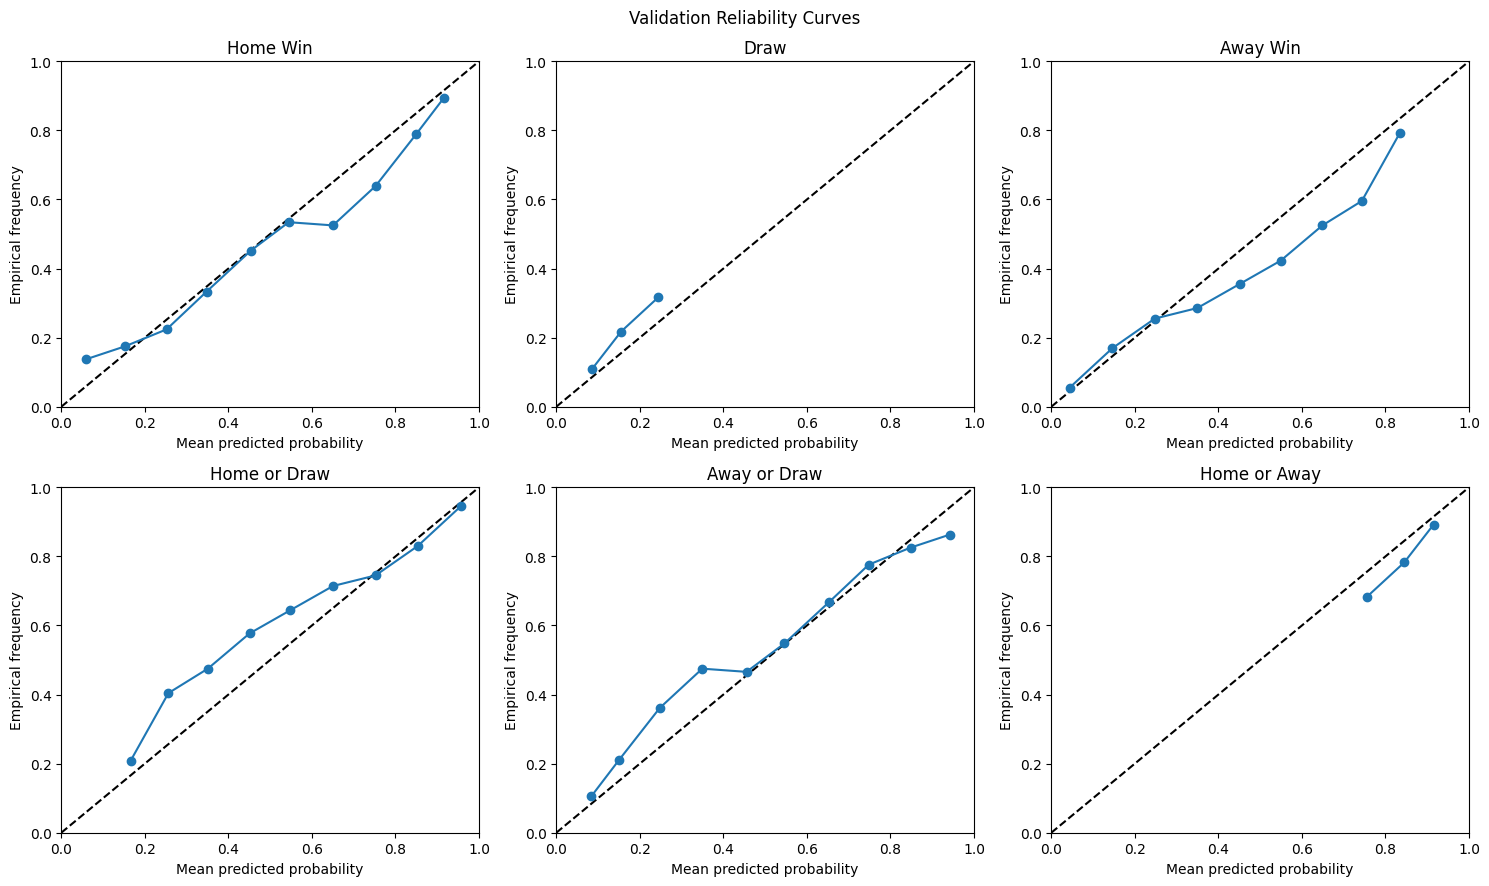

,split,event,weighted_calibration_error
0,Test,Away Win,0.039562
1,Test,Away or Draw,0.037126
2,Test,Draw,0.033505
3,Test,Home Win,0.037126
4,Test,Home or Away,0.033505
5,Test,Home or Draw,0.039562
6,Validation,Away Win,0.051018
7,Validation,Away or Draw,0.052291
8,Validation,Draw,0.066283
9,Validation,Home Win,0.052291


,event,probability_bin,count,mean_predicted_probability,empirical_frequency,absolute_calibration_gap
0,Home Win,"(-0.001, 0.1]",73,0.058262,0.136986,0.078725
1,Home Win,"(0.1, 0.2]",63,0.151975,0.174603,0.022628
2,Home Win,"(0.2, 0.3]",67,0.251989,0.223881,0.028109
3,Home Win,"(0.3, 0.4]",57,0.347945,0.333333,0.014611
4,Home Win,"(0.4, 0.5]",73,0.453825,0.452055,0.001771
5,Home Win,"(0.5, 0.6]",73,0.544544,0.534247,0.010297
6,Home Win,"(0.6, 0.7]",80,0.650473,0.525000,0.125473
7,Home Win,"(0.7, 0.8]",72,0.752357,0.638889,0.113468
8,Home Win,"(0.8, 0.9]",100,0.850151,0.790000,0.060151
9,Home Win,"(0.9, 1.0]",19,0.916261,0.894737,0.021524


In [52]:
# Divide probabilities into ten equal-width intervals from 0% to 100%.
CALIBRATION_BIN_EDGES = np.linspace(0.0, 1.0, 11)

# Compare predicted probabilities with observed frequencies for each event.
def probability_calibration_table(actual_results, probability_frame):
    actual_array = np.asarray(actual_results)
    events = {
        "Home Win": (
            "probability_home_win",
            actual_array == "Home Win",
        ),
        "Draw": (
            "probability_draw",
            actual_array == "Draw",
        ),
        "Away Win": (
            "probability_away_win",
            actual_array == "Away Win",
        ),
        "Home or Draw": (
            "probability_home_or_draw",
            actual_array != "Away Win",
        ),
        "Away or Draw": (
            "probability_away_or_draw",
            actual_array != "Home Win",
        ),
        "Home or Away": (
            "probability_home_or_away",
            actual_array != "Draw",
        ),
    }
    tables = []
    # Build a separate calibration table for each result and double-chance event.
    for event_name, (probability_column, actual_event) in events.items():
        event_frame = pd.DataFrame({
            "predicted_probability": probability_frame[
                probability_column
            ].to_numpy(),
            "actual_event": actual_event.astype(float),
        })
        # Assign each prediction to a 10-percentage-point probability interval.
        event_frame["probability_bin"] = pd.cut(
            event_frame["predicted_probability"],
            bins=CALIBRATION_BIN_EDGES,
            include_lowest=True,
        )
        # Calculate prediction and outcome summaries within each probability bin.
        event_table = (
            event_frame.groupby(
                "probability_bin", observed=False
            )
            .agg(
                count=("actual_event", "size"),
                mean_predicted_probability=(
                    "predicted_probability", "mean"
                ),
                empirical_frequency=("actual_event", "mean"),
            )
            .reset_index()
        )
        # Measure the absolute difference between predicted and observed frequency.
        event_table = event_table.loc[event_table["count"] > 0].copy()
        event_table.insert(0, "event", event_name)
        event_table["absolute_calibration_gap"] = (
            event_table["mean_predicted_probability"]
            - event_table["empirical_frequency"]
        ).abs()
        tables.append(event_table)
    return pd.concat(tables, ignore_index=True)

# Calculate calibration using validation predictions.
validation_calibration_table = probability_calibration_table(
    y_validation_result,
    final_probability_frames["Validation"],
)
test_calibration_table = probability_calibration_table(
    y_test_result,
    final_probability_frames["Test"],
)
# Average calibration gaps while giving more weight to bins containing more matches.
calibration_summary = pd.concat([
    validation_calibration_table.assign(split="Validation"),
    test_calibration_table.assign(split="Test"),
]).groupby(["split", "event"]).apply(
    lambda group: np.average(
        group["absolute_calibration_gap"],
        weights=group["count"],
    ),
    include_groups=False,
).rename("weighted_calibration_error").reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, event_name in zip(
    axes.flatten(), validation_calibration_table["event"].unique()
):
    event_table = validation_calibration_table.loc[
        validation_calibration_table["event"].eq(event_name)
    ]
    axis.plot([0, 1], [0, 1], color="black", linestyle="--")
    axis.plot(
        event_table["mean_predicted_probability"],
        event_table["empirical_frequency"],
        marker="o",
    )
    axis.set_title(event_name)
    axis.set_xlabel("Mean predicted probability")
    axis.set_ylabel("Empirical frequency")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
fig.suptitle("Validation Reliability Curves")
plt.tight_layout()
plt.show()

display(calibration_summary)
validation_calibration_table


### Validation-Selected Draw Decision Rule

The model produces probabilities for a home win, draw and away win. These probabilities are evaluated separately from the final predicted class.

For diagnostics requiring one result, the validation set selects a minimum draw-probability threshold. A draw is predicted when its probability exceeds this threshold; otherwise, the more likely win outcome is selected.

The threshold is chosen by maximizing balanced accuracy, with ordinary accuracy used as a tie-breaker. This can improve draw detection without changing the expected goals or underlying probabilities.

In [ ]:
# Convert result probabilities into hard classes using a configurable draw threshold.
def predict_results_with_draw_threshold(
    probability_frame, draw_threshold
):
    # Initially predict whichever team has the larger win probability.
    predictions = np.where(
        probability_frame["probability_home_win"].to_numpy()
        >= probability_frame["probability_away_win"].to_numpy(),
        "Home Win",
        "Away Win",
    ).astype(object)
    # Predict a draw whenever its probability reaches the selected threshold.
    predictions[
        probability_frame["probability_draw"].to_numpy() >= draw_threshold
    ] = "Draw"
    return predictions

# Store validation metrics for every candidate draw threshold.
draw_threshold_rows = []
# Test draw thresholds from 15% to 40% in one-percentage-point steps.
for draw_threshold in np.arange(0.15, 0.401, 0.01):
    # Apply the candidate threshold to validation probabilities.
    threshold_predictions = predict_results_with_draw_threshold(
        final_probability_frames["Validation"], draw_threshold
    )
    # Record classification performance for the candidate threshold.
    draw_threshold_rows.append({
        "draw_threshold": draw_threshold,
        "accuracy": accuracy_score(
            y_validation_result, threshold_predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_validation_result, threshold_predictions
        ),
        "draw_recall": draw_recall(
            y_validation_result, threshold_predictions
        ),
    })
# Rank thresholds by balanced accuracy, using accuracy as a tie-breaker.
draw_threshold_validation_results = (
    pd.DataFrame(draw_threshold_rows)
    .sort_values(
        ["balanced_accuracy", "accuracy"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)
# Select the highest-ranked validation threshold.
selected_draw_threshold = draw_threshold_validation_results.loc[
    0, "draw_threshold"
]
# Apply the fixed validation-selected rule to untouched test probabilities.
final_test_class_predictions = predict_results_with_draw_threshold(
    final_probability_frames["Test"], selected_draw_threshold
)
# Summarize final hard-class performance on the test period.
final_test_decision_metrics = pd.Series({
    "draw_threshold": selected_draw_threshold,
    "accuracy": accuracy_score(
        y_test_result, final_test_class_predictions
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test_result, final_test_class_predictions
    ),
    "draw_recall": draw_recall(
        y_test_result, final_test_class_predictions
    ),
}, name="test_value")

draw_threshold_validation_results.head(10)


,draw_threshold,accuracy,balanced_accuracy,draw_recall
0,0.25,0.540620,0.503236,0.366120
1,0.24,0.530281,0.501731,0.464481
2,0.27,0.562777,0.495323,0.000000
3,0.28,0.562777,0.495323,0.000000
4,0.29,0.562777,0.495323,0.000000
5,0.30,0.562777,0.495323,0.000000
6,0.31,0.562777,0.495323,0.000000
7,0.32,0.562777,0.495323,0.000000
8,0.33,0.562777,0.495323,0.000000
9,0.34,0.562777,0.495323,0.000000


In [54]:
# Evaluate the validation-selected model's test result probabilities.
final_test_probability_metrics = pd.Series(
    evaluate_result_probabilities(
        y_test_result, final_probability_frames["Test"]
    ),
    name="test_value",
)
# Evaluate the selected model's expected home and away goals on test data.
final_test_goal_metrics = pd.Series(
    evaluate_goal_predictions(
        y_test, final_goal_predictions["Test"]
    ),
    name="test_value",
)
# Compare every goal-prediction method on the test period.
test_goal_comparison = pd.DataFrame([
    {
        "model": "Elo-only expected goals",
        **evaluate_goal_predictions(
            y_test,
            baseline_goal_predictions[(
                "Elo-only expected goals", "Test"
            )],
        ),
    },
    {
        "model": "Random Forest goals",
        **evaluate_goal_predictions(
            y_test, random_forest_goal_predictions["Test"]
        ),
    },
    {
        "model": "Histogram Gradient Boosting goals",
        **evaluate_goal_predictions(
            y_test, boosted_goal_predictions["Test"]
        ),
    },
# Rank goal models by Poisson deviance, then MAE and RMSE.
]).sort_values([
    "mean_poisson_deviance", "mae_overall", "rmse_overall"
]).reset_index(drop=True)

# Compare all probability approaches on the final test period.
test_probability_comparison = pd.DataFrame([
    {
        "model": "Class-frequency baseline",
        **evaluate_result_probabilities(
            y_test_result,
            baseline_result_probabilities["Test"],
        ),
    },
    {
        "model": "Elo-only goals + Poisson",
        **evaluate_result_probabilities(
            y_test_result,
            elo_scoreline_probabilities["Test"],
        ),
    },
    {
        "model": "Random Forest classifier",
        **evaluate_result_probabilities(
            y_test_result,
            final_classifier_test_probabilities,
        ),
    },
    {
        "model": "Random Forest goals + Poisson",
        **evaluate_result_probabilities(
            y_test_result,
            random_forest_scoreline_probabilities["Test"],
        ),
    },
    {
        "model": "Boosted Poisson goals + score matrix",
        **evaluate_result_probabilities(
            y_test_result,
            boosted_scoreline_probabilities["Test"],
        ),
    },
# Rank probability models by log loss, then Brier score.
]).sort_values(["log_loss", "brier_score"]).reset_index(drop=True)

# Copy test fixture identifiers, teams and actual scores.
final_test_predictions = test_df[[
    "fixture_id", "date", "home_team", "away_team",
    "goals_home", "goals_away",
]].copy()
# Add selected-model expected home goals.
final_test_predictions["expected_home_goals"] = (
    final_goal_predictions["Test"][:, 0]
)
# Add selected-model expected away goals.
final_test_predictions["expected_away_goals"] = (
    final_goal_predictions["Test"][:, 1]
)
# Add result, double-chance, over/under and modal-score probabilities.
final_test_predictions = pd.concat([
    final_test_predictions,
    final_probability_frames["Test"].reset_index(drop=True),
], axis=1)
# Add the true home-win, draw or away-win result.
final_test_predictions["actual_result"] = y_test_result.to_numpy()
# Add the hard result selected using the validation-chosen draw threshold.
final_test_predictions["predicted_result"] = final_test_class_predictions

# Store each exact-score matrix under its fixture ID.
final_scoreline_matrices = {
    fixture_id: matrix
    for fixture_id, matrix in zip(
        test_df["fixture_id"],
        final_scoreline_matrices_by_split["Test"],
    )
}
# Verify that every test fixture has one stored scoreline matrix.
assert len(final_scoreline_matrices) == len(test_df)
# Verify that result probabilities sum to one for every fixture.
assert np.allclose(
    final_test_predictions[[
        "probability_home_win",
        "probability_draw",
        "probability_away_win",
    ]].sum(axis=1),
    1.0,
)

display(test_goal_comparison)
display(test_probability_comparison)
display(final_test_goal_metrics)
display(final_test_probability_metrics)
display(final_test_decision_metrics)
final_test_predictions.head(20)


,model,mae_home,mae_away,mae_overall,rmse_home,rmse_away,rmse_overall,mean_poisson_deviance,result_accuracy,result_balanced_accuracy,draw_recall,rounded_score_accuracy
0,Histogram Gradient Boosting goals,1.047164,0.892541,0.969853,1.379061,1.189826,1.284444,1.215037,0.643399,0.529234,0.0,0.098634
1,Random Forest goals,1.066513,0.883022,0.974767,1.398245,1.184295,1.291270,1.225896,0.637329,0.519679,0.0,0.098634
2,Elo-only expected goals,1.027978,0.893900,0.960939,1.409141,1.202361,1.305751,1.240823,0.641882,0.531344,0.0,0.109256


,model,log_loss,brier_score,accuracy,balanced_accuracy,draw_recall,brier_home_or_draw,brier_away_or_draw,brier_home_or_away
0,Elo-only goals + Poisson,0.806455,0.469296,0.641882,0.531344,0.0,0.135195,0.167904,0.166197
1,Boosted Poisson goals + score matrix,0.821381,0.478603,0.643399,0.529234,0.0,0.137894,0.173774,0.166935
2,Random Forest goals + Poisson,0.832086,0.483199,0.637329,0.519679,0.0,0.139820,0.176876,0.166503
3,Random Forest classifier,0.842543,0.489931,0.634294,0.520770,0.0,NaN,NaN,NaN
4,Class-frequency baseline,1.040807,0.626561,0.496206,0.333333,0.0,NaN,NaN,NaN


mae_home                    1.027978
mae_away                    0.893900
mae_overall                 0.960939
rmse_home                   1.409141
rmse_away                   1.202361
rmse_overall                1.305751
mean_poisson_deviance       1.240823
result_accuracy             0.641882
result_balanced_accuracy    0.531344
draw_recall                 0.000000
rounded_score_accuracy      0.109256
Name: test_value, dtype: float64

log_loss              0.806455
brier_score           0.469296
accuracy              0.641882
balanced_accuracy     0.531344
draw_recall           0.000000
brier_home_or_draw    0.135195
brier_away_or_draw    0.167904
brier_home_or_away    0.166197
Name: test_value, dtype: float64

draw_threshold       0.250000
accuracy             0.629742
balanced_accuracy    0.571330
draw_recall          0.394558
Name: test_value, dtype: float64

,fixture_id,date,home_team,away_team,goals_home,goals_away,expected_home_goals,expected_away_goals,probability_home_win,probability_draw,...,probability_home_or_draw,probability_away_or_draw,probability_home_or_away,probability_under_2_5_goals,probability_over_2_5_goals,modal_home_goals,modal_away_goals,modal_score_probability,actual_result,predicted_result
0,350608,2025-03-20 23:00:00+00:00,Paraguay,Chile,1,0,1.659885,0.967729,0.536122,0.244124,...,0.780246,0.463878,0.755876,0.511520,0.488480,1,0,0.119928,Home Win,Home Win
1,350609,2025-03-21 00:45:00+00:00,Brazil,Colombia,2,1,1.608293,1.010791,0.512890,0.249114,...,0.762003,0.487110,0.750886,0.513650,0.486350,1,1,0.118460,Home Win,Home Win
2,350610,2025-03-21 01:30:00+00:00,Peru,Bolivia,3,1,1.915304,0.754544,0.648228,0.211889,...,0.860117,0.351772,0.788111,0.501042,0.498958,1,0,0.132660,Home Win,Home Win
3,351801,2025-03-21 12:30:00+00:00,Singapore,Nepal,0,1,1.953575,0.722601,0.664360,0.206155,...,0.870514,0.335640,0.793845,0.499482,0.500518,1,0,0.134457,Away Win,Home Win
4,351799,2025-03-21 13:00:00+00:00,Thailand,Afghanistan,2,0,2.331654,0.407038,0.808565,0.142211,...,0.950776,0.191435,0.857789,0.484210,0.515790,2,0,0.175758,Home Win,Home Win
5,154681,2025-03-21 17:00:00+00:00,Cyprus,San Marino,2,0,2.589807,0.191571,0.886782,0.096727,...,0.983509,0.113218,0.903273,0.473944,0.526056,2,0,0.207780,Home Win,Home Win
6,154676,2025-03-21 19:45:00+00:00,Malta,Finland,0,1,1.010267,1.509932,0.253269,0.258688,...,0.511957,0.746731,0.741312,0.538643,0.461357,1,1,0.122712,Away Win,Draw
7,154678,2025-03-21 19:45:00+00:00,Poland,Lithuania,1,0,2.580714,0.199161,0.884345,0.098284,...,0.982629,0.115655,0.901716,0.474303,0.525697,2,0,0.206634,Home Win,Home Win
8,154683,2025-03-21 19:45:00+00:00,Romania,Bosnia and Herzegovina,0,1,2.134702,0.571424,0.737257,0.176760,...,0.914018,0.262743,0.823240,0.492133,0.507867,2,0,0.152193,Away Win,Home Win
9,154685,2025-03-21 19:45:00+00:00,Andorra,Latvia,0,1,0.880092,1.618583,0.203986,0.248199,...,0.452185,0.796014,0.751801,0.544154,0.455846,0,1,0.133038,Away Win,Away Win


## Final Model Selection and Interpretation

The **Elo-only goals + Poisson** model was selected because it achieved the best probability performance on the chronological validation set. It recorded the lowest validation log loss of **0.943** and the lowest Brier score of **0.562**. These were the primary selection metrics because the final model must produce reliable probabilities, not only a single predicted result.

The boosted model performed similarly, with a validation log loss of **0.948** and Brier score of **0.563**, while the random forest goal model performed slightly worse. This suggests that the additional rolling and GAP features did not provide enough stable information to outperform the simpler Elo ratings. Missing historical statistics, noise and changing team performance may have limited the more complex models.

The untouched test results supported the validation decision. Elo-only goals + Poisson again achieved the best probability results:

- **Log loss:** 0.813
- **Brier score:** 0.475
- **Result accuracy:** 63.5%
- **Balanced accuracy:** 53.2%

It also achieved the lowest overall goal MAE of **0.965**. The boosted model produced slightly better Poisson deviance and RMSE, but its result probabilities were weaker. Since probability quality was the main objective, Elo remained the preferred model.

The selected model first uses Elo ratings to estimate expected home and away goals. Independent Poisson distributions then convert these expected goals into exact-score, result and over/under probabilities.

One weakness was draw detection. Selecting the largest probability directly produced no draw predictions. A draw threshold of **0.25** was therefore selected using validation data. On the test set, this increased draw recall to **39.4%** and balanced accuracy to **57.1%**, although overall accuracy decreased slightly to **62.5%**.

Overall, the Elo model was selected because it was simpler, more stable and produced the best validated probabilities. However, the small difference between Elo and gradient boosting suggests that further feature improvements or additional data could change the preferred model.

# 14. Predict a New Fixture

Run the notebook through this section, then call `predict_match` with the two
team names, kickoff timestamp, neutral-site flag and competitive-match flag.
The helper automatically uses the goal model selected on validation:

1. Elo-only predictions look up each team's pre-match rating and map the Elo
   expectation to home and away expected goals.
2. Tree-model predictions additionally build five-match rolling form and GAP
   states, then apply the training-fitted transformations and imputer.
3. Every route returns expected goals, a Poisson score matrix and
   home/draw/away probabilities.
4. The summary also reports expected total goals and the probabilities of
   under or over 2.5 total goals.

The returned summary reports the history cutoff for the selected model and its
age at kickoff. Update the relevant source data and rerun the notebook when
that cutoff is stale.


In [55]:
import difflib
import warnings

# Resolve the latest ID attached to each displayed team name.
team_reference = pd.concat([
    model_data[["date", "home_team", "home_team_id"]].rename(
        columns={"home_team": "team", "home_team_id": "team_id"}
    ),
    model_data[["date", "away_team", "away_team_id"]].rename(
        columns={"away_team": "team", "away_team_id": "team_id"}
    ),
], ignore_index=True)

# Include every team in the 2026 World Cup schedule, even when a team has no
# completed fixture in Final_Data_enriched.csv yet.
world_cup_schedule = pd.read_csv(results_path, low_memory=False)
world_cup_schedule_dates = pd.to_datetime(
    world_cup_schedule["date"], errors="coerce"
)
world_cup_schedule = world_cup_schedule.loc[
    world_cup_schedule["tournament"].eq("FIFA World Cup")
    & world_cup_schedule_dates.dt.year.eq(2026)
]
world_cup_team_names = sorted(
    set(world_cup_schedule["home_team"].dropna())
    | set(world_cup_schedule["away_team"].dropna())
)

import refresh_world_cup_stats as world_cup_refresh

# Reuse the same validated 48-team local-ID mapping as the update pipeline.
_, world_cup_mapping = world_cup_refresh.world_cup_local_team_ids(
    set(world_cup_team_names)
)
world_cup_reference_rows = (
    world_cup_mapping.rename(
        columns={"local_team_id": "team_id"}
    )[["team", "team_id"]]
    .assign(date="2262-01-01 00:00:00+00:00")
)
team_reference = pd.concat([
    team_reference,
    world_cup_reference_rows,
], ignore_index=True)
team_reference["_reference_date"] = pd.to_datetime(
    team_reference["date"], errors="coerce", utc=True
)
team_reference["_team_key"] = (
    team_reference["team"].astype(str).str.strip().str.casefold()
)
team_reference = (
    team_reference.sort_values("_reference_date", kind="mergesort")
    .drop_duplicates("_team_key", keep="last")
    .reset_index(drop=True)
)
team_reference_by_key = team_reference.set_index("_team_key")
model_feature_history_cutoff = pd.to_datetime(
    model_data["date"], errors="coerce", utc=True
).max()
elo_feature_history_cutoff = pd.to_datetime(
    elo_results["_elo_date"], errors="coerce", utc=True
).max()
feature_history_cutoff = (
    elo_feature_history_cutoff
    if final_goal_probability_model == "Elo-only goals + Poisson"
    else model_feature_history_cutoff
)


def available_prediction_teams(search=None):
    """Return supported team names, optionally filtered by a search string."""
    names = team_reference["team"].dropna().sort_values().reset_index(drop=True)
    if search is not None:
        names = names.loc[
            names.str.contains(str(search), case=False, regex=False)
        ].reset_index(drop=True)
    return names


def _resolve_prediction_team(team_name):
    team_key = str(team_name).strip().casefold()
    if team_key in team_reference_by_key.index:
        team_row = team_reference_by_key.loc[team_key]
        return team_row["team"], team_row["team_id"]

    suggestions = difflib.get_close_matches(
        team_key,
        team_reference_by_key.index.tolist(),
        n=5,
        cutoff=0.5,
    )
    suggested_names = [
        team_reference_by_key.loc[key, "team"] for key in suggestions
    ]
    raise ValueError(
        f"Unknown team {team_name!r}. Closest available names: "
        f"{suggested_names}"
    )


def _future_rolling_features(team_id, side, kickoff_timestamp):
    prior_matches = (
        team_history.loc[
            team_history["team_id"].eq(team_id)
            & team_history["match_date"].lt(kickoff_timestamp)
        ]
        .sort_values(["match_date", "fixture_id"], kind="mergesort")
        .tail(ROLLING_WINDOW)
    )

    features = {}
    for source_column, feature_name in rolling_inputs.items():
        features[f"{side}_rolling_5_{feature_name}"] = (
            prior_matches[source_column].mean()
            if len(prior_matches)
            else np.nan
        )
    features[f"{side}_rolling_5_matches"] = len(prior_matches)
    features[f"{side}_rolling_5_shots_on_target_matches"] = (
        prior_matches["shots_on_target_for"].notna().sum()
    )
    return features


def _future_gap_features(home_team_id, away_team_id, neutral):
    home_state = gap_states.get(home_team_id, new_gap_state())
    away_state = gap_states.get(away_team_id, new_gap_state())

    if neutral:
        home_attack = (
            home_state["home_attack"] + home_state["away_attack"]
        ) / 2
        home_defence = (
            home_state["home_defence"] + home_state["away_defence"]
        ) / 2
        away_attack = (
            away_state["home_attack"] + away_state["away_attack"]
        ) / 2
        away_defence = (
            away_state["home_defence"] + away_state["away_defence"]
        ) / 2
    else:
        home_attack = home_state["home_attack"]
        home_defence = home_state["home_defence"]
        away_attack = away_state["away_attack"]
        away_defence = away_state["away_defence"]

    return {
        "home_gap_attack": home_attack,
        "home_gap_defence": home_defence,
        "away_gap_attack": away_attack,
        "away_gap_defence": away_defence,
        "home_gap_matches": home_state["matches"],
        "away_gap_matches": away_state["matches"],
        "gap_ratings_ready": int(
            home_state["matches"] >= GAP_BURN_IN_MATCHES
            and away_state["matches"] >= GAP_BURN_IN_MATCHES
        ),
    }


def _model_features_for_fixture(
    home_team,
    away_team,
    kickoff,
    neutral,
    competitive,
):
    kickoff_timestamp = pd.to_datetime(kickoff, errors="raise", utc=True)
    if kickoff_timestamp <= feature_history_cutoff:
        raise ValueError(
            "predict_match is for fixtures after the feature-history cutoff "
            f"({feature_history_cutoff}). Historical predictions require "
            "rebuilding features at that historical timestamp."
        )

    resolved_home_team, home_team_id = _resolve_prediction_team(home_team)
    resolved_away_team, away_team_id = _resolve_prediction_team(away_team)
    if home_team_id == away_team_id:
        raise ValueError("Home and away teams must be different.")

    history_age_days = (
        kickoff_timestamp - feature_history_cutoff
    ).total_seconds() / 86400
    if history_age_days > 30:
        warnings.warn(
            "Rolling and GAP features are "
            f"{history_age_days:.0f} days old at kickoff. Refresh "
            "Final_Data_enriched.csv and rerun the notebook for a current "
            "prediction.",
            stacklevel=2,
        )

    elo_date = kickoff_timestamp.tz_localize(None).normalize()
    home_elo, home_elo_matches = get_pre_match_elo(
        resolved_home_team, elo_date
    )
    away_elo, away_elo_matches = get_pre_match_elo(
        resolved_away_team, elo_date
    )

    feature_values = {
        "home_elo": home_elo,
        "away_elo": away_elo,
        "home_elo_matches": home_elo_matches,
        "away_elo_matches": away_elo_matches,
        "matched_neutral": int(bool(neutral)),
        "competitive": int(bool(competitive)),
    }
    feature_values.update(
        _future_rolling_features(
            home_team_id, "home", kickoff_timestamp
        )
    )
    feature_values.update(
        _future_rolling_features(
            away_team_id, "away", kickoff_timestamp
        )
    )
    feature_values.update(
        _future_gap_features(home_team_id, away_team_id, bool(neutral))
    )
    feature_values["home_missing_shots_on_target_history"] = int(
        pd.isna(feature_values["home_rolling_5_shots_on_target_for"])
        or pd.isna(
            feature_values["home_rolling_5_shots_on_target_against"]
        )
    )
    feature_values["away_missing_shots_on_target_history"] = int(
        pd.isna(feature_values["away_rolling_5_shots_on_target_for"])
        or pd.isna(
            feature_values["away_rolling_5_shots_on_target_against"]
        )
    )

    feature_frame = pd.DataFrame(
        [feature_values], columns=raw_feature_columns
    )
    transformed_frame = apply_deterministic_transforms(feature_frame)
    imputed_raw_frame = pd.DataFrame(
        raw_imputer.transform(transformed_frame),
        columns=raw_feature_columns,
    )
    metadata = {
        "home_team": resolved_home_team,
        "away_team": resolved_away_team,
        "kickoff": kickoff_timestamp,
        "neutral": bool(neutral),
        "competitive": bool(competitive),
        "feature_history_cutoff": feature_history_cutoff,
        "history_age_days": history_age_days,
    }
    return imputed_raw_frame, metadata


def _predict_expected_goals_for_fixture(imputed_raw_frame):
    if final_goal_probability_model == "Elo-only goals + Poisson":
        home_elo = imputed_raw_frame["home_elo"].to_numpy()
        away_elo = imputed_raw_frame["away_elo"].to_numpy()
        neutral = imputed_raw_frame["matched_neutral"].to_numpy()
        expected_home_score = elo_expected_score(
            home_elo + (1.0 - neutral) * ELO_HOME_ADVANTAGE,
            away_elo,
        )
        expected_home_goals = (
            train_mean_home_goals
            * expected_home_score
            / train_mean_elo_expectation
        )
        expected_away_goals = (
            train_mean_away_goals
            * (1.0 - expected_home_score)
            / (1.0 - train_mean_elo_expectation)
        )
        return np.column_stack([
            np.clip(expected_home_goals, 0.01, None),
            np.clip(expected_away_goals, 0.01, None),
        ])

    if (
        final_goal_probability_model
        == "Boosted Poisson goals + score matrix"
    ):
        prediction = np.column_stack([
            best_boosted_home_model.predict(imputed_raw_frame),
            best_boosted_away_model.predict(imputed_raw_frame),
        ])
        return np.clip(prediction, 0.01, None)

    if best_goal_representation == "Raw":
        model_frame = imputed_raw_frame[best_goal_columns]
    else:
        scaled_pca_values = pca_scaler.transform(
            imputed_raw_frame[pca_feature_columns]
        )
        component_values = pca_model.transform(scaled_pca_values)
        component_frame = pd.DataFrame(
            component_values,
            columns=principal_component_columns,
        )
        model_frame = pd.concat([
            component_frame,
            imputed_raw_frame[pca_context_columns],
        ], axis=1)[best_goal_columns]

    return np.clip(
        best_random_forest_goal_model.predict(model_frame),
        0.01,
        None,
    )


def predict_match(
    home_team,
    away_team,
    kickoff,
    neutral=False,
    competitive=True,
    top_scorelines=10,
):
    """Predict goals, result probabilities and likely exact scorelines."""
    raw_features, metadata = _model_features_for_fixture(
        home_team=home_team,
        away_team=away_team,
        kickoff=kickoff,
        neutral=neutral,
        competitive=competitive,
    )
    expected_goals = _predict_expected_goals_for_fixture(raw_features)
    probability_frame, matrices = (
        scoreline_probabilities_from_goal_predictions(
            expected_goals,
            keep_matrices=True,
        )
    )
    probability_frame = probability_frame.reset_index(drop=True)
    predicted_result = predict_results_with_draw_threshold(
        probability_frame, selected_draw_threshold
    )[0]
    matrix = matrices[0]

    summary = pd.DataFrame([{
        **metadata,
        "model": final_goal_probability_model,
        "expected_home_goals": expected_goals[0, 0],
        "expected_away_goals": expected_goals[0, 1],
        "expected_total_goals": expected_goals[0].sum(),
        "predicted_result": predicted_result,
        "predicted_over_under_2_5": (
            "Over 2.5"
            if probability_frame.loc[0, "probability_over_2_5_goals"]
            >= probability_frame.loc[0, "probability_under_2_5_goals"]
            else "Under 2.5"
        ),
        "draw_decision_threshold": selected_draw_threshold,
        **probability_frame.iloc[0].to_dict(),
    }])

    scoreline_rows = []
    for flat_index in np.argsort(matrix.ravel())[::-1][:top_scorelines]:
        home_goals, away_goals = np.unravel_index(
            flat_index, matrix.shape
        )
        scoreline_rows.append({
            "scoreline": f"{home_goals}-{away_goals}",
            "home_goals": home_goals,
            "away_goals": away_goals,
            "probability": matrix[home_goals, away_goals],
        })
    likely_scorelines = pd.DataFrame(scoreline_rows)
    score_matrix = pd.DataFrame(
        matrix,
        index=pd.Index(
            range(matrix.shape[0]), name="home_goals"
        ),
        columns=pd.Index(
            range(matrix.shape[1]), name="away_goals"
        ),
    )
    return summary, likely_scorelines, score_matrix


In [57]:
# 2026 World Cup team lookup tags accepted by predict_match.
world_cup_lookup_tags = pd.DataFrame({
    "team": world_cup_team_names,
    "lookup_tag": [f'"{team}"' for team in world_cup_team_names],
})

supported_team_names = set(available_prediction_teams())
unsupported_world_cup_teams = sorted(
    set(world_cup_team_names) - supported_team_names
)
if unsupported_world_cup_teams:
    raise ValueError(
        "Unsupported World Cup lookup tags: "
        f"{unsupported_world_cup_teams}"
    )

world_cup_lookup_tags


,team,lookup_tag
0,Algeria,"""Algeria"""
1,Argentina,"""Argentina"""
2,Australia,"""Australia"""
3,Austria,"""Austria"""
4,Belgium,"""Belgium"""
5,Bosnia and Herzegovina,"""Bosnia and Herzegovina"""
6,Brazil,"""Brazil"""
7,Canada,"""Canada"""
8,Cape Verde,"""Cape Verde"""
9,Colombia,"""Colombia"""


In [56]:
prediction_summary, likely_scorelines, score_matrix = predict_match(
    home_team="Belgium",
    away_team="Iran",
    kickoff="2026-06-18 16:00:00+00:00",
    neutral=True,
    competitive=True,
)

display(prediction_summary.T)
likely_scorelines


,0
home_team,Belgium
away_team,Iran
kickoff,2026-06-18 16:00:00+00:00
neutral,True
competitive,True
feature_history_cutoff,2026-06-07 00:00:00+00:00
history_age_days,11.666667
model,Elo-only goals + Poisson
expected_home_goals,1.745044
expected_away_goals,0.896651


,scoreline,home_goals,away_goals,probability
0,1-0,1,0,0.124318
1,1-1,1,1,0.111470
2,2-0,2,0,0.108470
3,2-1,2,1,0.097260
4,0-0,0,0,0.071241
5,0-1,0,1,0.063878
6,3-0,3,0,0.063095
7,3-1,3,1,0.056574
8,1-2,1,2,0.049975
9,2-2,2,2,0.043604


# 16. Joint Kelly for All Match-Result Markets

This helper optimizes `H`, `D`, `A`, `H/D`, `A/D` and `H/A` together.
Supply mutually exclusive model probabilities for `H`, `D` and `A`, and
decimal bookmaker odds for all six markets. Fractional odds must first be
converted using `decimal_odds = 1 + fractional_odds`.


In [60]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Define the three mutually exclusive match outcomes.
KELLY_OUTCOMES = ("H", "D", "A")

# Define the three single-result and three double-chance markets.
KELLY_MARKETS = ("H", "D", "A", "H/D", "A/D", "H/A")

# Map each actual match result to the markets that would win.
WINNING_MARKETS = {
    "H": {"H", "H/D", "H/A"},
    "D": {"D", "H/D", "A/D"},
    "A": {"A", "A/D", "H/A"},
}


def joint_kelly_all_markets(
    probabilities,
    decimal_odds,
    kelly_fraction=0.10,
    bankroll=None,
    max_total_stake=None,
):
    """Optimize stakes across all six overlapping result markets."""

    # Check that all required probabilities are supplied.
    missing_probabilities = (
        set(KELLY_OUTCOMES) - set(probabilities)
    )

    # Check that no unsupported probability keys were supplied.
    unexpected_probabilities = (
        set(probabilities) - set(KELLY_OUTCOMES)
    )

    # Check that odds are supplied for all six markets.
    missing_odds = (
        set(KELLY_MARKETS) - set(decimal_odds)
    )

    # Check that no unsupported market keys were supplied.
    unexpected_odds = (
        set(decimal_odds) - set(KELLY_MARKETS)
    )

    # Stop if the input dictionaries do not have the expected keys.
    if any((
        missing_probabilities,
        unexpected_probabilities,
        missing_odds,
        unexpected_odds,
    )):
        raise ValueError(
            f"Missing probabilities="
            f"{sorted(missing_probabilities)}, "
            f"unexpected probabilities="
            f"{sorted(unexpected_probabilities)}, "
            f"missing odds={sorted(missing_odds)}, "
            f"unexpected odds={sorted(unexpected_odds)}"
        )

    # Convert H, D and A probabilities into a fixed-order numeric array.
    p = np.array([
        probabilities[outcome]
        for outcome in KELLY_OUTCOMES
    ], dtype=float)

    # Convert the six market odds into the same fixed order used throughout.
    odds = np.array([
        decimal_odds[market]
        for market in KELLY_MARKETS
    ], dtype=float)

    # Require valid non-negative probabilities that sum to one.
    if (
        not np.all(np.isfinite(p))
        or np.any(p < 0)
        or not np.isclose(
            p.sum(),
            1.0,
            atol=1e-6,
        )
    ):
        raise ValueError(
            "H, D and A probabilities must be "
            "finite, non-negative and sum to 1."
        )

    # Require valid decimal odds greater than one.
    if (
        not np.all(np.isfinite(odds))
        or np.any(odds <= 1)
    ):
        raise ValueError(
            "All odds must be finite decimal odds "
            "greater than 1."
        )

    # Fractional Kelly must be greater than zero and no larger than full Kelly.
    if not 0 < kelly_fraction <= 1:
        raise ValueError(
            "kelly_fraction must be in the interval (0, 1]."
        )

    # A supplied bankroll must be positive.
    if bankroll is not None and bankroll <= 0:
        raise ValueError("bankroll must be positive.")

    # The optional total exposure limit is expressed as a bankroll fraction.
    if (
        max_total_stake is not None
        and not 0 < max_total_stake <= 1
    ):
        raise ValueError(
            "max_total_stake must be in the interval (0, 1]."
        )

    # Create a return matrix:
    # rows are actual H/D/A results and columns are the six markets.
    # Every market is initially treated as losing its full stake.
    returns = np.full(
        (
            len(KELLY_OUTCOMES),
            len(KELLY_MARKETS),
        ),
        -1.0,
    )

    # Replace losing returns with the net profit for markets that win.
    for outcome_index, outcome in enumerate(
        KELLY_OUTCOMES
    ):
        for market_index, market in enumerate(
            KELLY_MARKETS
        ):
            if market in WINNING_MARKETS[outcome]:
                returns[
                    outcome_index,
                    market_index,
                ] = odds[market_index] - 1

    # Calculate each market's probability of winning.
    event_probabilities = np.array([
        p[0],             # Home win
        p[1],             # Draw
        p[2],             # Away win
        p[0] + p[1],      # Home or draw
        p[2] + p[1],      # Away or draw
        p[0] + p[2],      # Home or away
    ])

    # Require wealth to remain strictly positive under every outcome.
    wealth_floor = 1e-12

    def solve_kelly(max_exposure):
        """Find the joint Kelly allocation under a total stake limit."""

        def negative_growth(stakes):
            # Calculate final bankroll under each possible H/D/A result.
            wealth = 1 + returns @ stakes

            # Reject allocations that could reduce bankroll to zero or below.
            if np.any(wealth <= wealth_floor):
                return 1e100

            # Minimize negative expected log growth, equivalent to
            # maximizing the standard Kelly objective.
            return -(p @ np.log(wealth))

        def negative_growth_jacobian(stakes):
            # Calculate the objective gradient to help numerical optimization.
            wealth = 1 + returns @ stakes
            safe_wealth = np.maximum(
                wealth,
                wealth_floor,
            )
            return -(
                returns.T @ (p / safe_wealth)
            )

        constraints = [
            {
                # Total stakes cannot exceed the exposure limit.
                "type": "ineq",
                "fun": lambda stakes:
                    max_exposure - stakes.sum(),
                "jac": lambda stakes:
                    -np.ones_like(stakes),
            },
            {
                # Bankroll must remain positive for every possible result.
                "type": "ineq",
                "fun": lambda stakes: (
                    1
                    + returns @ stakes
                    - wealth_floor
                ),
                "jac": lambda stakes: returns,
            },
        ]

        market_count = len(KELLY_MARKETS)

        # Use several initial allocations to reduce dependence on one
        # optimizer starting point.
        starts = [
            # Begin with no bets.
            np.zeros(market_count),

            # Begin with half the exposure spread equally.
            np.full(
                market_count,
                0.50 * max_exposure / market_count,
            ),

            # Begin close to the exposure limit, spread equally.
            np.full(
                market_count,
                0.99 * max_exposure / market_count,
            ),
        ]

        # Add starting points concentrated in one market at a time.
        for starting_exposure in (0.50, 0.90):
            for market_index in range(
                market_count
            ):
                start = np.zeros(market_count)
                start[market_index] = (
                    starting_exposure
                    * max_exposure
                )
                starts.append(start)

        # Store all successfully converged feasible solutions.
        feasible_results = []

        for start in starts:
            result = minimize(
                negative_growth,
                x0=start,
                jac=negative_growth_jacobian,
                method="SLSQP",

                # Stakes must be non-negative and cannot individually
                # exceed the total exposure limit.
                bounds=[
                    (0, max_exposure)
                ] * market_count,

                constraints=constraints,

                # Use strict convergence tolerance and allow sufficient
                # optimization iterations.
                options={
                    "ftol": 1e-12,
                    "maxiter": 2000,
                },
            )

            # Convert negligible numerical stakes to exact zero.
            stakes = np.where(
                result.x < 1e-12,
                0.0,
                result.x,
            )

            # Check resulting wealth under home win, draw and away win.
            wealth = 1 + returns @ stakes

            # Keep only converged allocations satisfying all constraints.
            if (
                result.success
                and stakes.sum()
                <= max_exposure + 1e-8
                and np.all(wealth > 0)
            ):
                feasible_results.append((
                    negative_growth(stakes),
                    stakes,
                ))

        # Stop if numerical optimization produced no valid solution.
        if not feasible_results:
            raise RuntimeError(
                "Kelly optimizer found no feasible "
                "converged solution."
            )

        # Select the feasible allocation with the highest expected log growth.
        _, stakes = min(
            feasible_results,
            key=lambda item: item[0],
        )

        return stakes

    # Calculate the full-Kelly allocation with up to 100% total exposure.
    full_kelly = solve_kelly(1.0)

    # Reduce full-Kelly stakes to the selected fractional-Kelly level.
    recommended = (
        full_kelly * kelly_fraction
    )

    # If fractional Kelly exceeds the explicit stake cap,
    # re-optimize under the actual cap.
    if (
        max_total_stake is not None
        and recommended.sum()
        > max_total_stake
    ):
        # Re-optimization is preferable to simple proportional scaling
        # because the six markets overlap.
        recommended = solve_kelly(
            max_total_stake
        )

    # Create a summary table for all six markets.
    allocation = pd.DataFrame({
        # Model probability that each market wins.
        "event_probability":
            event_probabilities,

        # Bookmaker decimal odds.
        "decimal_odds":
            odds,

        # Expected return per unit staked on each market individually.
        "expected_value":
            event_probabilities * odds - 1,

        # Jointly optimized full-Kelly bankroll fractions.
        "full_kelly_fraction":
            full_kelly,

        # Fractional/capped bankroll fractions recommended for use.
        "recommended_fraction":
            recommended,
    }, index=pd.Index(
        KELLY_MARKETS,
        name="market",
    ))

    # Convert bankroll fractions into monetary stakes when requested.
    if bankroll is not None:
        allocation["stake"] = (
            bankroll
            * allocation[
                "recommended_fraction"
            ]
        )

    # Return one row per market with probabilities, value and stakes.
    return allocation

In [61]:
# Example: USA vs Paraguay. All supplied odds are decimal.
allocation = joint_kelly_all_markets(
    probabilities={
        "H": 0.725208,
        "D": 0.182123,
        "A": 0.092669,
    },
    decimal_odds={
        "H": 1.53,
        "D": 4.35,
        "A": 7.1,
        "H/D": 10/9,
        "A/D": 10/4,
        "H/A": 6/5,
    },
    kelly_fraction=0.10,
    bankroll=25,
    max_total_stake=None,
)

display(allocation)
print(f"Total bankroll fraction: {allocation['recommended_fraction'].sum():.3%}")
print(f"Total stake: {allocation['stake'].sum():.2f}")

,event_probability,decimal_odds,expected_value,full_kelly_fraction,recommended_fraction,stake
market,,,,,,
H,0.725208,1.530000,0.109568,0.206733,0.020673,0.516831
D,0.182123,4.350000,-0.207765,0.000000,0.000000,0.000000
A,0.092669,7.100000,-0.342050,0.000000,0.000000,0.000000
H/D,0.907331,1.111111,0.008146,0.000000,0.000000,0.000000
A/D,0.274792,2.500000,-0.313020,0.000000,0.000000,0.000000
H/A,0.817877,1.200000,-0.018548,0.000000,0.000000,0.000000


Total bankroll fraction: 2.067%
Total stake: 0.52
